# Plotting Walkthrough: Matplotlib, Seaborn, and Plotly

This notebook teaches plotting from first principles to publication-quality output.
It is written for beginners, but it also shows habits that matter when you are making
figures for reports, papers, posters, or slide decks.

The notebook has three repeated goals:

1. Explain what each plot answers.
2. Show the same idea in Matplotlib, Seaborn, and Plotly.
3. Save polished example figures you can inspect later in `outputs/figures/`.

Plotly figures are rendered as static PNG images inside this notebook so the notebook
stays reproducible during automated execution. The export section also writes a true
interactive Plotly HTML file.

## 1. Setup and Package Versions

We start by importing the main libraries, locating the project folders, and creating a few helper
functions. The helper functions keep later sections short and readable.

Important ideas:

- `PROJECT_ROOT` makes paths work whether you run the notebook from the project root or the `notebooks/` folder.
- `save_matplotlib(...)` saves polished Matplotlib or Seaborn figures into `outputs/figures/`.
- `show_plotly(...)` renders Plotly as static PNG inside the notebook so automated execution is reliable.

In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import Image, display
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DAY_ORDER = ["Thur", "Fri", "Sat", "Sun"]
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def save_matplotlib(fig, stem):
    path = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    return path

def show_plotly(fig, width=780, height=480, scale=2):
    png_bytes = pio.to_image(fig, format="png", width=width, height=height, scale=scale)
    display(Image(png_bytes))

versions = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
    "plotly": plotly.__version__,
}

versions

{'numpy': '2.4.3',
 'pandas': '2.3.3',
 'matplotlib': '3.10.9',
 'seaborn': '0.13.2',
 'plotly': '5.24.1'}

## 2. Load Datasets

This project uses two kinds of data:

- **Real teaching datasets** cached locally in `data/raw/`.
- **Synthetic bioinformatics-style datasets** generated with a fixed random seed and saved into `data/processed/`.

Fixed seeds matter because they make the same notebook create the same examples every time.

In [2]:
iris = pd.read_csv(DATA_RAW / "iris.csv")
tips = pd.read_csv(DATA_RAW / "tips.csv")
penguins = pd.read_csv(DATA_RAW / "penguins.csv")
flights = pd.read_csv(DATA_RAW / "flights.csv")
breast_cancer = pd.read_csv(DATA_RAW / "breast_cancer.csv")

flights["month"] = flights["month"].str[:3]
flights["month"] = pd.Categorical(flights["month"], categories=MONTH_ORDER, ordered=True)
tips["day"] = pd.Categorical(tips["day"], categories=DAY_ORDER, ordered=True)
penguins["sex"] = penguins["sex"].str.title()
penguins["species"] = pd.Categorical(
    penguins["species"],
    categories=["Adelie", "Chinstrap", "Gentoo"],
    ordered=True,
)

dataset_overview = pd.DataFrame(
    [
        {"dataset": "iris", "rows": len(iris), "columns": iris.shape[1], "main use": "scatter and classification-style examples"},
        {"dataset": "tips", "rows": len(tips), "columns": tips.shape[1], "main use": "categorical summaries and distributions"},
        {"dataset": "penguins", "rows": len(penguins), "columns": penguins.shape[1], "main use": "grouped biological measurements"},
        {"dataset": "flights", "rows": len(flights), "columns": flights.shape[1], "main use": "line plots and heatmaps"},
        {"dataset": "breast_cancer", "rows": len(breast_cancer), "columns": breast_cancer.shape[1], "main use": "histograms, correlations, PCA, and embedding"},
    ]
)
display(dataset_overview)

display(iris.head(3))
display(tips.head(3))
display(penguins.head(3))

,dataset,rows,columns,main use
0,iris,150,5,scatter and classification-style examples
1,tips,244,7,categorical summaries and distributions
2,penguins,344,7,grouped biological measurements
3,flights,144,3,line plots and heatmaps
4,breast_cancer,569,32,"histograms, correlations, PCA, and embedding"


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


The next cell creates synthetic data tables that look like the kinds of outputs you might see in
bioinformatics or model evaluation work. We save them to `data/processed/` so you can inspect
the exact tables used by later plots.

Important lines to watch:

- `rng = np.random.default_rng(SEED)` makes the random numbers reproducible.
- `StandardScaler()` prepares the high-dimensional features before PCA or t-SNE.
- Each dataframe is written with `to_csv(...)` so the project keeps an inspectable data trail.

In [3]:
cell_count_rows = []
for condition, base_shift in [("Control", 0), ("Treatment A", 55), ("Treatment B", 95)]:
    for replicate in range(1, 7):
        for cell_type, base_count in [("T cells", 420), ("B cells", 280), ("Myeloid", 190), ("NK cells", 145)]:
            noise = rng.normal(0, 18)
            scale = {"T cells": 1.0, "B cells": 0.8, "Myeloid": 0.65, "NK cells": 0.55}[cell_type]
            count = max(25, base_count + base_shift * scale + noise)
            cell_count_rows.append(
                {
                    "condition": condition,
                    "replicate": replicate,
                    "cell_type": cell_type,
                    "count": round(count, 1),
                }
            )

cell_counts = pd.DataFrame(cell_count_rows)
cell_counts.to_csv(DATA_PROCESSED / "cell_counts.csv", index=False)

feature_columns = breast_cancer.columns[:-2]
scaled_features = StandardScaler().fit_transform(breast_cancer[feature_columns])

pca_model = PCA(n_components=2, random_state=SEED)
pca_coords = pca_model.fit_transform(scaled_features)
pca_embedding = pd.DataFrame(
    {
        "pc1": pca_coords[:, 0],
        "pc2": pca_coords[:, 1],
        "target": breast_cancer["target"],
        "target_name": breast_cancer["target_name"],
    }
)
pca_embedding.to_csv(DATA_PROCESSED / "pca_embedding.csv", index=False)

tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
)
tsne_coords = tsne_model.fit_transform(scaled_features)
umap_like_embedding = pd.DataFrame(
    {
        "embed1": tsne_coords[:, 0],
        "embed2": tsne_coords[:, 1],
        "target": breast_cancer["target"],
        "target_name": breast_cancer["target_name"],
    }
)
umap_like_embedding.to_csv(DATA_PROCESSED / "umap_like_embedding.csv", index=False)

gene_names = [f"Gene_{index:03d}" for index in range(1, 401)]
log2_fc = rng.normal(0, 1.25, len(gene_names))
base_signal = np.abs(log2_fc) + rng.uniform(0.0, 1.2, len(gene_names))
p_values = np.clip(np.exp(-base_signal * 2.6), 1e-8, 0.999)
adj_p_values = np.minimum(1, p_values * len(gene_names) / np.arange(1, len(gene_names) + 1))
adj_p_values.sort()
synthetic_gene_expression = pd.DataFrame(
    {
        "gene": gene_names,
        "log2_fc": log2_fc,
        "p_value": p_values,
        "adj_p_value": adj_p_values,
        "mean_expression": rng.normal(8, 1.4, len(gene_names)).round(2),
    }
)
synthetic_gene_expression["status"] = np.where(
    (synthetic_gene_expression["log2_fc"] >= 1) & (synthetic_gene_expression["adj_p_value"] <= 0.05),
    "Up",
    np.where(
        (synthetic_gene_expression["log2_fc"] <= -1) & (synthetic_gene_expression["adj_p_value"] <= 0.05),
        "Down",
        "Neutral",
    ),
)
synthetic_gene_expression.to_csv(DATA_PROCESSED / "synthetic_gene_expression.csv", index=False)

model_rows = []
model_definitions = {
    "Logistic Regression": (0.86, 0.83, 0.89),
    "Random Forest": (0.91, 0.89, 0.94),
    "Support Vector Machine": (0.89, 0.87, 0.92),
}
for model_name, bases in model_definitions.items():
    for fold in range(1, 6):
        for metric_name, base_score in zip(["Accuracy", "F1", "ROC AUC"], bases):
            model_rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "metric": metric_name,
                    "score": round(float(np.clip(rng.normal(base_score, 0.015), 0.5, 0.99)), 3),
                }
            )

model_performance = pd.DataFrame(model_rows)
model_performance.to_csv(DATA_PROCESSED / "model_performance.csv", index=False)

segmentation_rows = []
segmentation_bases = {
    "UNet": {"Dice": 0.84, "PQ": 0.72, "F1": 0.85},
    "DeepLabV3+": {"Dice": 0.87, "PQ": 0.76, "F1": 0.88},
    "Cellpose-like": {"Dice": 0.82, "PQ": 0.70, "F1": 0.83},
}
for model_name, metric_map in segmentation_bases.items():
    for tissue in ["Tumor", "Stroma"]:
        tissue_shift = 0.02 if tissue == "Tumor" else -0.01
        for metric_name, base_score in metric_map.items():
            segmentation_rows.append(
                {
                    "model": model_name,
                    "tissue": tissue,
                    "metric": metric_name,
                    "score": round(float(np.clip(rng.normal(base_score + tissue_shift, 0.015), 0.5, 0.99)), 3),
                }
            )

segmentation_metrics = pd.DataFrame(segmentation_rows)
segmentation_metrics.to_csv(DATA_PROCESSED / "segmentation_metrics.csv", index=False)

processed_overview = pd.DataFrame(
    [
        {"dataset": "cell_counts", "rows": len(cell_counts), "columns": cell_counts.shape[1]},
        {"dataset": "pca_embedding", "rows": len(pca_embedding), "columns": pca_embedding.shape[1]},
        {"dataset": "umap_like_embedding", "rows": len(umap_like_embedding), "columns": umap_like_embedding.shape[1]},
        {"dataset": "synthetic_gene_expression", "rows": len(synthetic_gene_expression), "columns": synthetic_gene_expression.shape[1]},
        {"dataset": "model_performance", "rows": len(model_performance), "columns": model_performance.shape[1]},
        {"dataset": "segmentation_metrics", "rows": len(segmentation_metrics), "columns": segmentation_metrics.shape[1]},
    ]
)
display(processed_overview)

,dataset,rows,columns
0,cell_counts,72,4
1,pca_embedding,569,4
2,umap_like_embedding,569,4
3,synthetic_gene_expression,400,6
4,model_performance,45,4
5,segmentation_metrics,18,4


## 3. Basic Plotting Vocabulary

Before comparing libraries, it helps to learn the shared words. A single figure can hold one or more axes.
Titles explain the message. Axis labels explain what each scale means. Legends explain how colors or symbols
map to groups. Annotations call attention to something specific.

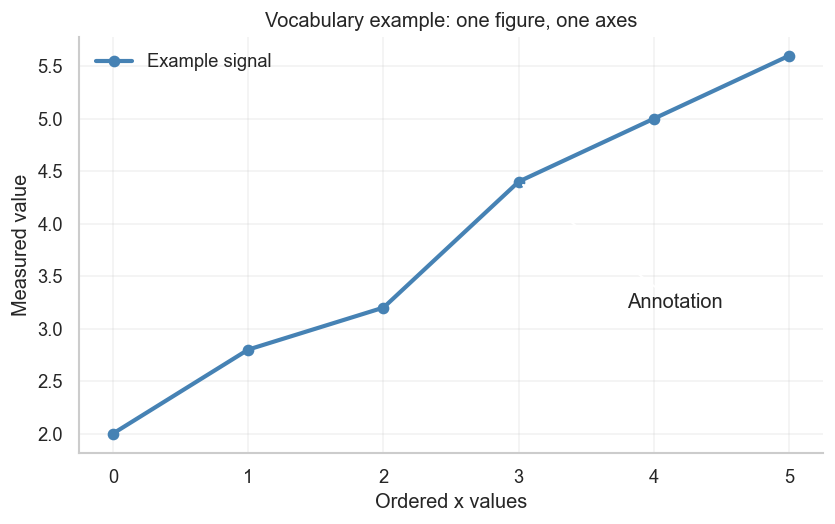

In [4]:
x = np.arange(0, 6)
y = np.array([2.0, 2.8, 3.2, 4.4, 5.0, 5.6])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, marker="o", linewidth=2.5, color="steelblue", label="Example signal")
ax.set_title("Vocabulary example: one figure, one axes")
ax.set_xlabel("Ordered x values")
ax.set_ylabel("Measured value")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="upper left")
ax.annotate("Annotation", xy=(3, 4.4), xytext=(3.8, 3.2), arrowprops={"arrowstyle": "->", "lw": 1.2})

save_matplotlib(fig, "03_plotting_vocabulary")
plt.show()

## 4. Basic Matplotlib Figure and Axes Workflow

Matplotlib is easiest to understand when you think in objects:

- `fig` is the whole page.
- `ax` is one plotting area on that page.
- Methods like `ax.plot(...)` or `ax.set_title(...)` change only that axes.

<class 'matplotlib.figure.Figure'> <class 'matplotlib.axes._axes.Axes'>


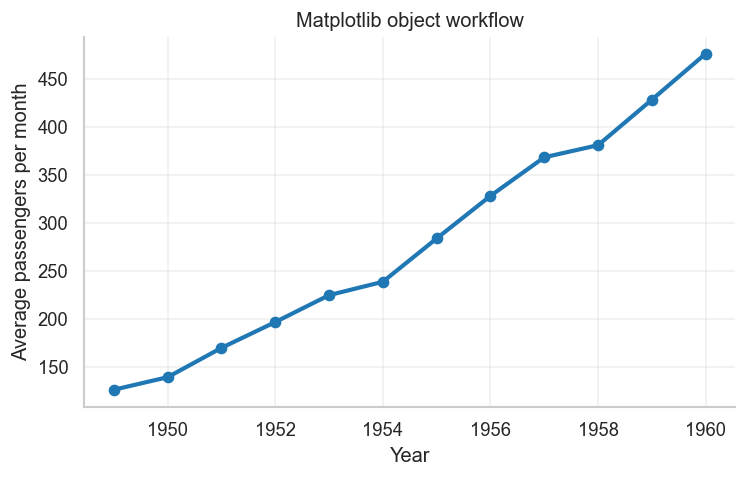

In [5]:
flights_by_year = flights.groupby("year", observed=False)["passengers"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    flights_by_year["year"],
    flights_by_year["passengers"],
    color="#1f77b4",
    marker="o",
    linewidth=2.5,
)
ax.set(
    title="Matplotlib object workflow",
    xlabel="Year",
    ylabel="Average passengers per month",
)
ax.grid(alpha=0.3)

print(type(fig), type(ax))
save_matplotlib(fig, "04_matplotlib_axes_workflow")
plt.show()

## 5. Line Plot

            **What question does this plot answer?**
            A line plot answers: how does a value change across an ordered variable such as time, distance, or dose?

            **What data does it need?**
            It needs one ordered x variable and one numeric y variable. Grouping is optional.

            **Key parameters to notice**
            - ``linewidth``
- ``marker``
- ``hue` or `color``
- ``template``
- ``legend``

            **Common mistakes**
            - Using a line plot for unordered categories.
- Connecting points across missing or unsorted x-values.
- Using too many lines in one panel.

            **What the code below does**
            - `line_data` keeps only three months so the comparison stays readable.
- The Matplotlib loop shows the most explicit way to draw one line per group.
- The Seaborn and Plotly calls use the dataframe directly and map `month` to color.
- The saved file is a polished Matplotlib version in `outputs/figures/05_line_plot.png`.

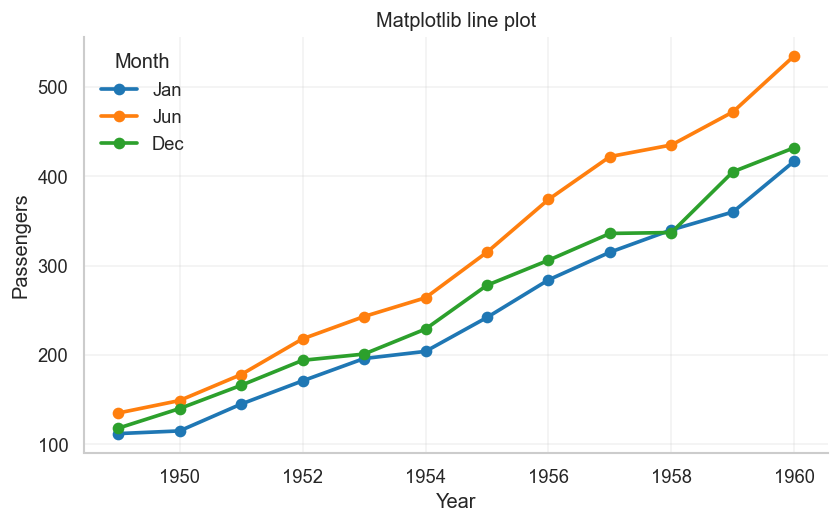

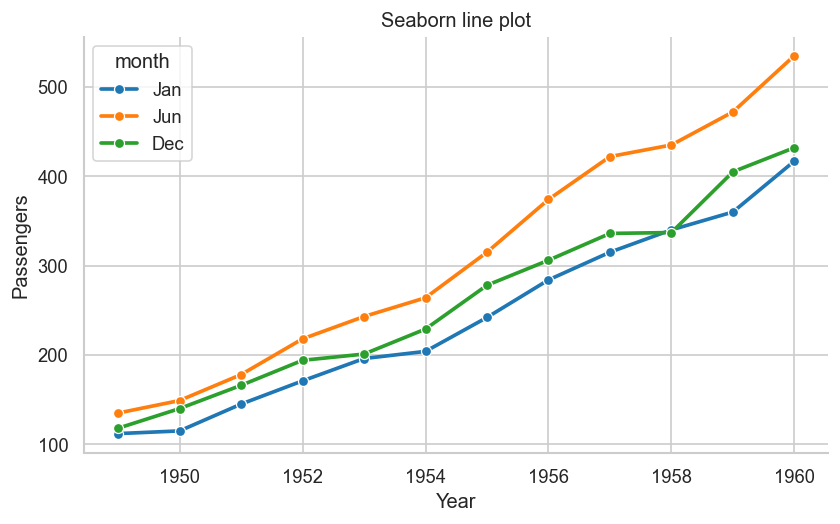

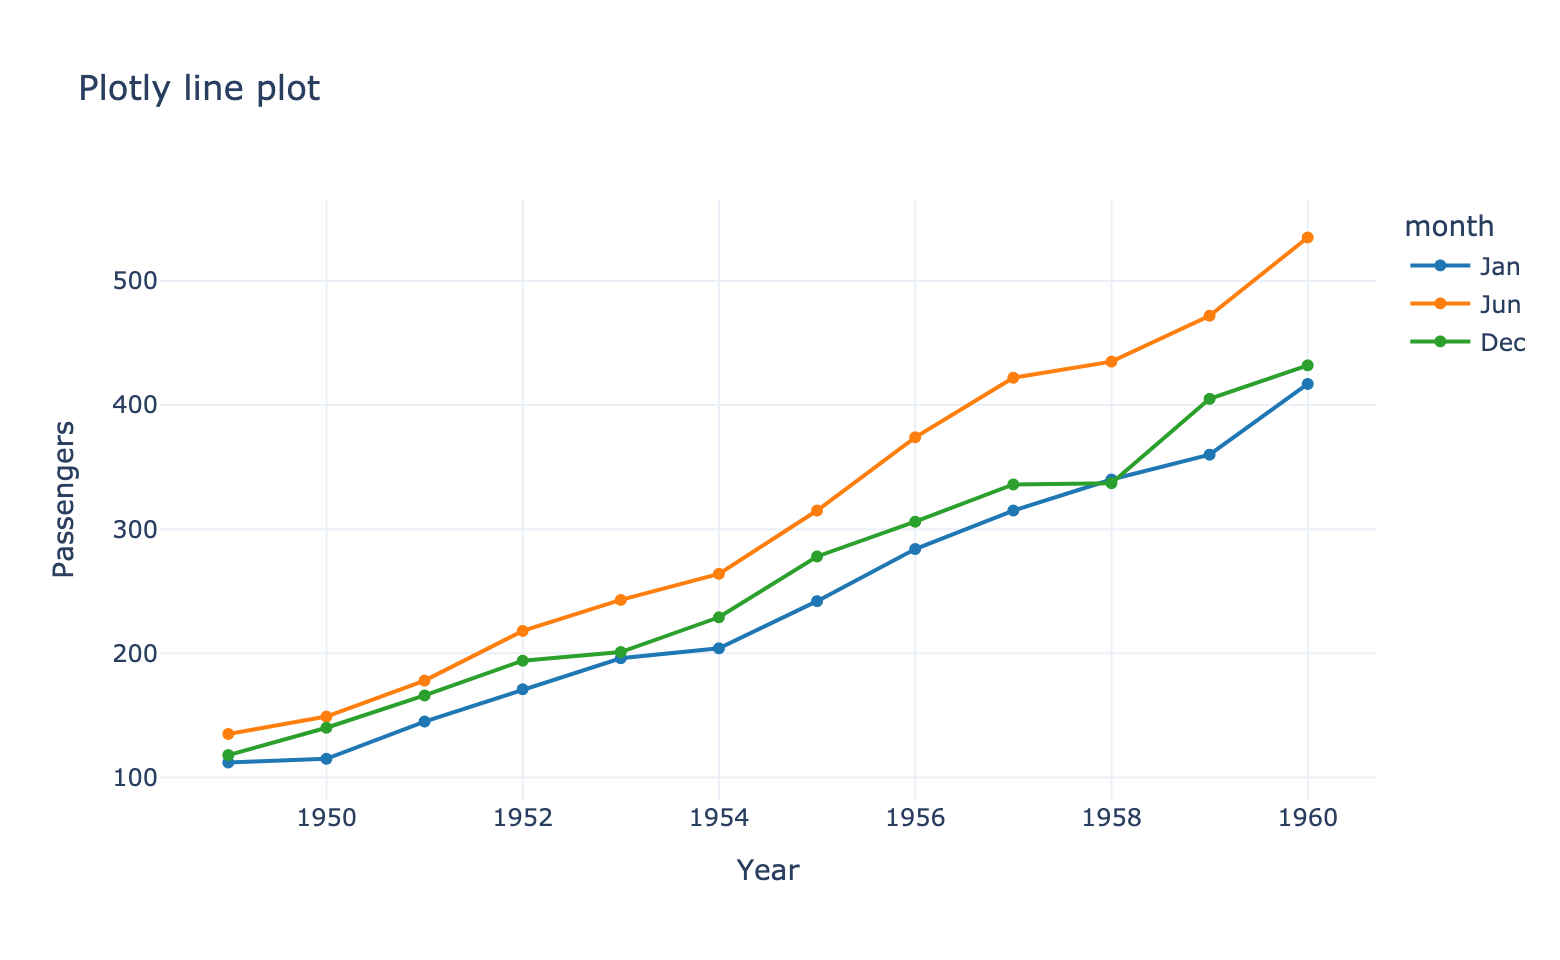

In [6]:
line_data = flights[flights["month"].isin(["Jan", "Jun", "Dec"])].copy()
line_data["month"] = line_data["month"].cat.remove_unused_categories()
palette = {"Jan": "#1f77b4", "Jun": "#ff7f0e", "Dec": "#2ca02c"}

fig, ax = plt.subplots(figsize=(8, 4.5))
for month, group in line_data.groupby("month", observed=True):
    ax.plot(group["year"], group["passengers"], marker="o", linewidth=2.2, label=month, color=palette[month])
ax.set(title="Matplotlib line plot", xlabel="Year", ylabel="Passengers")
ax.legend(frameon=False, title="Month")
ax.grid(alpha=0.25)
save_matplotlib(fig, "05_line_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=line_data, x="year", y="passengers", hue="month", marker="o", linewidth=2.2, palette=palette, ax=ax)
ax.set(title="Seaborn line plot", xlabel="Year", ylabel="Passengers")
plt.show()

fig_plotly = px.line(
    line_data,
    x="year",
    y="passengers",
    color="month",
    markers=True,
    color_discrete_map=palette,
    template="plotly_white",
    title="Plotly line plot",
)
fig_plotly.update_layout(xaxis_title="Year", yaxis_title="Passengers")
show_plotly(fig_plotly)

## 6. Scatter Plot

            **What question does this plot answer?**
            A scatter plot answers: do two numeric variables move together, and are there group differences or outliers?

            **What data does it need?**
            It needs two numeric columns. A grouping column is optional for color or shape.

            **Key parameters to notice**
            - ``s` or `size``
- ``alpha``
- ``hue` or `color``
- ``symbol``
- ``hover_data``

            **Common mistakes**
            - Using markers that are too large and hide overlap.
- Forgetting transparency when many points overlap.
- Using too many categories at once.

            **What the code below does**
            - The x-axis uses sepal length and the y-axis uses petal length from `iris`.
- Color is mapped to species so the group structure is easy to see.
- Plotly adds hover labels automatically, which is useful for exploration.
- The exported figure is a polished Matplotlib scatter plot.

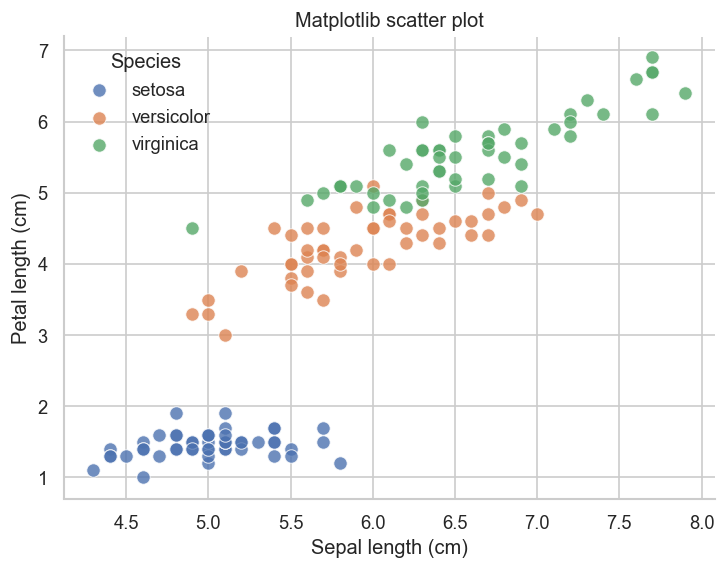

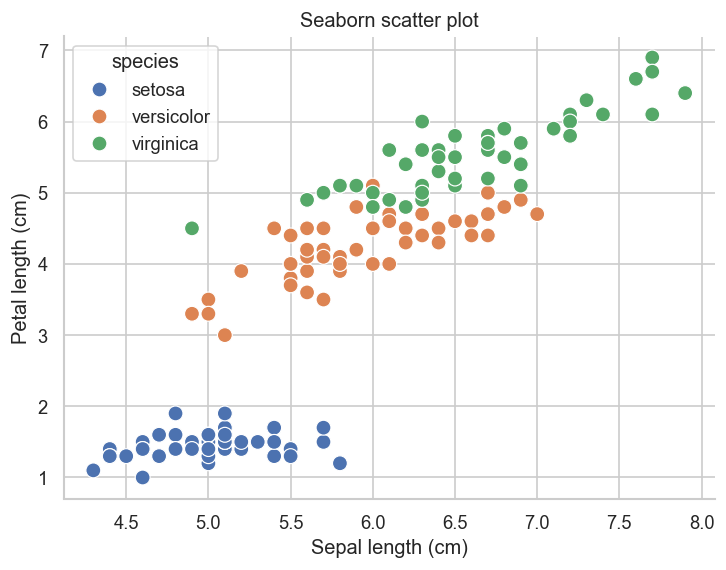

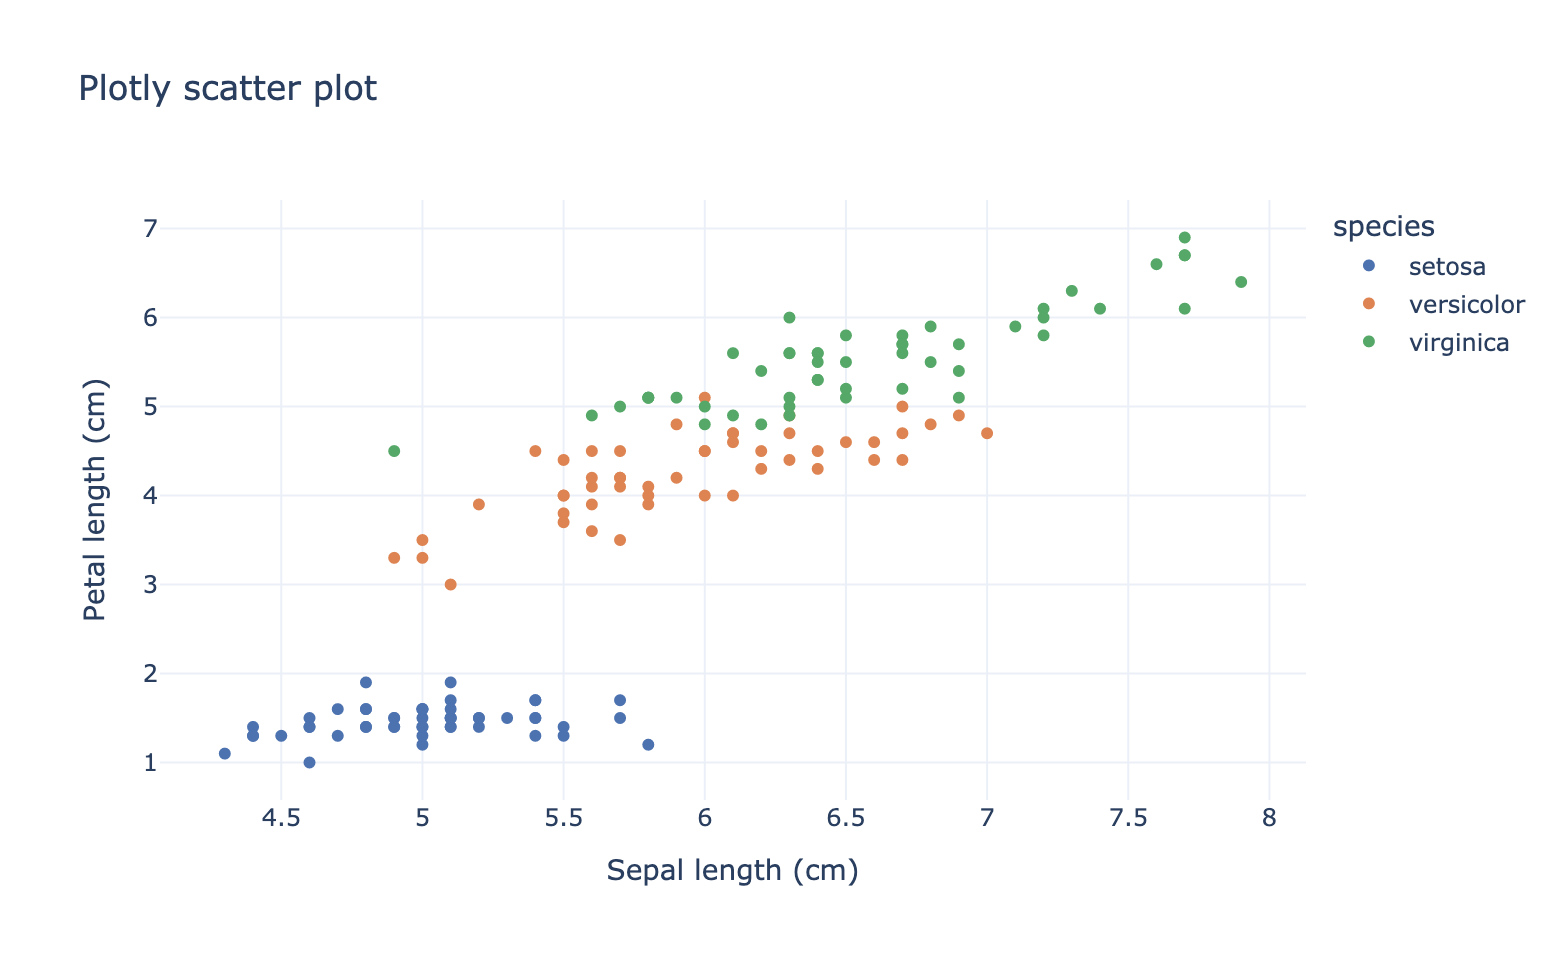

In [7]:
iris_palette = {"setosa": "#4c72b0", "versicolor": "#dd8452", "virginica": "#55a868"}

fig, ax = plt.subplots(figsize=(7, 5))
for species, group in iris.groupby("species"):
    ax.scatter(
        group["sepal_length"],
        group["petal_length"],
        s=65,
        alpha=0.8,
        label=species,
        color=iris_palette[species],
        edgecolor="white",
        linewidth=0.6,
    )
ax.set(title="Matplotlib scatter plot", xlabel="Sepal length (cm)", ylabel="Petal length (cm)")
ax.legend(frameon=False, title="Species")
save_matplotlib(fig, "06_scatter_plot")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="petal_length",
    hue="species",
    s=80,
    palette=iris_palette,
    ax=ax,
)
ax.set(title="Seaborn scatter plot", xlabel="Sepal length (cm)", ylabel="Petal length (cm)")
plt.show()

fig_plotly = px.scatter(
    iris,
    x="sepal_length",
    y="petal_length",
    color="species",
    hover_data=["sepal_width", "petal_width"],
    color_discrete_map=iris_palette,
    template="plotly_white",
    title="Plotly scatter plot",
)
fig_plotly.update_layout(xaxis_title="Sepal length (cm)", yaxis_title="Petal length (cm)")
show_plotly(fig_plotly)

## 7. Bar Plot

            **What question does this plot answer?**
            A bar plot answers: how large is a summary value for each category?

            **What data does it need?**
            It needs one categorical column and one numeric summary, or raw data plus a summary rule.

            **Key parameters to notice**
            - ``width``
- ``color``
- ``errorbar``
- ``estimator``
- ``text_auto``

            **Common mistakes**
            - Using bars to hide raw spread when the distribution matters.
- Starting the y-axis far above zero for plain bars.
- Showing too many categories at once.

            **What the code below does**
            - The data is summarized to the mean tip per day before the Matplotlib and Plotly bars.
- Seaborn can summarize raw data directly, which is convenient but important to notice.
- This section saves one clear bar chart to the figures folder.

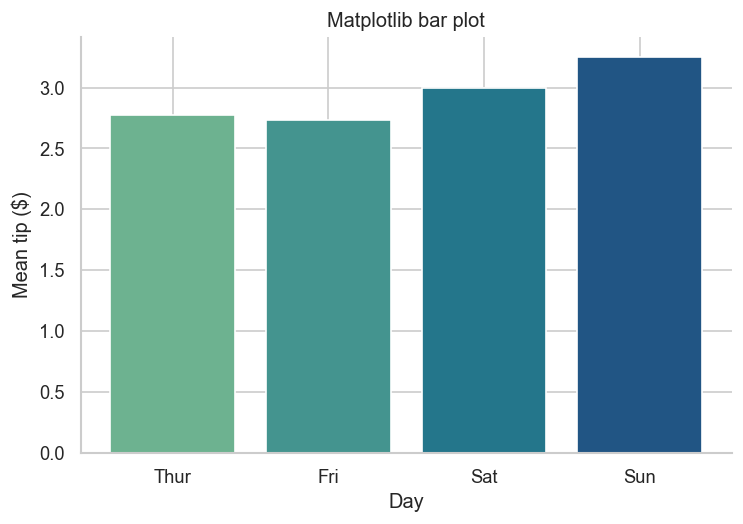

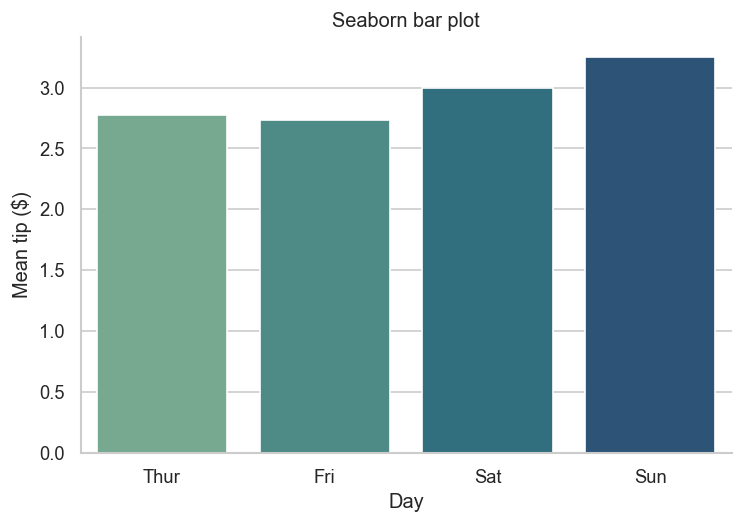

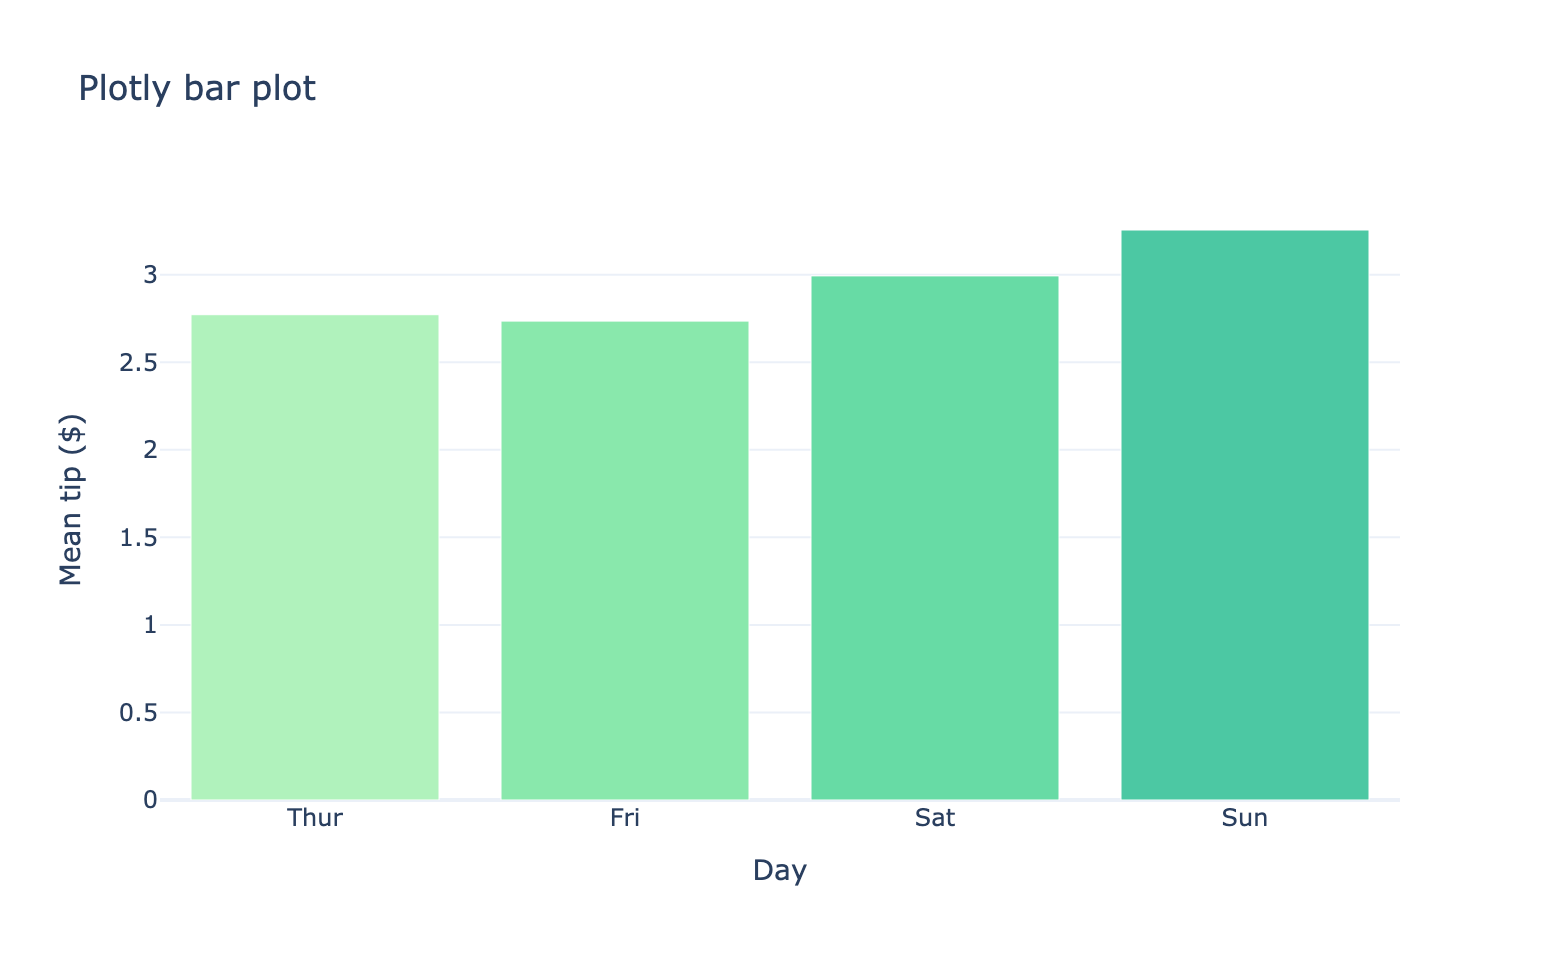

In [8]:
bar_data = (
    tips.groupby("day", observed=False)["tip"]
    .mean()
    .reindex(DAY_ORDER)
    .dropna()
    .reset_index(name="mean_tip")
)
bar_palette = sns.color_palette("crest", n_colors=len(bar_data))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(bar_data["day"], bar_data["mean_tip"], color=bar_palette, edgecolor="white")
ax.set(title="Matplotlib bar plot", xlabel="Day", ylabel="Mean tip ($)")
save_matplotlib(fig, "07_bar_plot")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=tips, x="day", y="tip", order=DAY_ORDER, palette="crest", errorbar=None, ax=ax)
ax.set(title="Seaborn bar plot", xlabel="Day", ylabel="Mean tip ($)")
plt.show()

fig_plotly = px.bar(
    bar_data,
    x="day",
    y="mean_tip",
    color="day",
    color_discrete_sequence=px.colors.sequential.Tealgrn,
    template="plotly_white",
    title="Plotly bar plot",
)
fig_plotly.update_layout(showlegend=False, xaxis_title="Day", yaxis_title="Mean tip ($)")
show_plotly(fig_plotly)

## 8. Grouped Bar Plot

            **What question does this plot answer?**
            A grouped bar plot answers: how do subgroup summaries compare inside each category?

            **What data does it need?**
            It needs at least one category, one subgroup, and one numeric summary.

            **Key parameters to notice**
            - ``barmode='group'``
- ``hue``
- ``width``
- ``legend``
- ``capsize``

            **Common mistakes**
            - Using too many subgroup levels.
- Not keeping the same order across groups.
- Forgetting that bar height is still only a summary.

            **What the code below does**
            - The summary is mean penguin body mass for each species and sex.
- Matplotlib builds grouped positions manually so you can see the underlying geometry.
- Seaborn and Plotly use the dataframe directly and map sex to grouped colors.

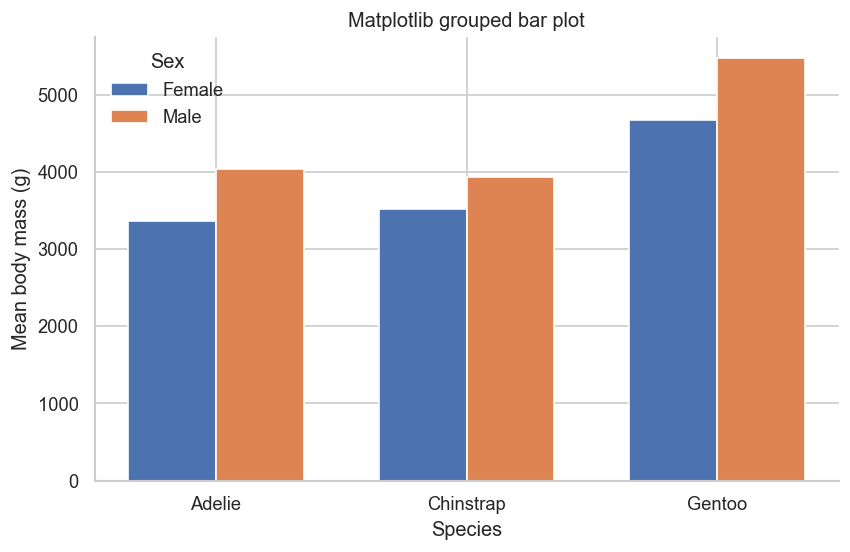

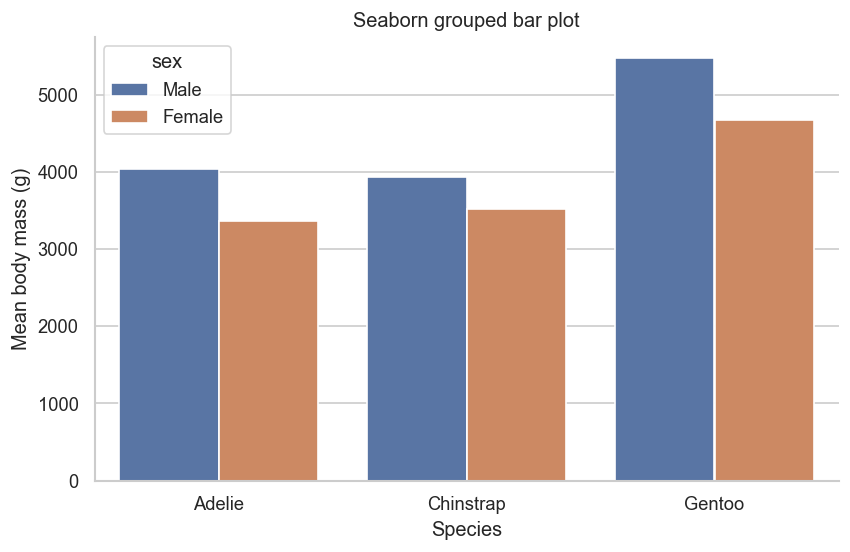

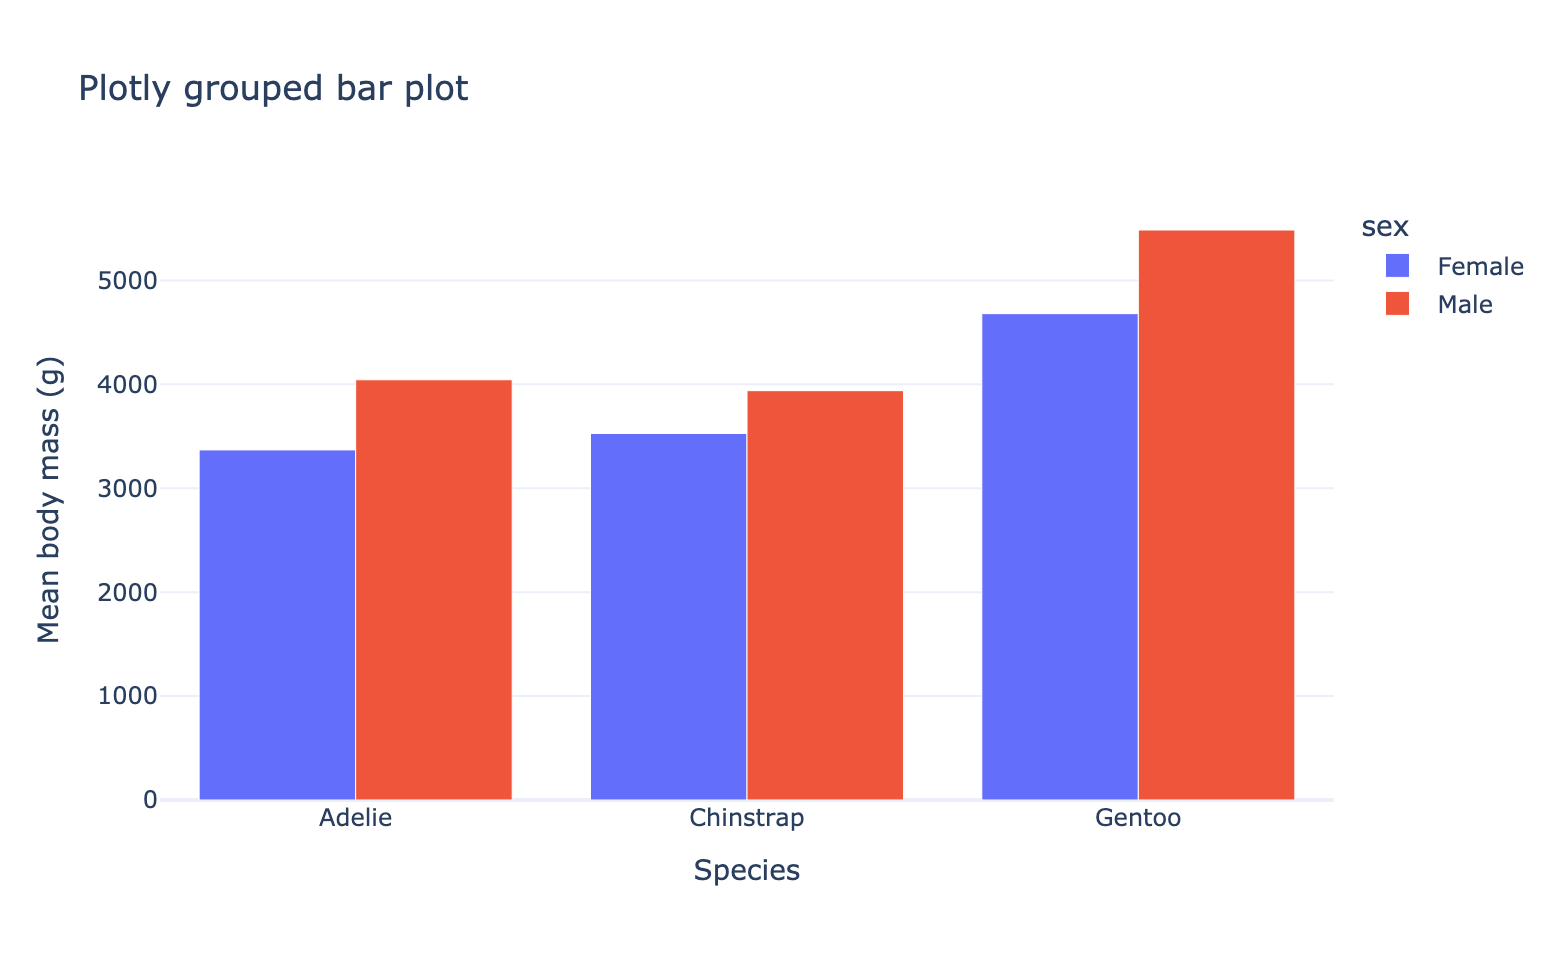

In [9]:
grouped = (
    penguins.dropna(subset=["species", "sex", "body_mass_g"])
    .groupby(["species", "sex"], observed=False)["body_mass_g"]
    .mean()
    .reset_index()
)
grouped["species"] = pd.Categorical(grouped["species"], categories=["Adelie", "Chinstrap", "Gentoo"], ordered=True)
grouped = grouped.sort_values(["species", "sex"])
sex_order = ["Female", "Male"]
x_positions = np.arange(grouped["species"].nunique())
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.8))
for idx, sex in enumerate(sex_order):
    subset = grouped[grouped["sex"] == sex]
    ax.bar(x_positions + (idx - 0.5) * width, subset["body_mass_g"], width=width, label=sex)
ax.set_xticks(x_positions, grouped["species"].cat.categories)
ax.set(title="Matplotlib grouped bar plot", xlabel="Species", ylabel="Mean body mass (g)")
ax.legend(frameon=False, title="Sex")
save_matplotlib(fig, "08_grouped_bar_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(
    data=penguins.dropna(subset=["species", "sex", "body_mass_g"]),
    x="species",
    y="body_mass_g",
    hue="sex",
    estimator="mean",
    errorbar=None,
    ax=ax,
)
ax.set(title="Seaborn grouped bar plot", xlabel="Species", ylabel="Mean body mass (g)")
plt.show()

fig_plotly = px.bar(
    grouped,
    x="species",
    y="body_mass_g",
    color="sex",
    barmode="group",
    template="plotly_white",
    title="Plotly grouped bar plot",
)
fig_plotly.update_layout(xaxis_title="Species", yaxis_title="Mean body mass (g)")
show_plotly(fig_plotly)

## 9. Histogram

            **What question does this plot answer?**
            A histogram answers: how are values distributed across bins?

            **What data does it need?**
            It needs one numeric column. Group overlays are optional.

            **Key parameters to notice**
            - ``bins``
- ``alpha``
- ``stat``
- ``element``
- ``nbins``

            **Common mistakes**
            - Using too few or too many bins.
- Reading bin counts as exact values instead of approximate ranges.
- Overlaying too many groups without transparency.

            **What the code below does**
            - This example compares the `mean radius` feature in the breast cancer dataset.
- Matplotlib and Plotly use explicit bin counts. Seaborn makes grouped overlays easy.
- The saved figure is the Matplotlib version with a clean axis label and legend.

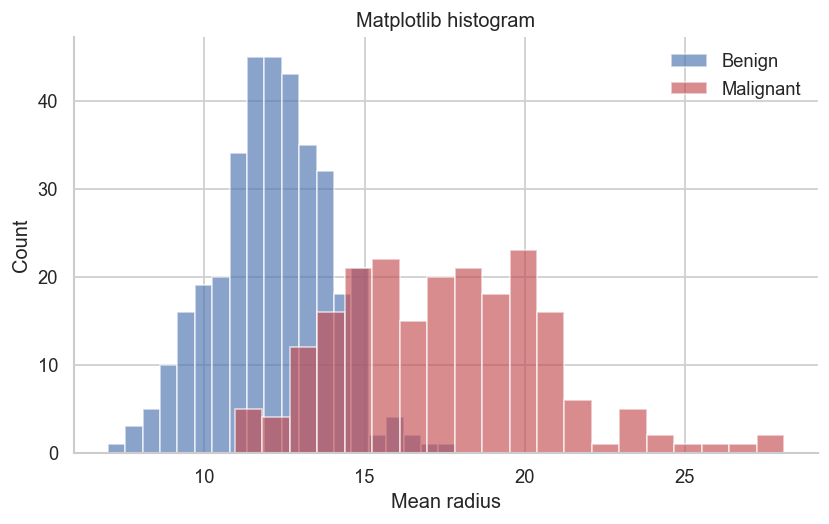

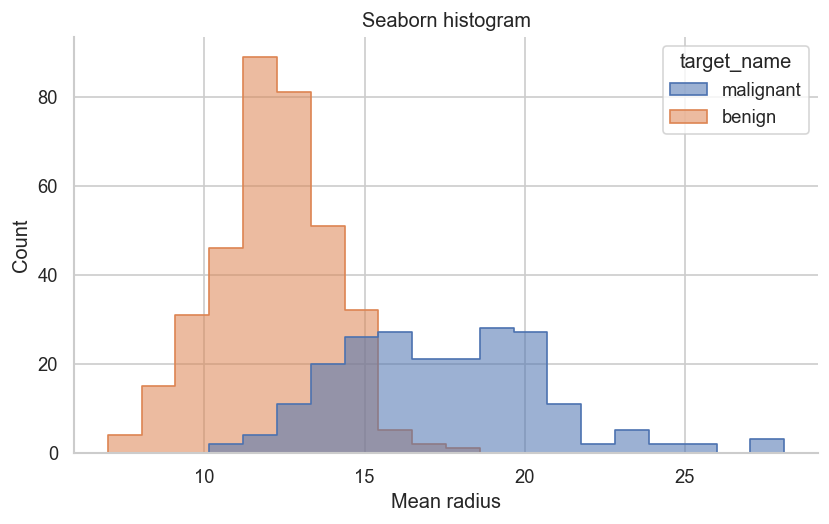

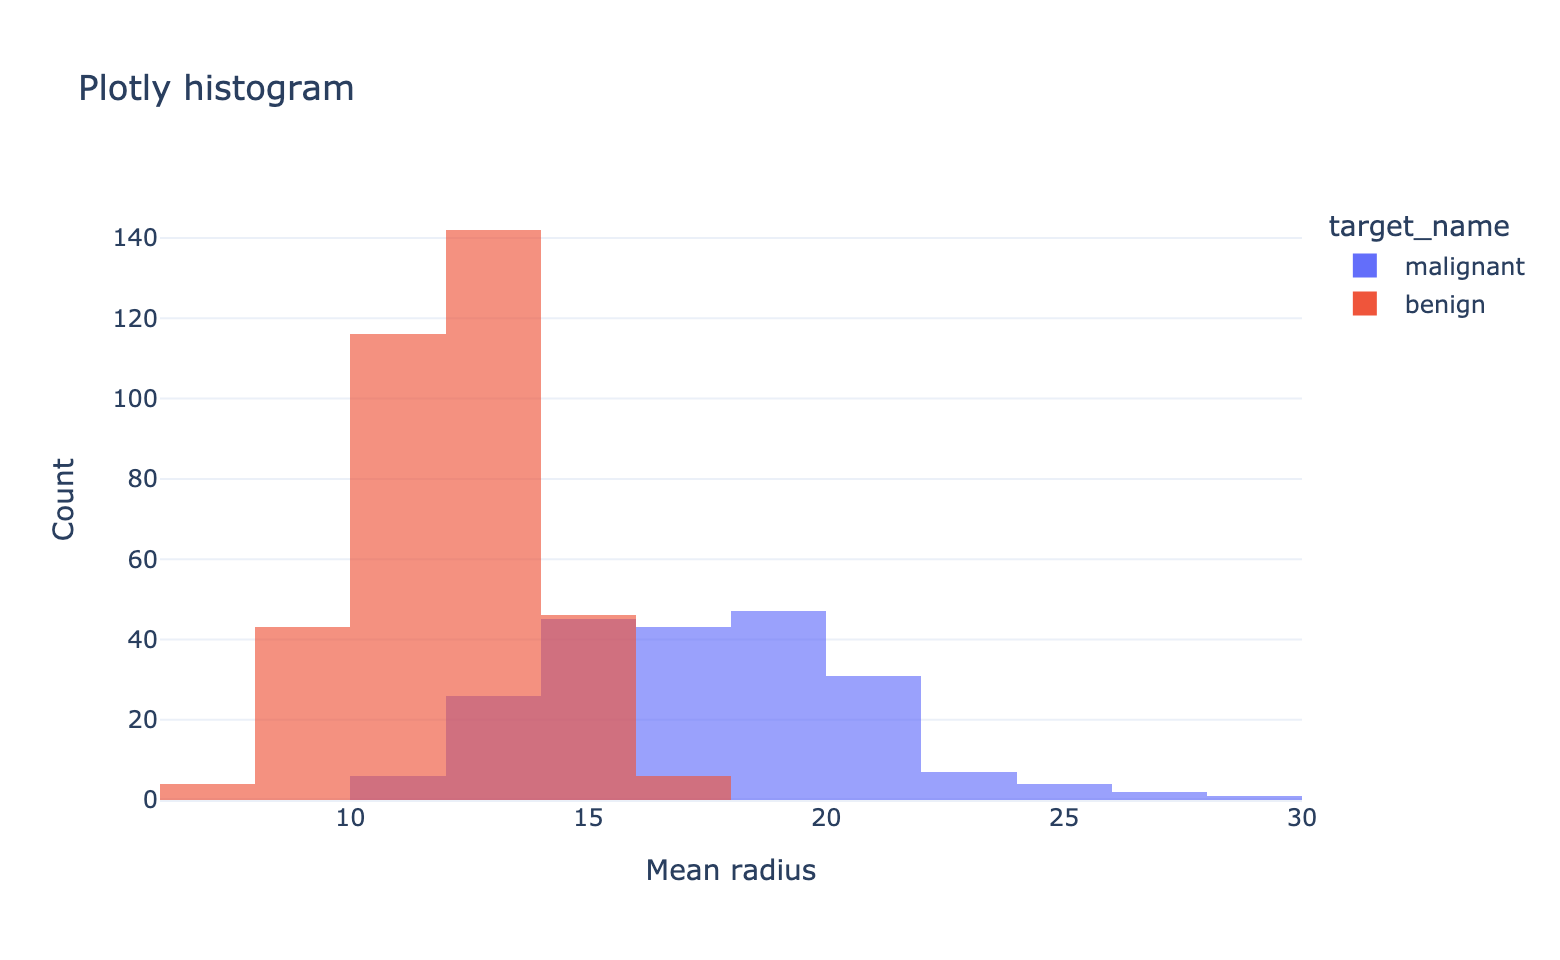

In [10]:
malignant_mask = breast_cancer["target_name"] == "malignant"

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(breast_cancer.loc[~malignant_mask, "mean radius"], bins=20, alpha=0.65, label="Benign", color="#4c72b0")
ax.hist(breast_cancer.loc[malignant_mask, "mean radius"], bins=20, alpha=0.65, label="Malignant", color="#c44e52")
ax.set(title="Matplotlib histogram", xlabel="Mean radius", ylabel="Count")
ax.legend(frameon=False)
save_matplotlib(fig, "09_histogram")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=breast_cancer,
    x="mean radius",
    hue="target_name",
    bins=20,
    alpha=0.55,
    element="step",
    ax=ax,
)
ax.set(title="Seaborn histogram", xlabel="Mean radius", ylabel="Count")
plt.show()

fig_plotly = px.histogram(
    breast_cancer,
    x="mean radius",
    color="target_name",
    nbins=20,
    barmode="overlay",
    opacity=0.65,
    template="plotly_white",
    title="Plotly histogram",
)
fig_plotly.update_layout(xaxis_title="Mean radius", yaxis_title="Count")
show_plotly(fig_plotly)

## 10. KDE Plot

            **What question does this plot answer?**
            A KDE plot answers: what smooth shape does the distribution suggest?

            **What data does it need?**
            It needs one numeric column and enough observations for a stable smooth curve.

            **Key parameters to notice**
            - ``bw_method``
- ``fill``
- ``common_norm``
- ``linewidth``
- ``palette``

            **Common mistakes**
            - Using KDE on tiny datasets.
- Treating the smoothed curve like exact truth.
- Forgetting that bandwidth choice changes the shape.

            **What the code below does**
            - Matplotlib uses `scipy.stats.gaussian_kde` to show the underlying density calculation.
- Seaborn wraps KDE in a simpler API for grouped data.
- Plotly reuses the computed density table so all three libraries show the same idea.

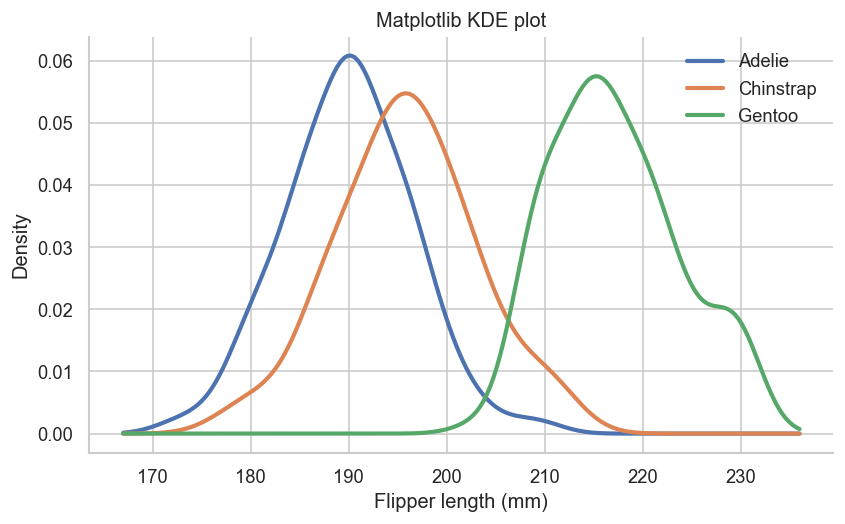

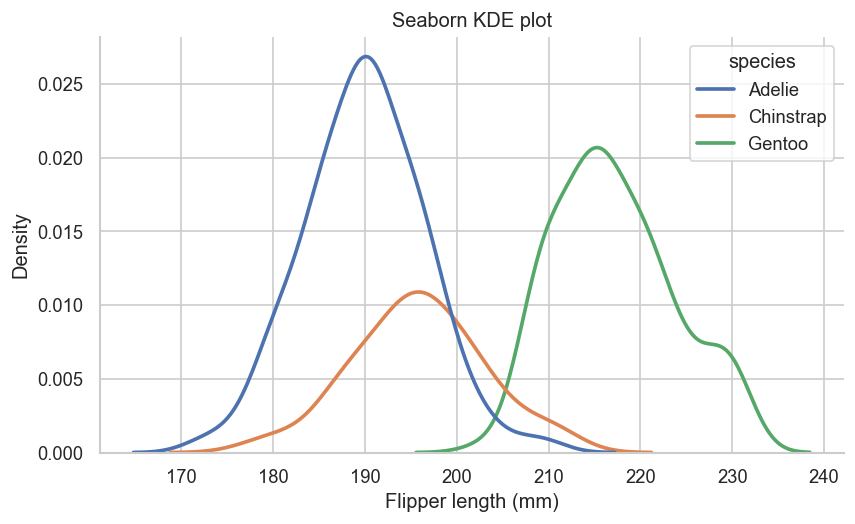

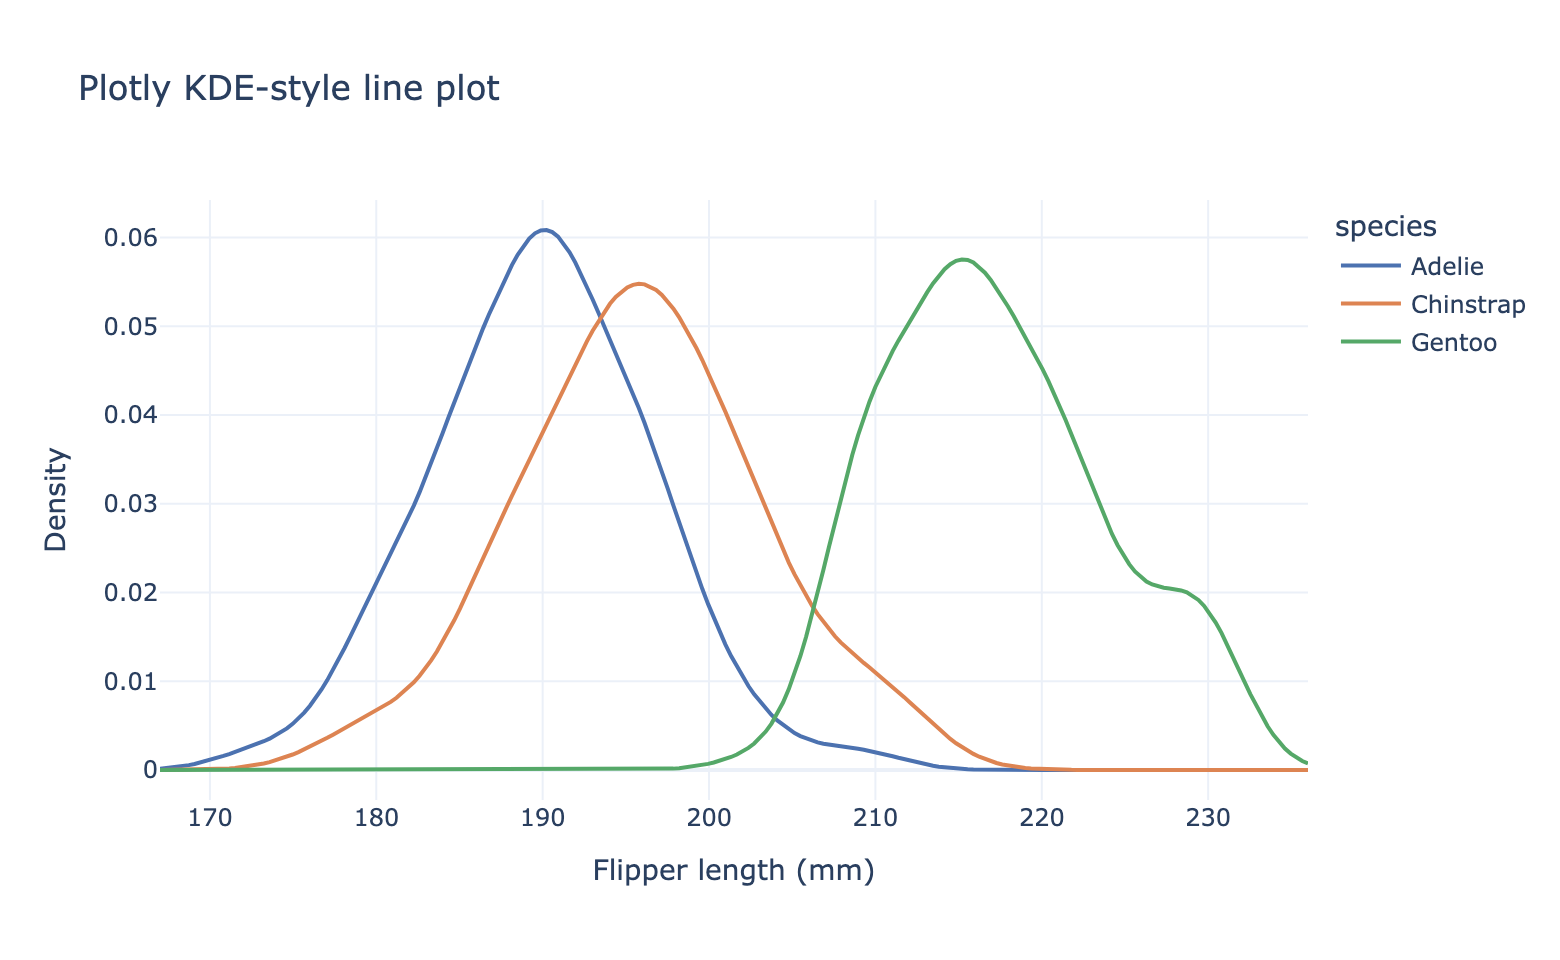

In [11]:
kde_source = penguins.dropna(subset=["species", "flipper_length_mm"]).copy()
grid = np.linspace(kde_source["flipper_length_mm"].min() - 5, kde_source["flipper_length_mm"].max() + 5, 200)
kde_rows = []
penguin_palette = {"Adelie": "#4c72b0", "Chinstrap": "#dd8452", "Gentoo": "#55a868"}

fig, ax = plt.subplots(figsize=(8, 4.5))
for species, group in kde_source.groupby("species", observed=False):
    density = stats.gaussian_kde(group["flipper_length_mm"])
    y = density(grid)
    kde_rows.extend({"species": species, "flipper_length_mm": x_value, "density": y_value} for x_value, y_value in zip(grid, y))
    ax.plot(grid, y, linewidth=2.5, label=species, color=penguin_palette[species])
ax.set(title="Matplotlib KDE plot", xlabel="Flipper length (mm)", ylabel="Density")
ax.legend(frameon=False)
save_matplotlib(fig, "10_kde_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(
    data=kde_source,
    x="flipper_length_mm",
    hue="species",
    fill=False,
    linewidth=2.2,
    palette=penguin_palette,
    ax=ax,
)
ax.set(title="Seaborn KDE plot", xlabel="Flipper length (mm)", ylabel="Density")
plt.show()

kde_frame = pd.DataFrame(kde_rows)
fig_plotly = px.line(
    kde_frame,
    x="flipper_length_mm",
    y="density",
    color="species",
    color_discrete_map=penguin_palette,
    template="plotly_white",
    title="Plotly KDE-style line plot",
)
fig_plotly.update_layout(xaxis_title="Flipper length (mm)", yaxis_title="Density")
show_plotly(fig_plotly)

## 11. Box Plot

            **What question does this plot answer?**
            A box plot answers: what are the median, spread, and possible outliers in each group?

            **What data does it need?**
            It needs one category column and one numeric column.

            **Key parameters to notice**
            - ``showfliers``
- ``whis``
- ``palette``
- ``width``
- ``points``

            **Common mistakes**
            - Explaining a box plot without teaching the median and quartiles first.
- Reading every point beyond the whiskers as an error.
- Using it when the exact distribution shape matters more than the summary.

            **What the code below does**
            - Each library compares restaurant bills across days.
- Matplotlib requires explicit lists of values for each box.
- Seaborn and Plotly directly use the dataframe and category column.

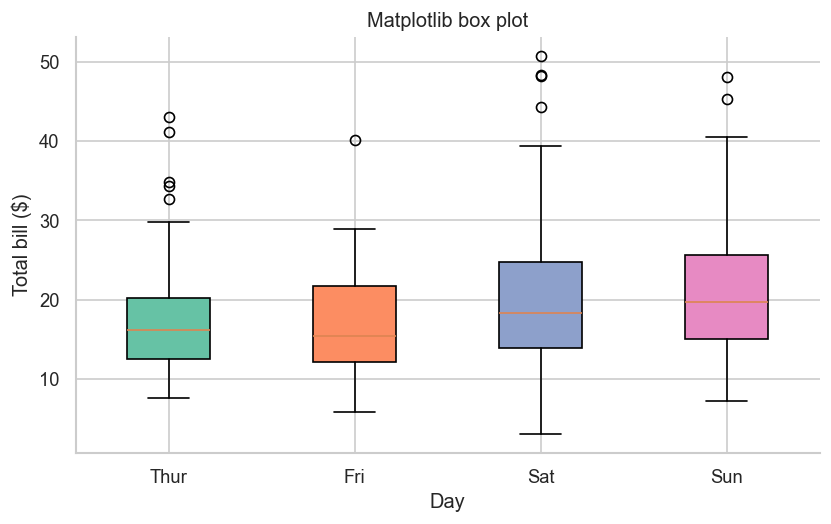

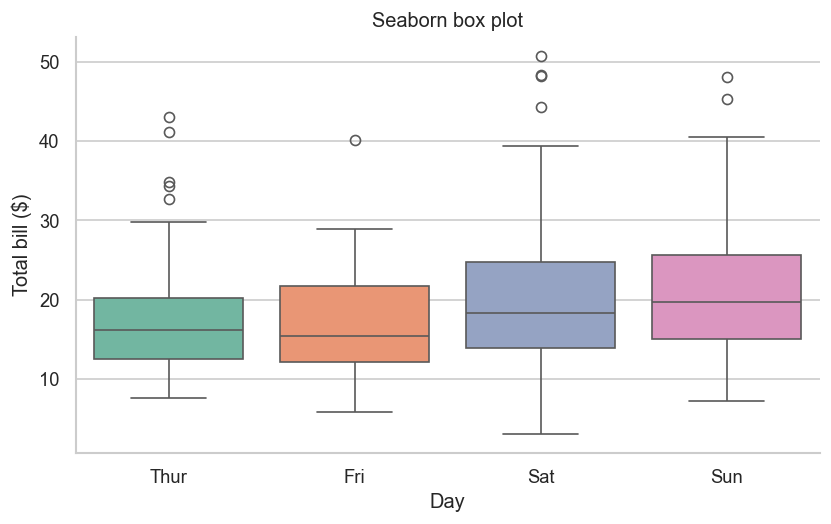

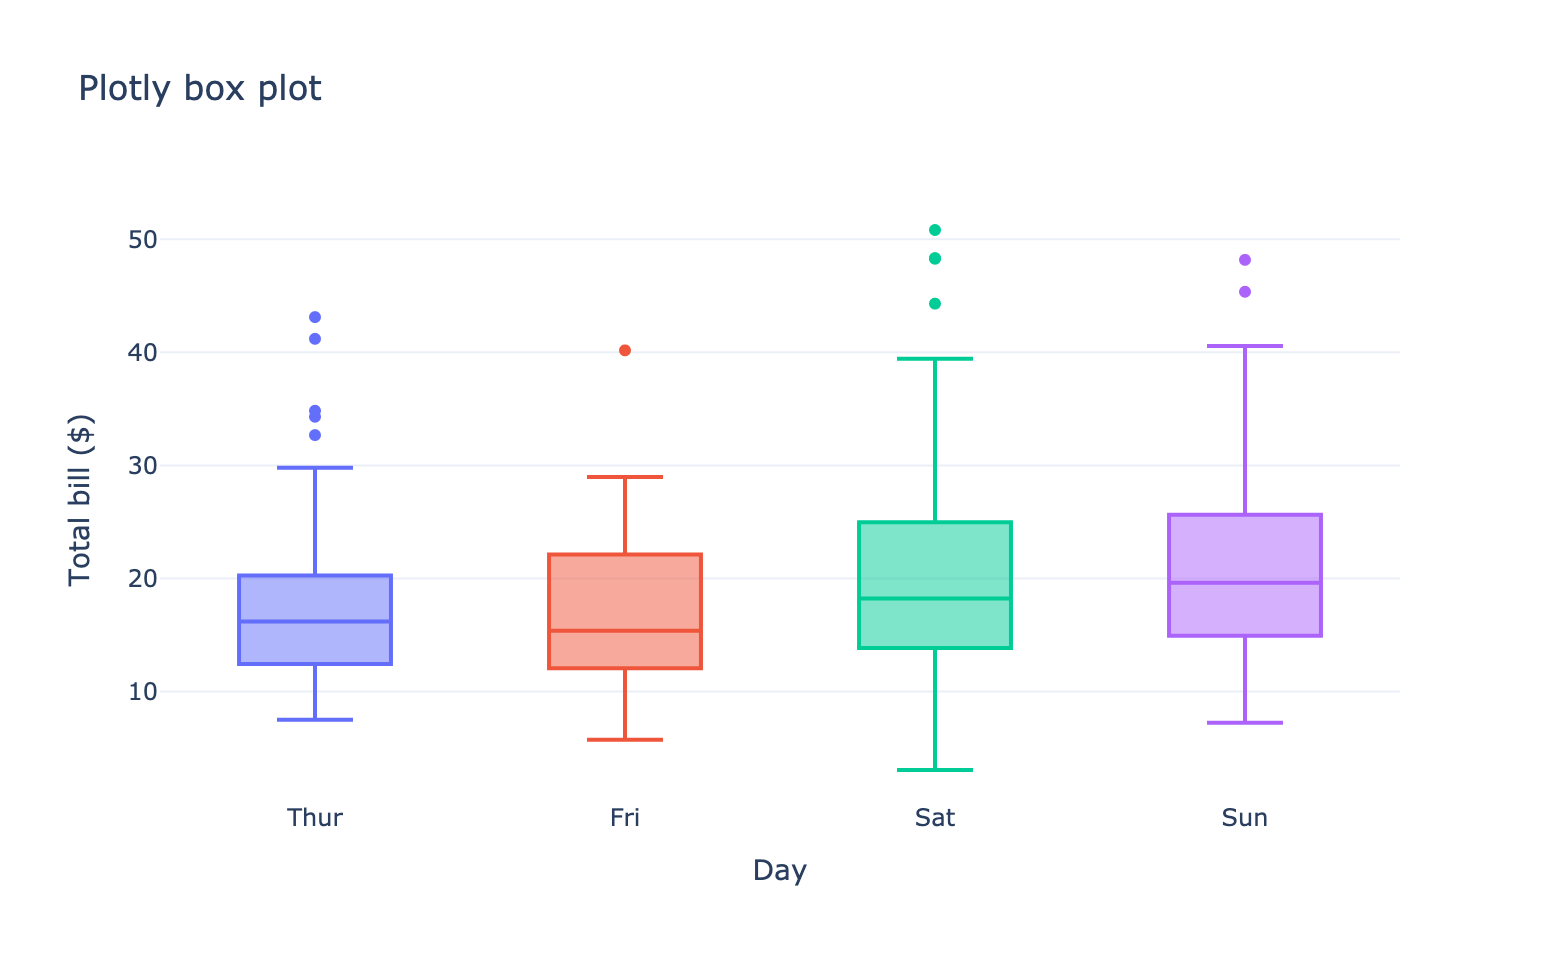

In [12]:
bill_groups = [tips.loc[tips["day"] == day, "total_bill"].dropna() for day in DAY_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
box = ax.boxplot(bill_groups, tick_labels=DAY_ORDER, patch_artist=True)
for patch, color in zip(box["boxes"], sns.color_palette("Set2", n_colors=len(DAY_ORDER))):
    patch.set_facecolor(color)
ax.set(title="Matplotlib box plot", xlabel="Day", ylabel="Total bill ($)")
save_matplotlib(fig, "11_box_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=tips, x="day", y="total_bill", order=DAY_ORDER, palette="Set2", ax=ax)
ax.set(title="Seaborn box plot", xlabel="Day", ylabel="Total bill ($)")
plt.show()

fig_plotly = px.box(
    tips,
    x="day",
    y="total_bill",
    color="day",
    category_orders={"day": DAY_ORDER},
    template="plotly_white",
    title="Plotly box plot",
)
fig_plotly.update_layout(showlegend=False, xaxis_title="Day", yaxis_title="Total bill ($)")
show_plotly(fig_plotly)

## 12. Violin Plot

            **What question does this plot answer?**
            A violin plot answers: how does the full distribution shape differ between groups?

            **What data does it need?**
            It needs one category column and one numeric column.

            **Key parameters to notice**
            - ``inner``
- ``cut``
- ``scale``
- ``points``
- ``spanmode``

            **Common mistakes**
            - Reading the violin width as sample count unless the method explicitly encodes it.
- Using violins for very small groups.
- Skipping an explanation of what the shape means.

            **What the code below does**
            - This example uses penguin body mass by species.
- Matplotlib can make violins, but Seaborn is usually simpler for this plot type.
- Plotly's violin plot can also show internal points or boxes if needed.

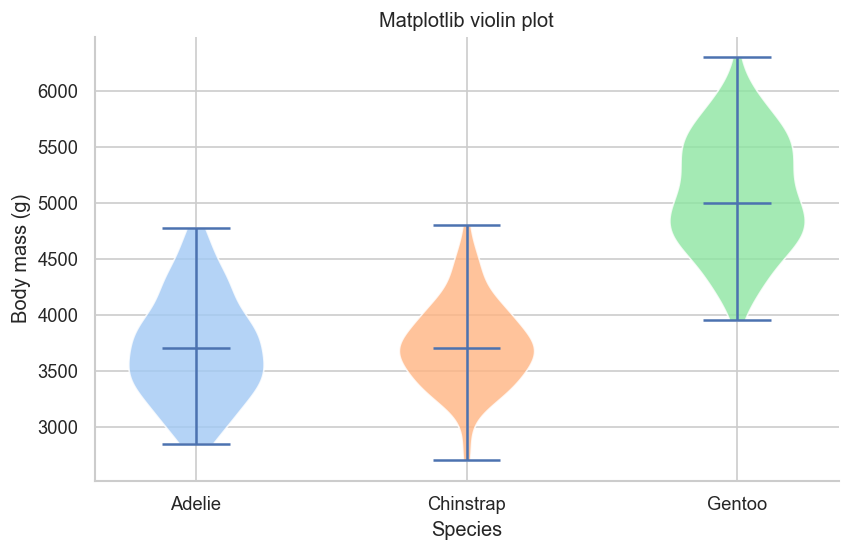

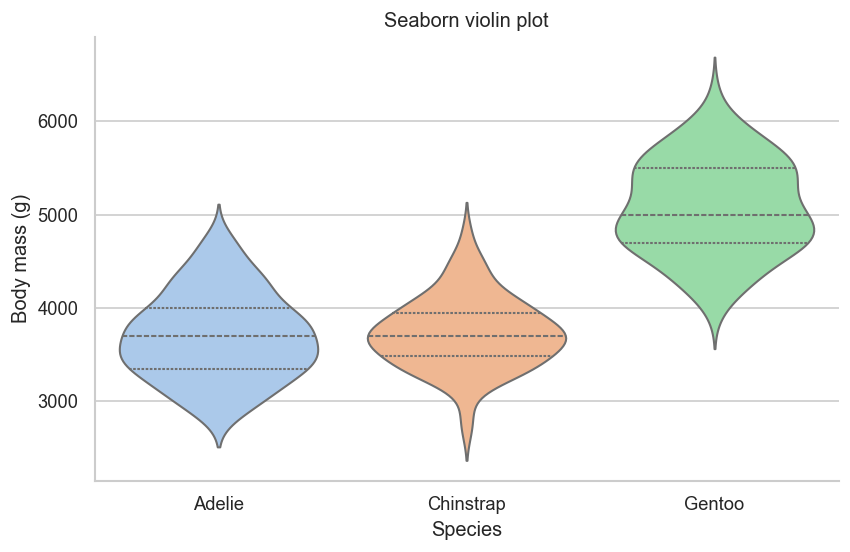

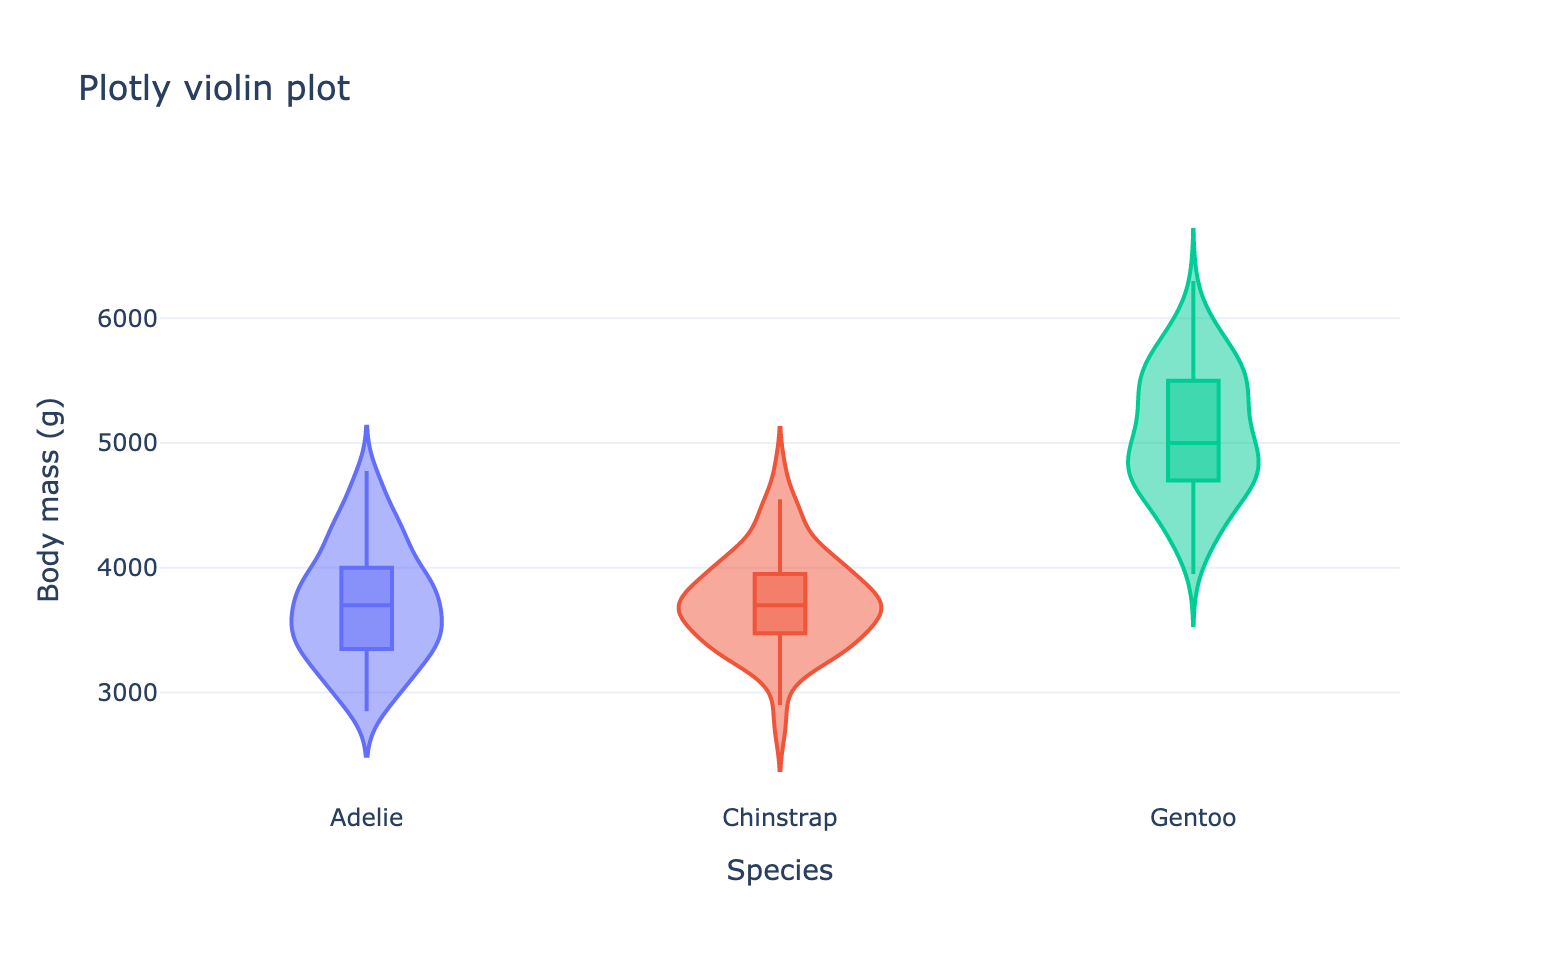

In [13]:
violin_source = penguins.dropna(subset=["species", "body_mass_g"]).copy()
species_order = ["Adelie", "Chinstrap", "Gentoo"]
violin_groups = [violin_source.loc[violin_source["species"] == species, "body_mass_g"] for species in species_order]

fig, ax = plt.subplots(figsize=(8, 4.8))
violin = ax.violinplot(violin_groups, showmeans=False, showmedians=True)
for body, color in zip(violin["bodies"], sns.color_palette("pastel", n_colors=len(species_order))):
    body.set_facecolor(color)
    body.set_alpha(0.8)
ax.set_xticks(range(1, len(species_order) + 1), species_order)
ax.set(title="Matplotlib violin plot", xlabel="Species", ylabel="Body mass (g)")
save_matplotlib(fig, "12_violin_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.violinplot(data=violin_source, x="species", y="body_mass_g", order=species_order, palette="pastel", inner="quartile", ax=ax)
ax.set(title="Seaborn violin plot", xlabel="Species", ylabel="Body mass (g)")
plt.show()

fig_plotly = px.violin(
    violin_source,
    x="species",
    y="body_mass_g",
    color="species",
    category_orders={"species": species_order},
    box=True,
    points=False,
    template="plotly_white",
    title="Plotly violin plot",
)
fig_plotly.update_layout(showlegend=False, xaxis_title="Species", yaxis_title="Body mass (g)")
show_plotly(fig_plotly)

## 13. Strip and Swarm Plot

            **What question does this plot answer?**
            These plots answer: where are the individual observations within each category?

            **What data does it need?**
            They need one category column and one numeric column.

            **Key parameters to notice**
            - ``jitter``
- ``size``
- ``alpha``
- ``dodge``
- ``hover_data``

            **Common mistakes**
            - Using them on very large datasets where overplotting becomes severe.
- Forgetting to jitter points in a plain strip plot.
- Using them without a clear category order.

            **What the code below does**
            - Matplotlib uses manual jitter so you can see what a strip plot really is.
- Seaborn uses a swarm plot, which tries to avoid overlap automatically.
- Plotly uses a strip plot and can show individual values on hover.

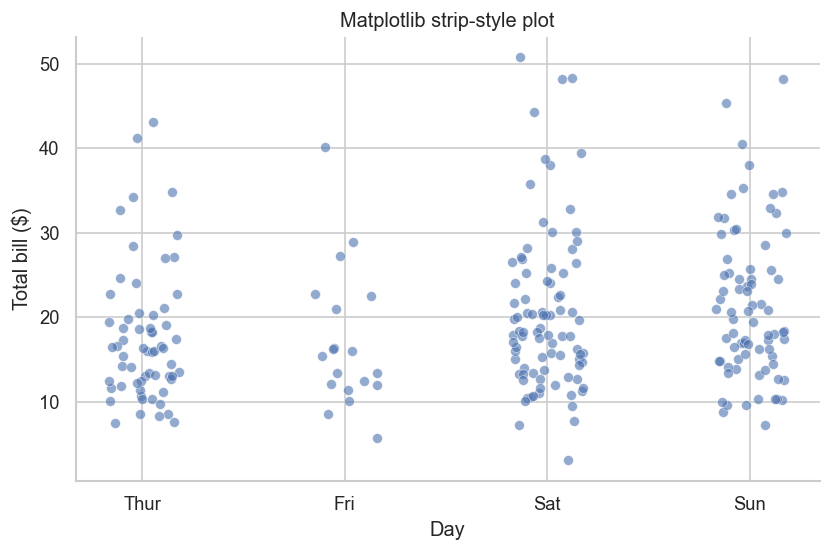

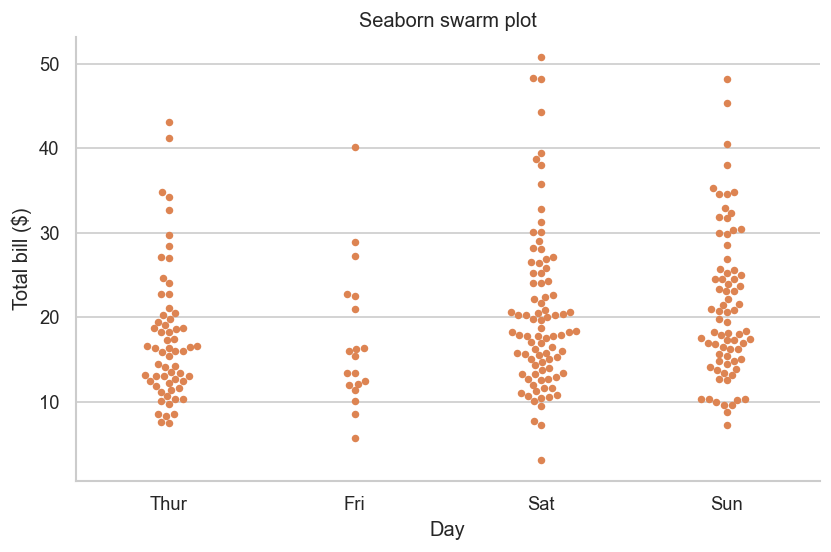

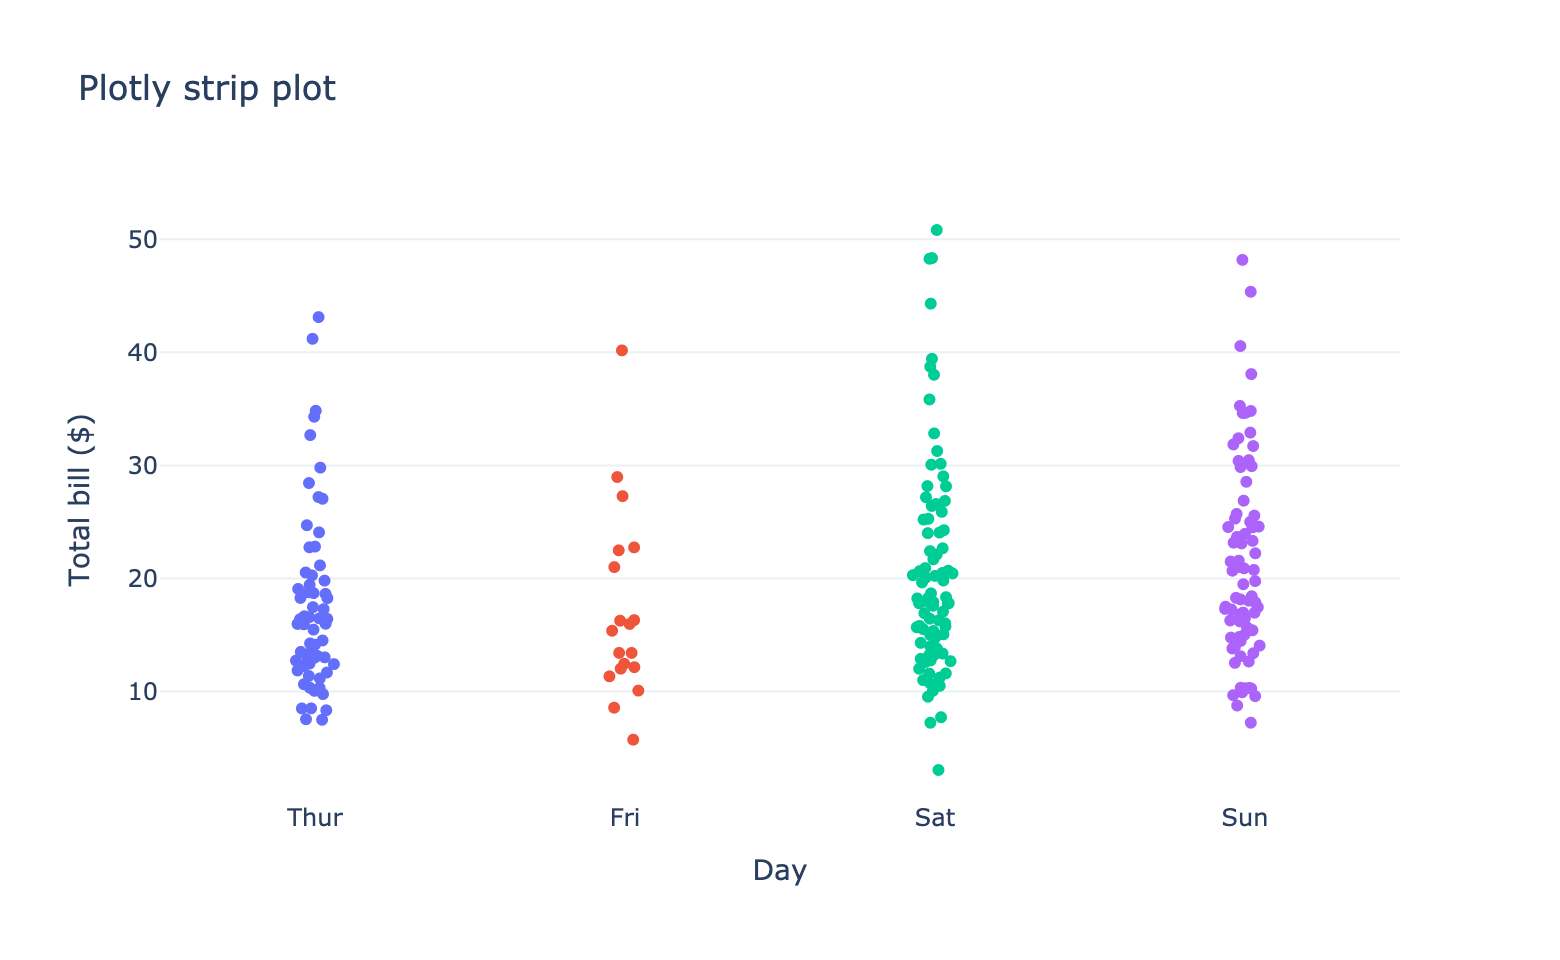

In [14]:
strip_source = tips.dropna(subset=["day", "total_bill"]).copy()
day_to_position = {day: idx for idx, day in enumerate(DAY_ORDER)}
x_positions = strip_source["day"].map(day_to_position).astype(float) + rng.uniform(-0.18, 0.18, len(strip_source))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(x_positions, strip_source["total_bill"], s=35, alpha=0.6, color="#4c72b0", edgecolor="white", linewidth=0.4)
ax.set_xticks(range(len(DAY_ORDER)), DAY_ORDER)
ax.set(title="Matplotlib strip-style plot", xlabel="Day", ylabel="Total bill ($)")
save_matplotlib(fig, "13_strip_swarm_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.swarmplot(data=strip_source, x="day", y="total_bill", order=DAY_ORDER, size=4.5, color="#dd8452", ax=ax)
ax.set(title="Seaborn swarm plot", xlabel="Day", ylabel="Total bill ($)")
plt.show()

fig_plotly = px.strip(
    strip_source,
    x="day",
    y="total_bill",
    category_orders={"day": DAY_ORDER},
    color="day",
    template="plotly_white",
    title="Plotly strip plot",
)
fig_plotly.update_layout(showlegend=False, xaxis_title="Day", yaxis_title="Total bill ($)")
show_plotly(fig_plotly)

## 14. Heatmap

            **What question does this plot answer?**
            A heatmap answers: how do values change across a row-by-column matrix?

            **What data does it need?**
            It needs a 2D table or a matrix of numeric values.

            **Key parameters to notice**
            - ``cmap``
- ``vmin` / `vmax``
- ``annot``
- ``aspect``
- ``colorbar``

            **Common mistakes**
            - Using a rainbow colormap with no meaning.
- Packing in too many rows or columns to read.
- Forgetting to label axes and color meaning.

            **What the code below does**
            - The `flights` dataset is pivoted so months become rows and years become columns.
- Matplotlib uses `imshow`, Seaborn uses `heatmap`, and Plotly uses `imshow`.
- The saved figure is a polished Matplotlib heatmap with a readable colorbar.

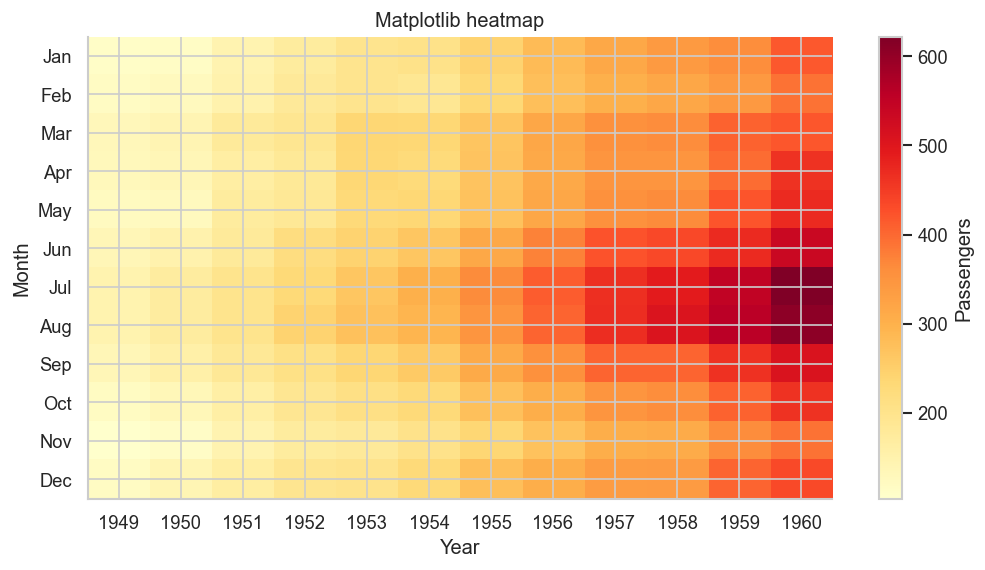

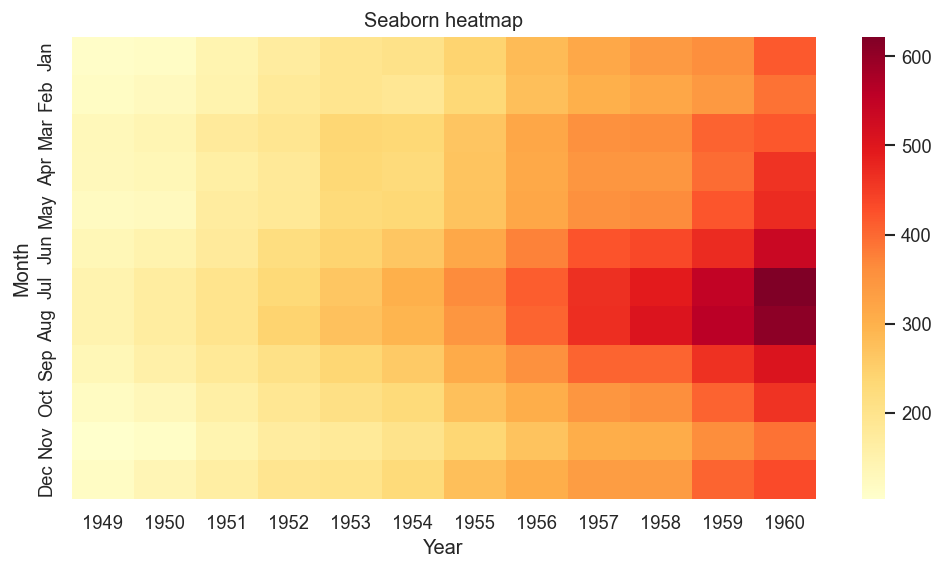

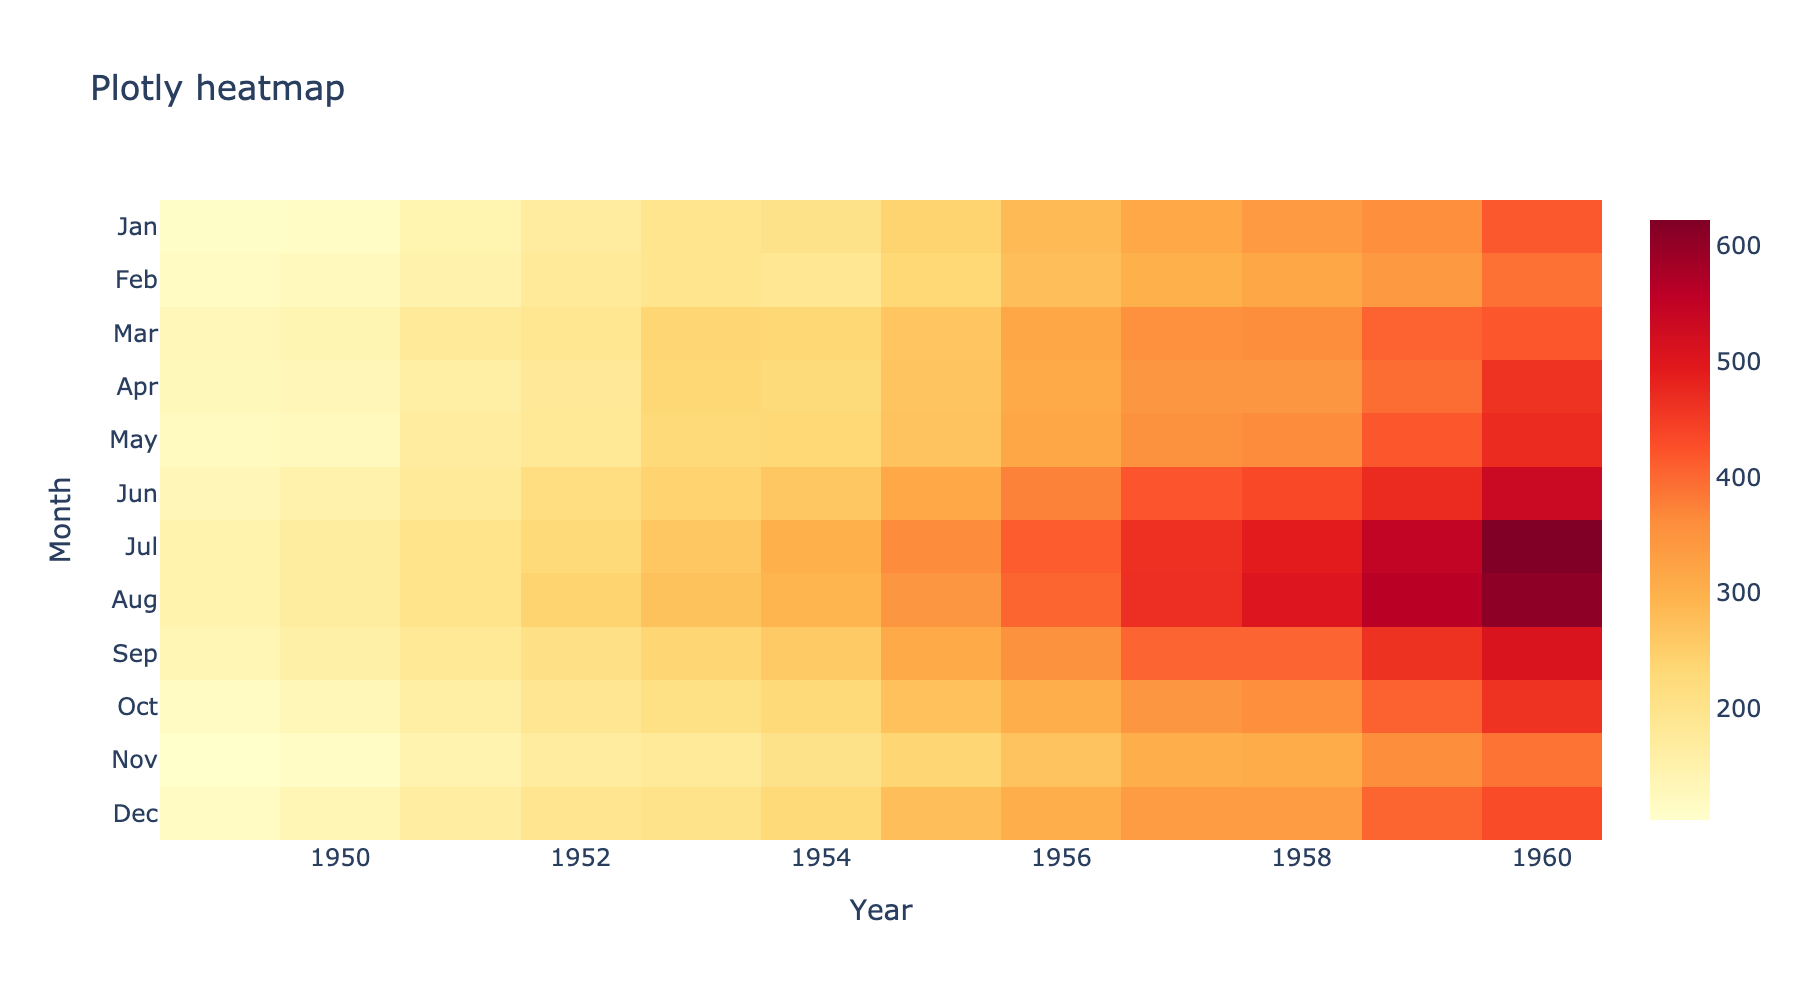

In [15]:
flights_pivot = flights.pivot(index="month", columns="year", values="passengers").reindex(MONTH_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(flights_pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(flights_pivot.columns)), flights_pivot.columns)
ax.set_yticks(range(len(flights_pivot.index)), flights_pivot.index)
ax.set_title("Matplotlib heatmap")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Passengers")
save_matplotlib(fig, "14_heatmap")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(flights_pivot, cmap="YlOrRd", ax=ax)
ax.set(title="Seaborn heatmap", xlabel="Year", ylabel="Month")
plt.show()

fig_plotly = px.imshow(
    flights_pivot,
    color_continuous_scale="YlOrRd",
    aspect="auto",
    template="plotly_white",
    title="Plotly heatmap",
)
fig_plotly.update_layout(xaxis_title="Year", yaxis_title="Month")
show_plotly(fig_plotly, width=900, height=500)

## 15. Correlation Heatmap

            **What question does this plot answer?**
            A correlation heatmap answers: which variables move together strongly, weakly, or in opposite directions?

            **What data does it need?**
            It needs a table with several numeric columns.

            **Key parameters to notice**
            - ``corr()``
- ``center=0``
- ``cmap``
- ``annot``
- ``mask``

            **Common mistakes**
            - Including too many variables and making the figure unreadable.
- Forgetting that correlation does not prove causation.
- Using a palette that does not clearly separate negative from positive values.

            **What the code below does**
            - A smaller feature subset keeps the matrix readable.
- The diverging palette is centered at zero so negative and positive correlations are easy to compare.
- Plotly and Seaborn both handle numeric matrix inputs well here.

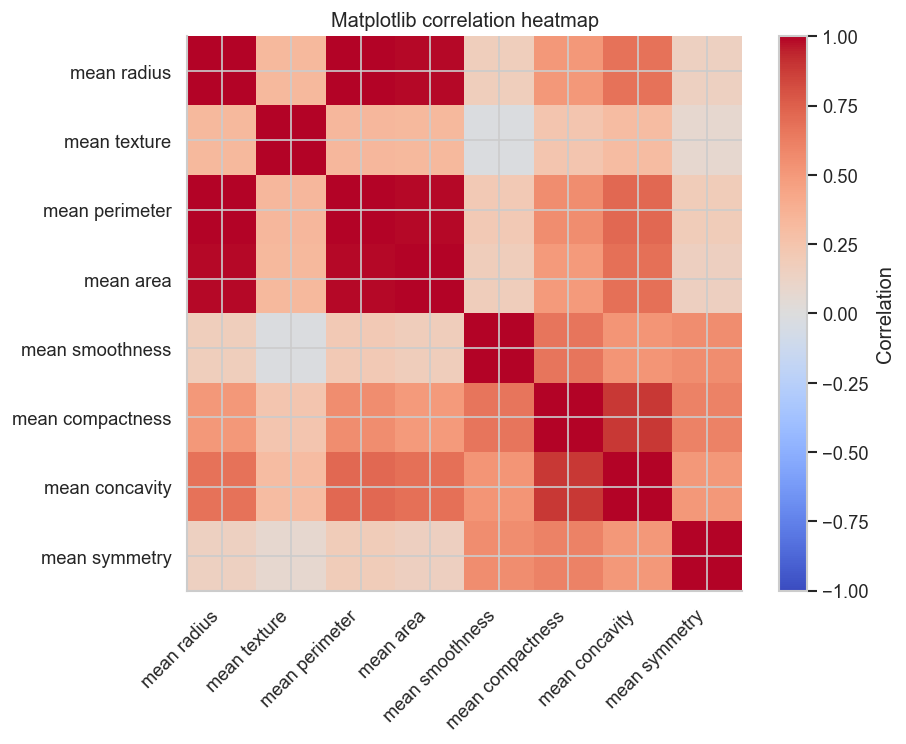

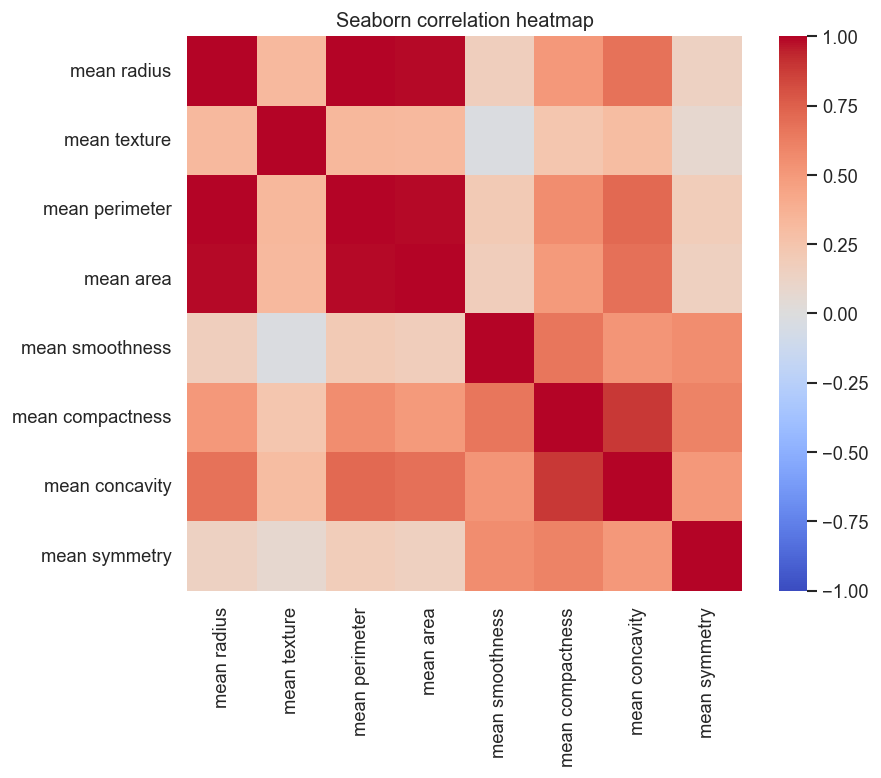

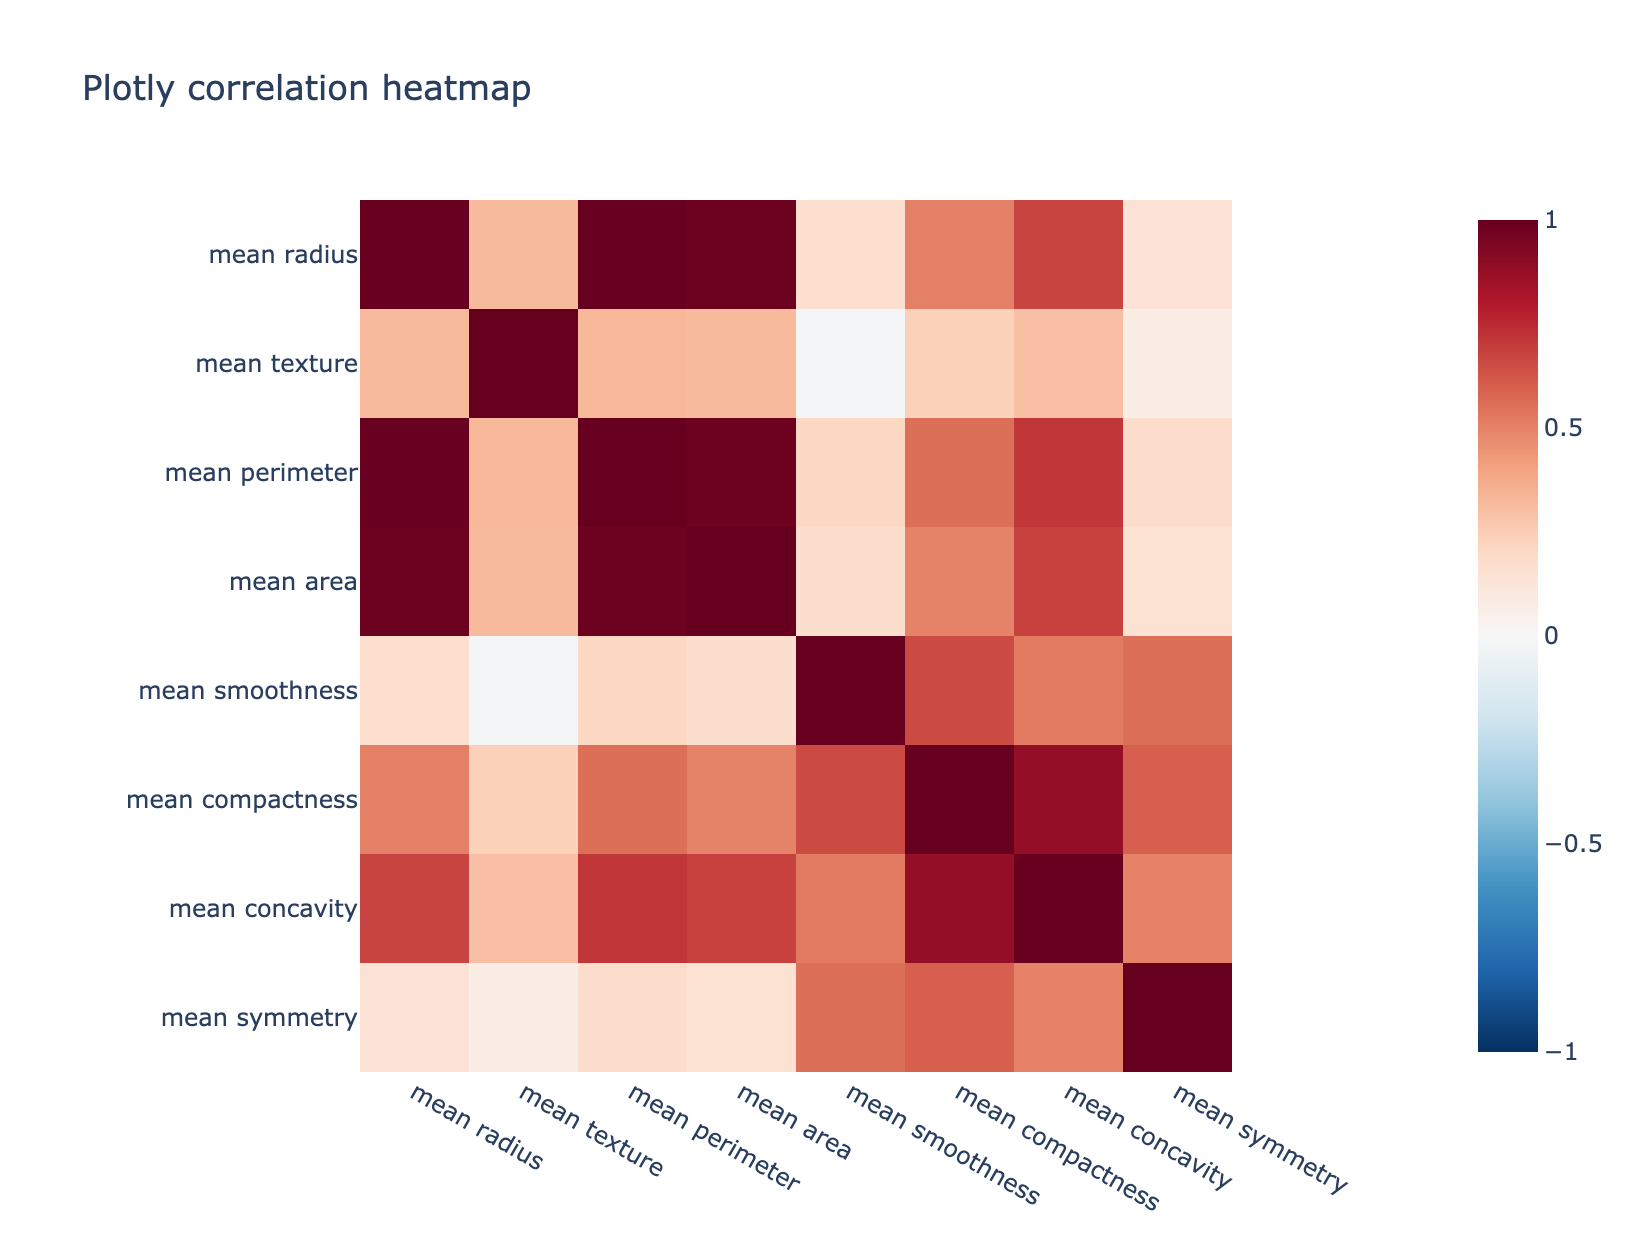

In [16]:
corr_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean symmetry",
]
corr_matrix = breast_cancer[corr_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)), corr_features, rotation=45, ha="right")
ax.set_yticks(range(len(corr_features)), corr_features)
ax.set_title("Matplotlib correlation heatmap")
fig.colorbar(image, ax=ax, label="Correlation")
save_matplotlib(fig, "15_correlation_heatmap")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set(title="Seaborn correlation heatmap")
plt.show()

fig_plotly = px.imshow(
    corr_matrix,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    template="plotly_white",
    title="Plotly correlation heatmap",
)
show_plotly(fig_plotly, width=820, height=620)

## 16. Error Bar Plot

            **What question does this plot answer?**
            An error bar plot answers: what is the summary value, and how uncertain or variable is it?

            **What data does it need?**
            It needs a summary value plus an uncertainty measure such as SD, SE, or CI.

            **Key parameters to notice**
            - ``yerr``
- ``capsize``
- ``errorbar``
- ``estimator``
- ``error_y``

            **Common mistakes**
            - Showing error bars without saying what they mean.
- Using error bars to hide the raw sample size.
- Confusing variability with uncertainty.

            **What the code below does**
            - This example summarizes T-cell counts by condition with the standard error of the mean.
- Matplotlib makes the uncertainty columns explicit, which is a good habit.
- Seaborn can estimate and draw standard errors directly from the raw table.

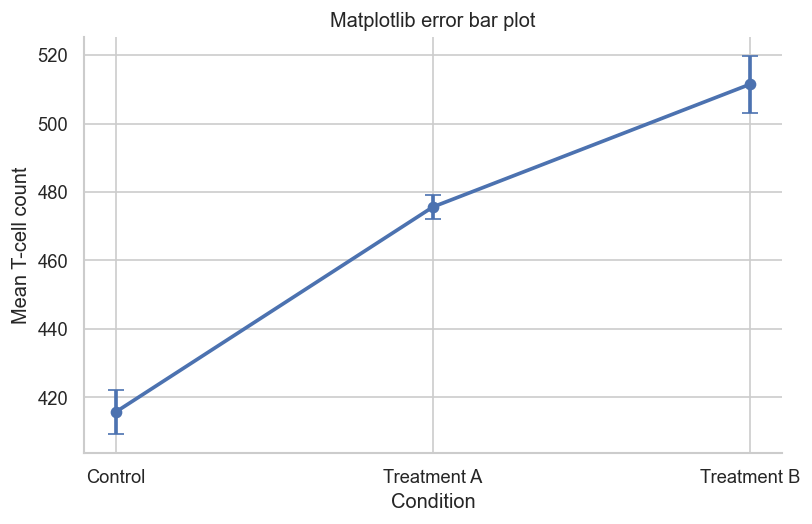

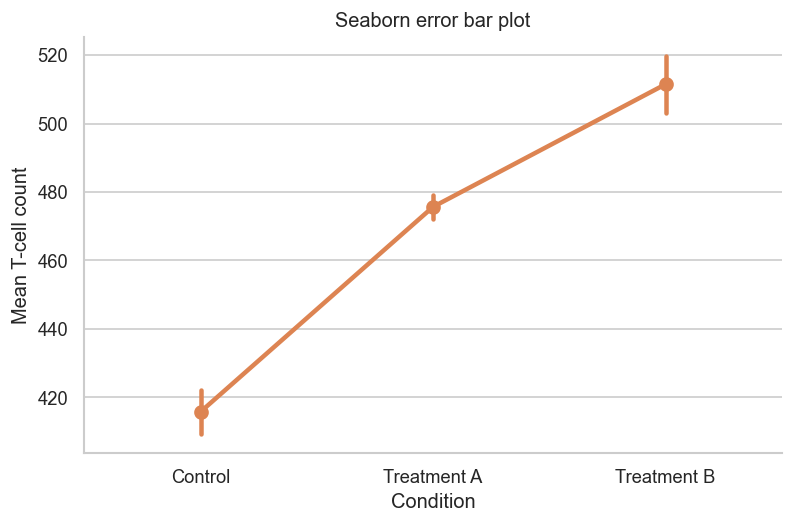

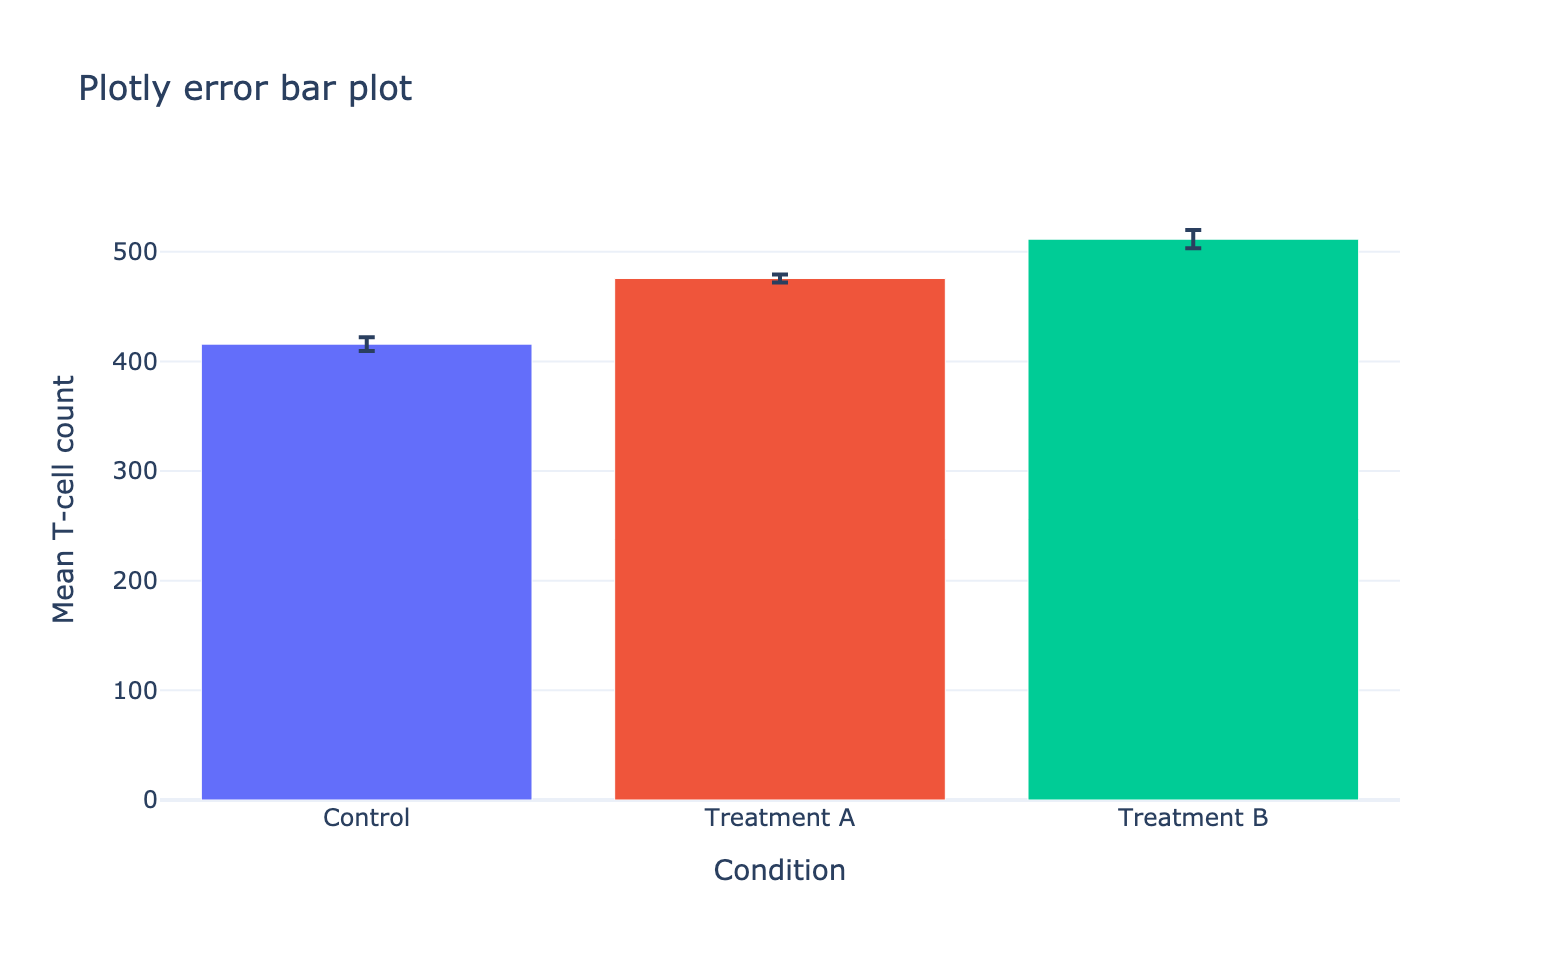

In [17]:
tcell_counts = cell_counts[cell_counts["cell_type"] == "T cells"].copy()
error_summary = (
    tcell_counts.groupby("condition", observed=False)["count"]
    .agg(mean_count="mean", sd_count="std", n="size")
    .reset_index()
)
error_summary["se_count"] = error_summary["sd_count"] / np.sqrt(error_summary["n"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(
    error_summary["condition"],
    error_summary["mean_count"],
    yerr=error_summary["se_count"],
    fmt="o-",
    linewidth=2.2,
    capsize=5,
    color="#4c72b0",
)
ax.set(title="Matplotlib error bar plot", xlabel="Condition", ylabel="Mean T-cell count")
save_matplotlib(fig, "16_error_bar_plot")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.pointplot(data=tcell_counts, x="condition", y="count", errorbar="se", color="#dd8452", ax=ax)
ax.set(title="Seaborn error bar plot", xlabel="Condition", ylabel="Mean T-cell count")
plt.show()

fig_plotly = px.bar(
    error_summary,
    x="condition",
    y="mean_count",
    error_y="se_count",
    color="condition",
    template="plotly_white",
    title="Plotly error bar plot",
)
fig_plotly.update_layout(showlegend=False, xaxis_title="Condition", yaxis_title="Mean T-cell count")
show_plotly(fig_plotly)

## 17. Multi-panel Figure

            **What question does this plot answer?**
            A multi-panel figure answers: can related views be compared side by side in one coherent layout?

            **What data does it need?**
            It needs several related plots that support the same story.

            **Key parameters to notice**
            - ``plt.subplots``
- ``sharex` / `sharey``
- ``FacetGrid``
- ``make_subplots``
- ``suptitle``

            **Common mistakes**
            - Mixing unrelated messages into one figure.
- Using inconsistent axis scales across comparable panels.
- Making the panel layout so dense that labels become unreadable.

            **What the code below does**
            - Matplotlib uses a 2x2 grid and explicit axes control.
- Seaborn uses `FacetGrid` to create small multiples from a dataframe.
- Plotly uses `make_subplots` to combine different traces into one layout.

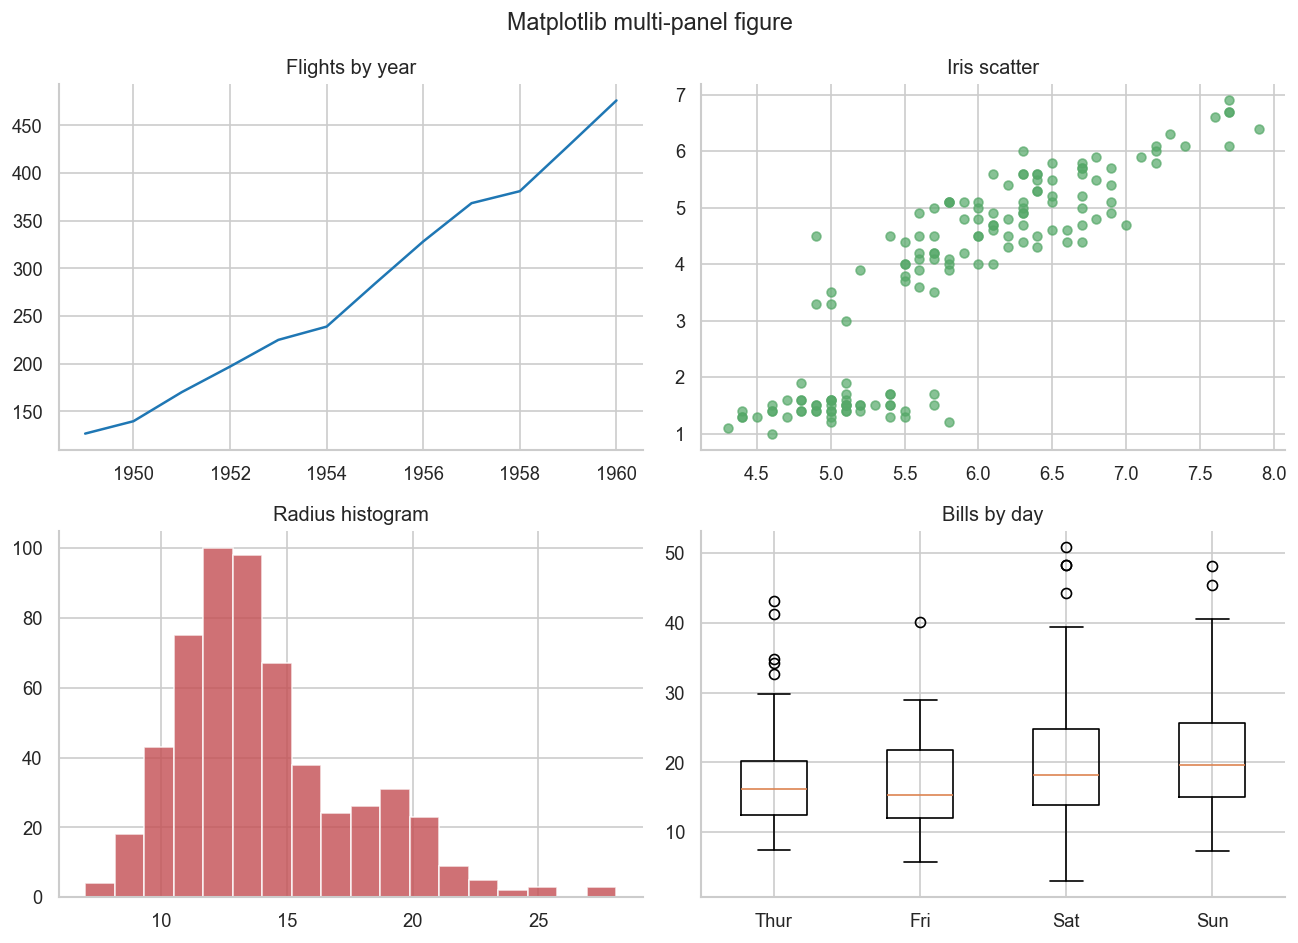

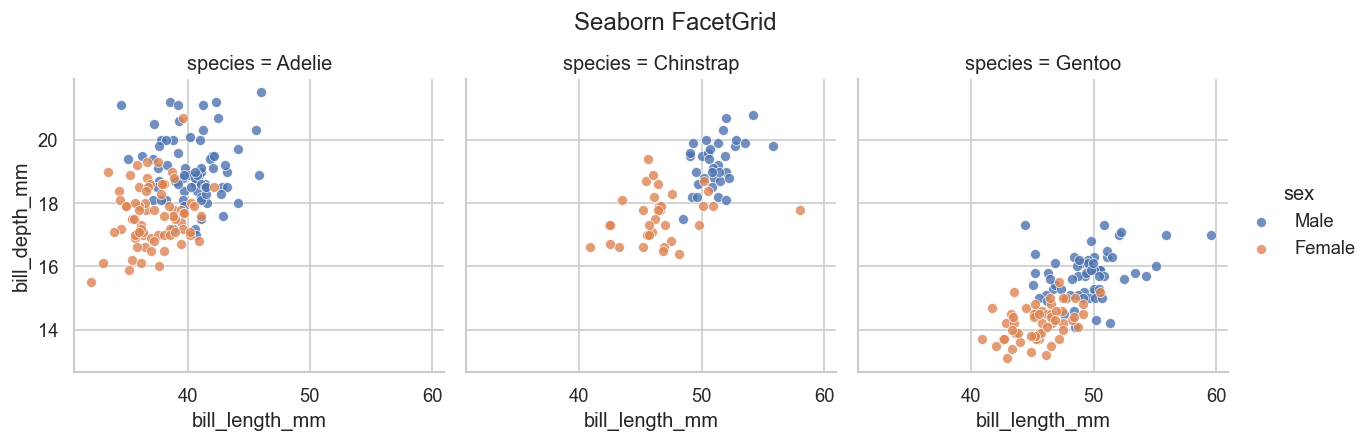

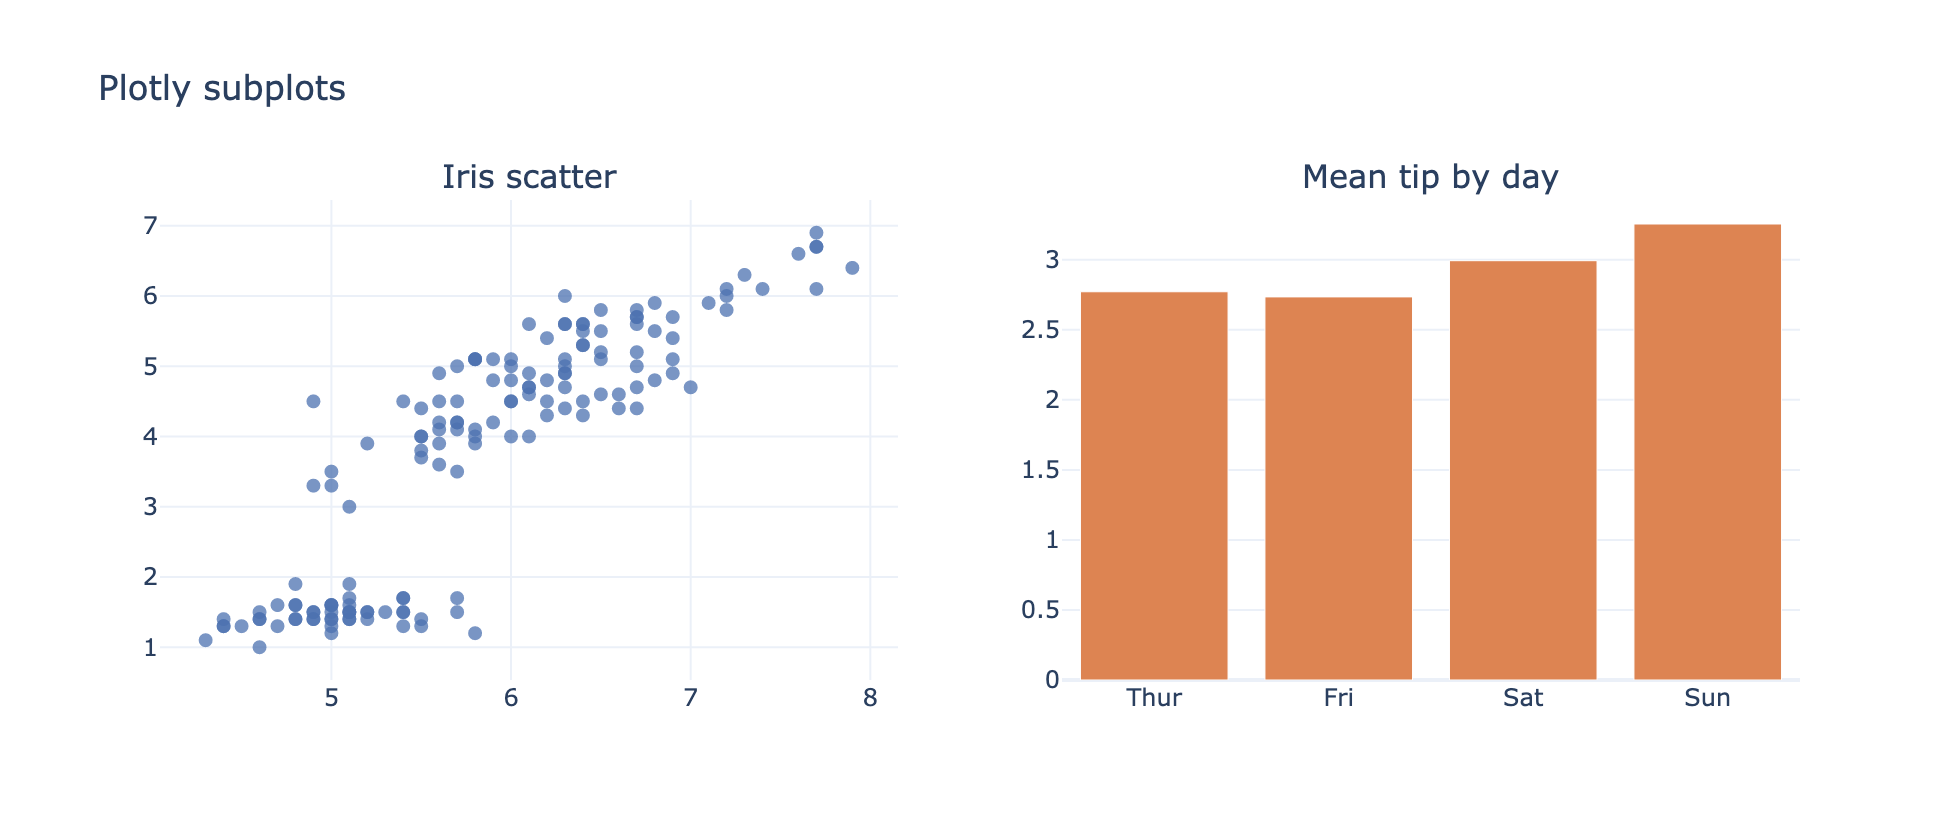

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(flights_by_year["year"], flights_by_year["passengers"], color="#1f77b4")
axes[0, 0].set_title("Flights by year")
axes[0, 1].scatter(iris["sepal_length"], iris["petal_length"], s=28, alpha=0.7, color="#55a868")
axes[0, 1].set_title("Iris scatter")
axes[1, 0].hist(breast_cancer["mean radius"], bins=18, color="#c44e52", alpha=0.8)
axes[1, 0].set_title("Radius histogram")
axes[1, 1].boxplot(bill_groups, tick_labels=DAY_ORDER)
axes[1, 1].set_title("Bills by day")
fig.suptitle("Matplotlib multi-panel figure", fontsize=14)
fig.tight_layout()
save_matplotlib(fig, "17_multi_panel_figure")
plt.show()

facet = sns.FacetGrid(
    penguins.dropna(subset=["species", "bill_length_mm", "bill_depth_mm", "sex"]),
    col="species",
    hue="sex",
    height=3.5,
    aspect=1,
)
facet.map_dataframe(sns.scatterplot, x="bill_length_mm", y="bill_depth_mm", alpha=0.8)
facet.add_legend()
facet.fig.suptitle("Seaborn FacetGrid", y=1.05)
plt.show()

subplot_fig = make_subplots(rows=1, cols=2, subplot_titles=("Iris scatter", "Mean tip by day"))
subplot_fig.add_trace(
    go.Scatter(
        x=iris["sepal_length"],
        y=iris["petal_length"],
        mode="markers",
        marker=dict(color="#4c72b0", size=7, opacity=0.75),
        name="Iris points",
    ),
    row=1,
    col=1,
)
subplot_fig.add_trace(
    go.Bar(x=bar_data["day"], y=bar_data["mean_tip"], marker_color="#dd8452", name="Mean tip"),
    row=1,
    col=2,
)
subplot_fig.update_layout(template="plotly_white", title="Plotly subplots", showlegend=False)
show_plotly(subplot_fig, width=980, height=420)

## 18. PCA Plot

            **What question does this plot answer?**
            A PCA plot answers: after projecting high-dimensional data into two directions of greatest variance, do samples separate or cluster?

            **What data does it need?**
            It needs a numeric matrix, usually scaled first, then transformed into principal components.

            **Key parameters to notice**
            - ``PCA``
- ``explained_variance_ratio_``
- ``hue` or `color``
- ``alpha``
- ``legend``

            **Common mistakes**
            - Interpreting PCA as proof of biological truth instead of a summary view.
- Skipping scaling when variables are on different scales.
- Forgetting to explain what the groups mean.

            **What the code below does**
            - The PCA coordinates were generated earlier from the breast cancer features.
- All three libraries show the same two projected columns: `pc1` and `pc2`.
- The saved figure is a clean Matplotlib PCA scatter plot.

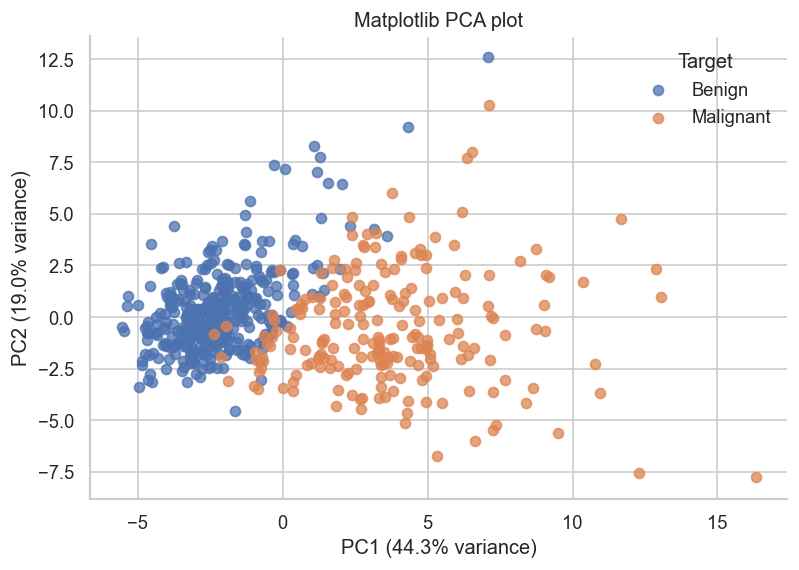

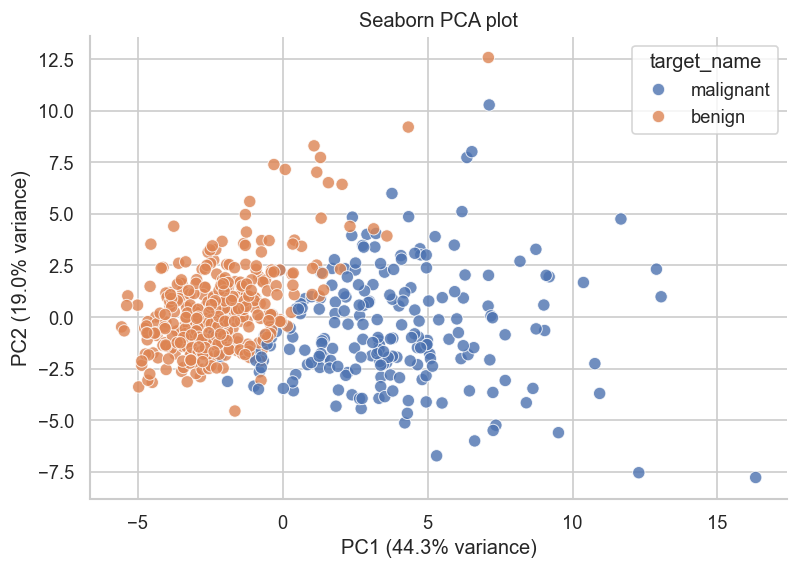

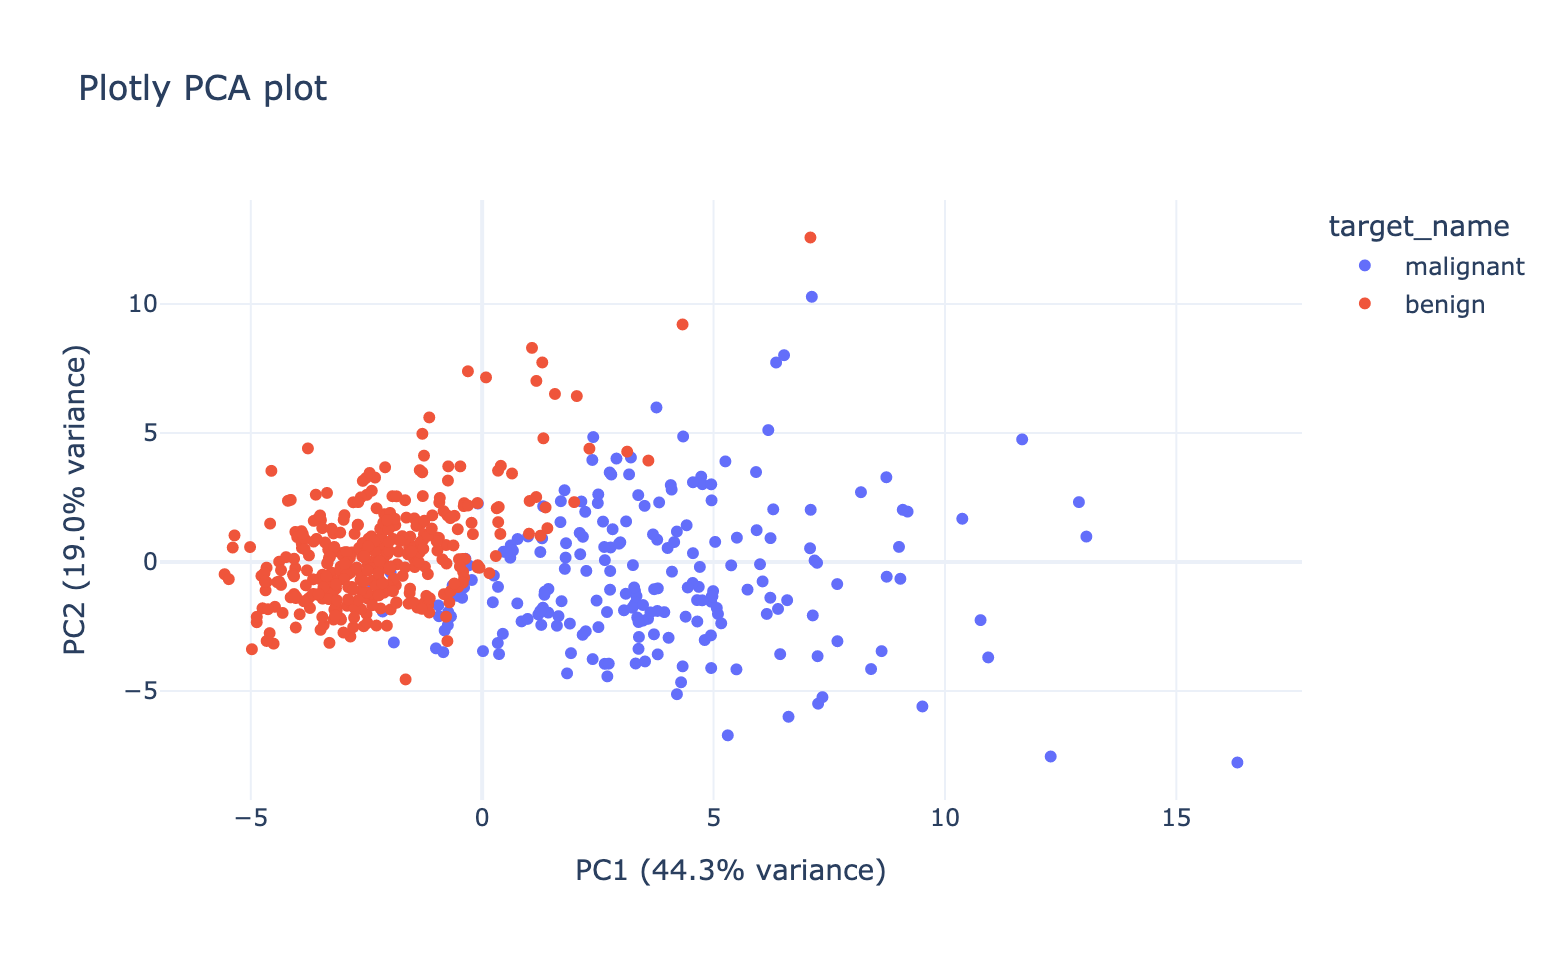

In [19]:
explained_variance = PCA(n_components=2, random_state=SEED).fit(StandardScaler().fit_transform(breast_cancer[feature_columns])).explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, group in pca_embedding.groupby("target_name"):
    ax.scatter(group["pc1"], group["pc2"], s=36, alpha=0.75, label=label.title())
ax.set(
    title="Matplotlib PCA plot",
    xlabel=f"PC1 ({explained_variance[0] * 100:.1f}% variance)",
    ylabel=f"PC2 ({explained_variance[1] * 100:.1f}% variance)",
)
ax.legend(frameon=False, title="Target")
save_matplotlib(fig, "18_pca_plot")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.scatterplot(data=pca_embedding, x="pc1", y="pc2", hue="target_name", s=55, alpha=0.8, ax=ax)
ax.set(
    title="Seaborn PCA plot",
    xlabel=f"PC1 ({explained_variance[0] * 100:.1f}% variance)",
    ylabel=f"PC2 ({explained_variance[1] * 100:.1f}% variance)",
)
plt.show()

fig_plotly = px.scatter(
    pca_embedding,
    x="pc1",
    y="pc2",
    color="target_name",
    template="plotly_white",
    title="Plotly PCA plot",
)
fig_plotly.update_layout(
    xaxis_title=f"PC1 ({explained_variance[0] * 100:.1f}% variance)",
    yaxis_title=f"PC2 ({explained_variance[1] * 100:.1f}% variance)",
)
show_plotly(fig_plotly)

## 19. UMAP-like Embedding Plot

            **What question does this plot answer?**
            This plot answers: when we use a nonlinear 2D embedding, do local neighborhoods or groups become easier to separate visually?

            **What data does it need?**
            It needs a high-dimensional numeric matrix and an embedding method. Here we use t-SNE as a UMAP-like stand-in.

            **Key parameters to notice**
            - ``perplexity``
- ``learning_rate``
- ``random_state``
- ``alpha``
- ``hover_name``

            **Common mistakes**
            - Treating exact distances in the 2D map as literal truth.
- Comparing embeddings without fixing the random seed.
- Forgetting that different parameter choices change the layout.

            **What the code below does**
            - The embedding was created earlier with t-SNE so the notebook stays fast in later cells.
- The title says UMAP-like on purpose because the goal is the visual idea, not a strict package dependency.
- Hover labels in Plotly make exploration easier when you want to inspect points.

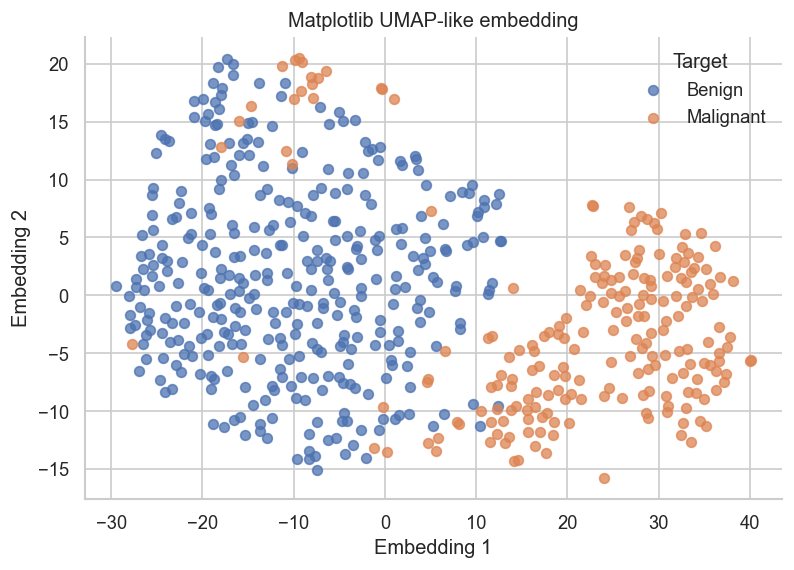

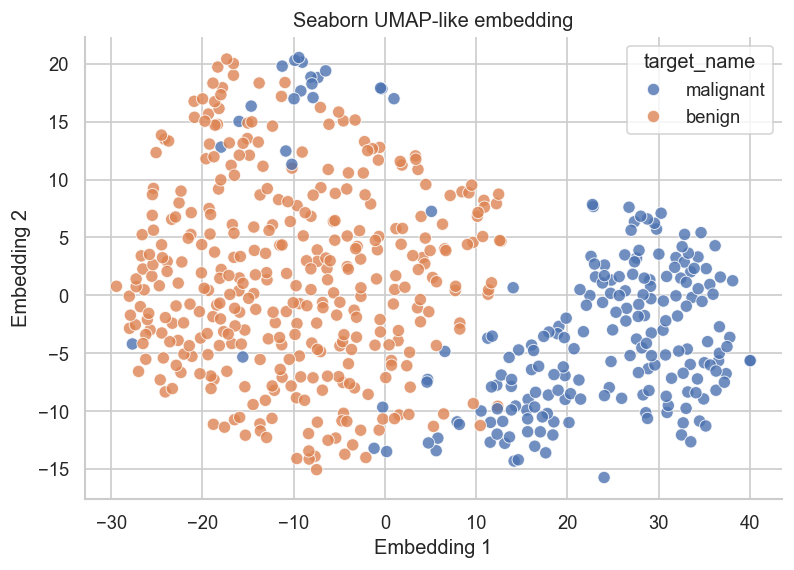

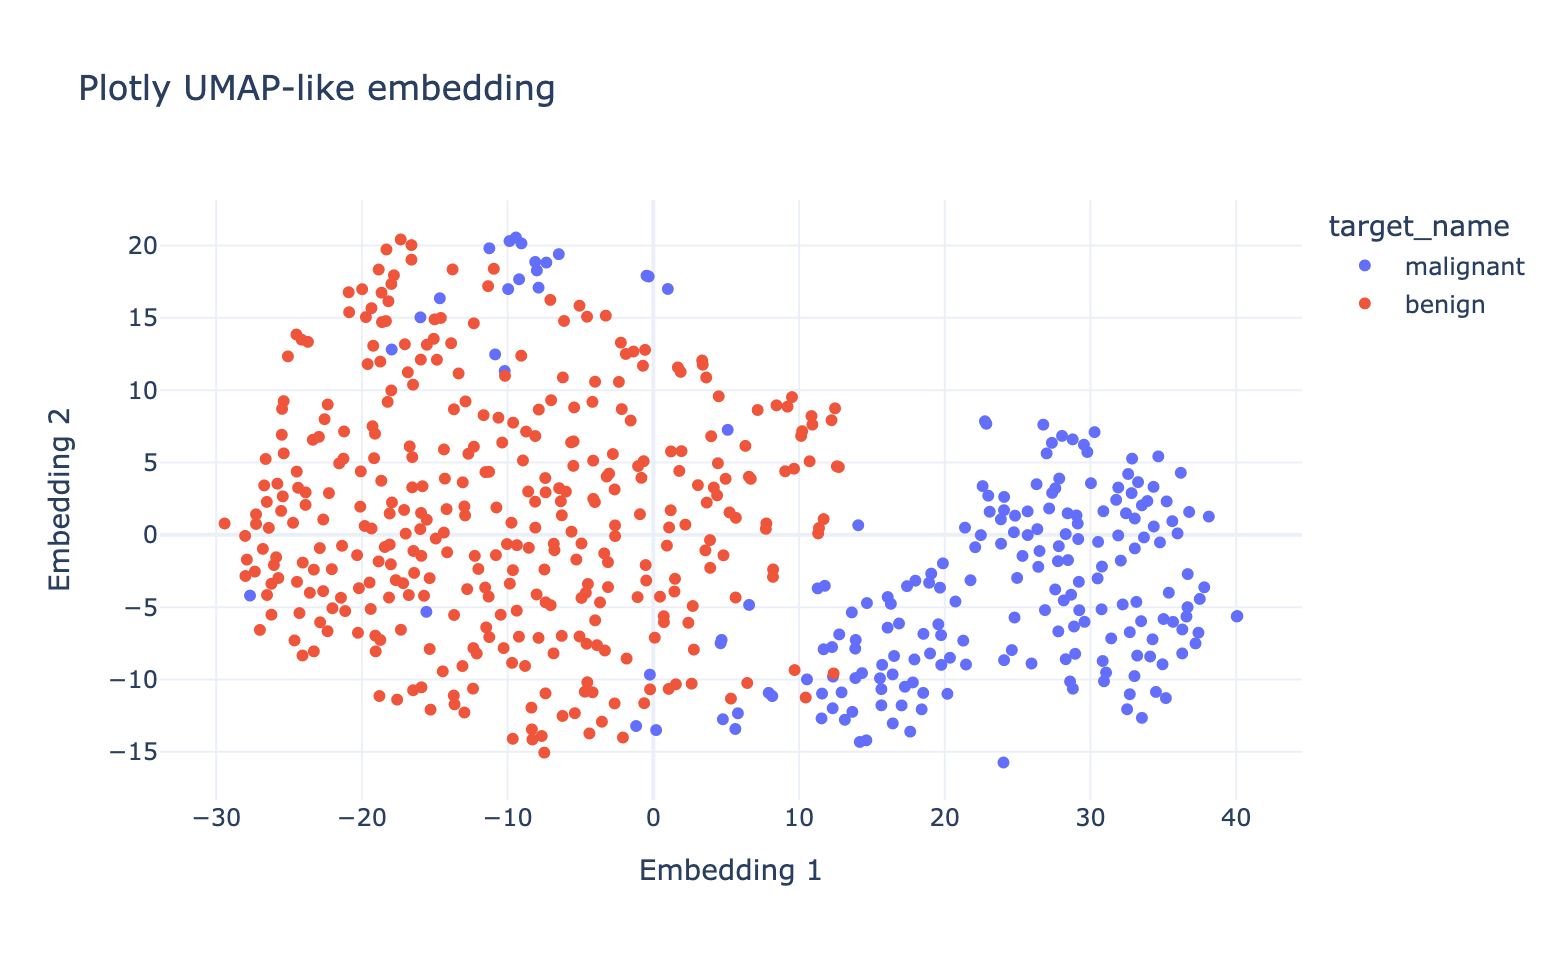

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for label, group in umap_like_embedding.groupby("target_name"):
    ax.scatter(group["embed1"], group["embed2"], s=34, alpha=0.75, label=label.title())
ax.set(title="Matplotlib UMAP-like embedding", xlabel="Embedding 1", ylabel="Embedding 2")
ax.legend(frameon=False, title="Target")
save_matplotlib(fig, "19_umap_like_embedding")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.scatterplot(data=umap_like_embedding, x="embed1", y="embed2", hue="target_name", s=55, alpha=0.8, ax=ax)
ax.set(title="Seaborn UMAP-like embedding", xlabel="Embedding 1", ylabel="Embedding 2")
plt.show()

fig_plotly = px.scatter(
    umap_like_embedding,
    x="embed1",
    y="embed2",
    color="target_name",
    template="plotly_white",
    title="Plotly UMAP-like embedding",
)
fig_plotly.update_layout(xaxis_title="Embedding 1", yaxis_title="Embedding 2")
show_plotly(fig_plotly)

## 20. Volcano Plot with Synthetic Gene Expression Data

            **What question does this plot answer?**
            A volcano plot answers: which genes have both a large effect size and strong statistical significance?

            **What data does it need?**
            It needs a fold-change column and a p-value or adjusted p-value column.

            **Key parameters to notice**
            - ``log2_fc``
- ``-log10(p)``
- `threshold lines`
- ``alpha``
- ``hover_name``

            **Common mistakes**
            - Using raw p-values when adjusted p-values are the real decision rule.
- Forgetting to explain threshold lines.
- Labeling too many genes and making the figure unreadable.

            **What the code below does**
            - The y-axis uses `-log10(adj_p_value)` so more significant genes appear higher.
- The status column classifies genes as Up, Down, or Neutral.
- Plotly adds hover names, which is useful for inspecting individual genes.

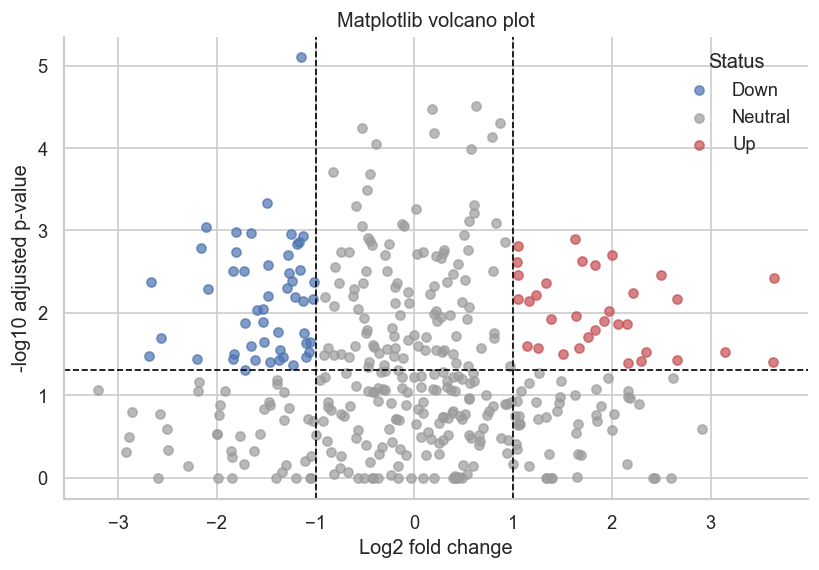

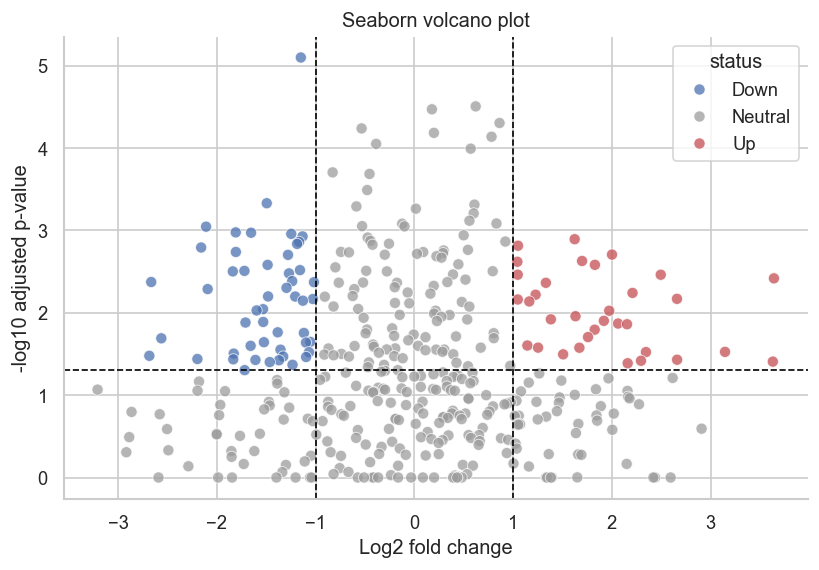

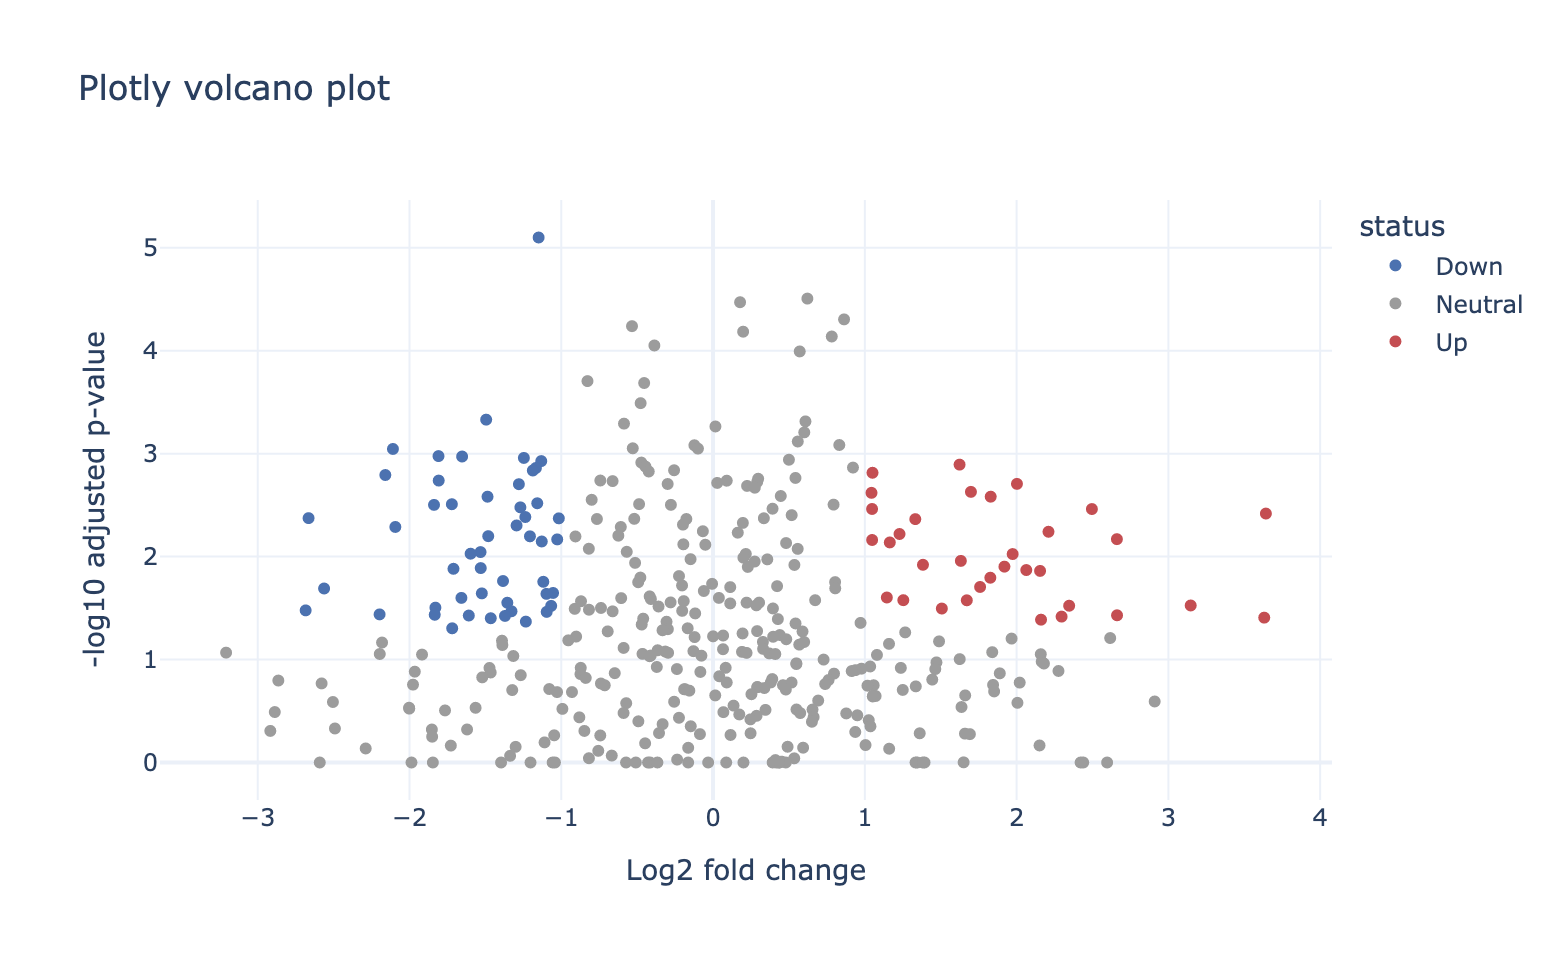

In [21]:
volcano = synthetic_gene_expression.copy()
volcano["neg_log10_adj_p"] = -np.log10(volcano["adj_p_value"].clip(lower=1e-12))
volcano_palette = {"Up": "#c44e52", "Down": "#4c72b0", "Neutral": "#9c9c9c"}

fig, ax = plt.subplots(figsize=(8, 5))
for status, group in volcano.groupby("status"):
    ax.scatter(group["log2_fc"], group["neg_log10_adj_p"], s=30, alpha=0.7, label=status, color=volcano_palette[status])
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.axvline(-1, color="black", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set(title="Matplotlib volcano plot", xlabel="Log2 fold change", ylabel="-log10 adjusted p-value")
ax.legend(frameon=False, title="Status")
save_matplotlib(fig, "20_volcano_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=volcano,
    x="log2_fc",
    y="neg_log10_adj_p",
    hue="status",
    palette=volcano_palette,
    alpha=0.75,
    s=45,
    ax=ax,
)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.axvline(-1, color="black", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set(title="Seaborn volcano plot", xlabel="Log2 fold change", ylabel="-log10 adjusted p-value")
plt.show()

fig_plotly = px.scatter(
    volcano,
    x="log2_fc",
    y="neg_log10_adj_p",
    color="status",
    hover_name="gene",
    color_discrete_map=volcano_palette,
    template="plotly_white",
    title="Plotly volcano plot",
)
fig_plotly.update_layout(xaxis_title="Log2 fold change", yaxis_title="-log10 adjusted p-value")
show_plotly(fig_plotly)

## 21. Model Performance Comparison Plot

            **What question does this plot answer?**
            This plot answers: how do models compare across evaluation metrics?

            **What data does it need?**
            It needs one model column, one metric column, and one numeric score column.

            **Key parameters to notice**
            - ``hue``
- ``metric``
- ``barmode='group'``
- ``errorbar``
- ``legend``

            **Common mistakes**
            - Averaging away too much information without showing variability.
- Comparing metrics with very different scales on the same axis without explanation.
- Using crowded legends when only a few models matter.

            **What the code below does**
            - We first summarize the fold-level scores into mean scores by model and metric.
- Grouped bars make side-by-side metric comparison easy.
- The saved figure is a Matplotlib grouped bar chart.

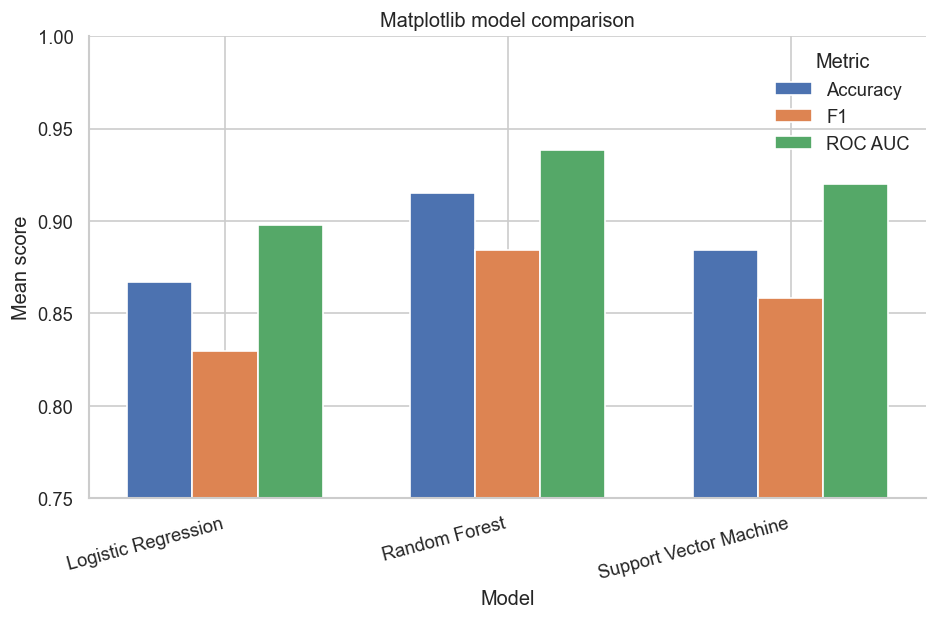

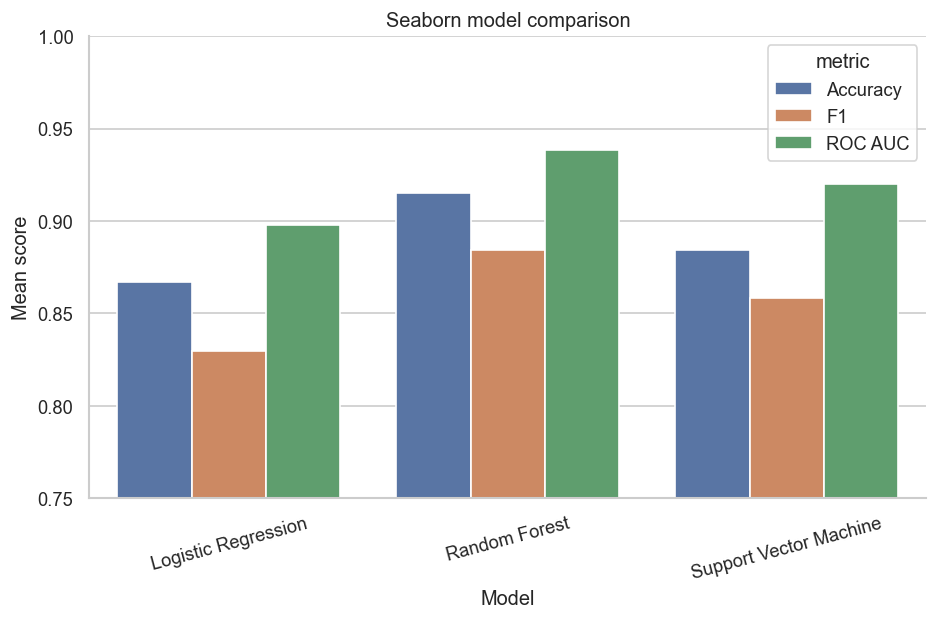

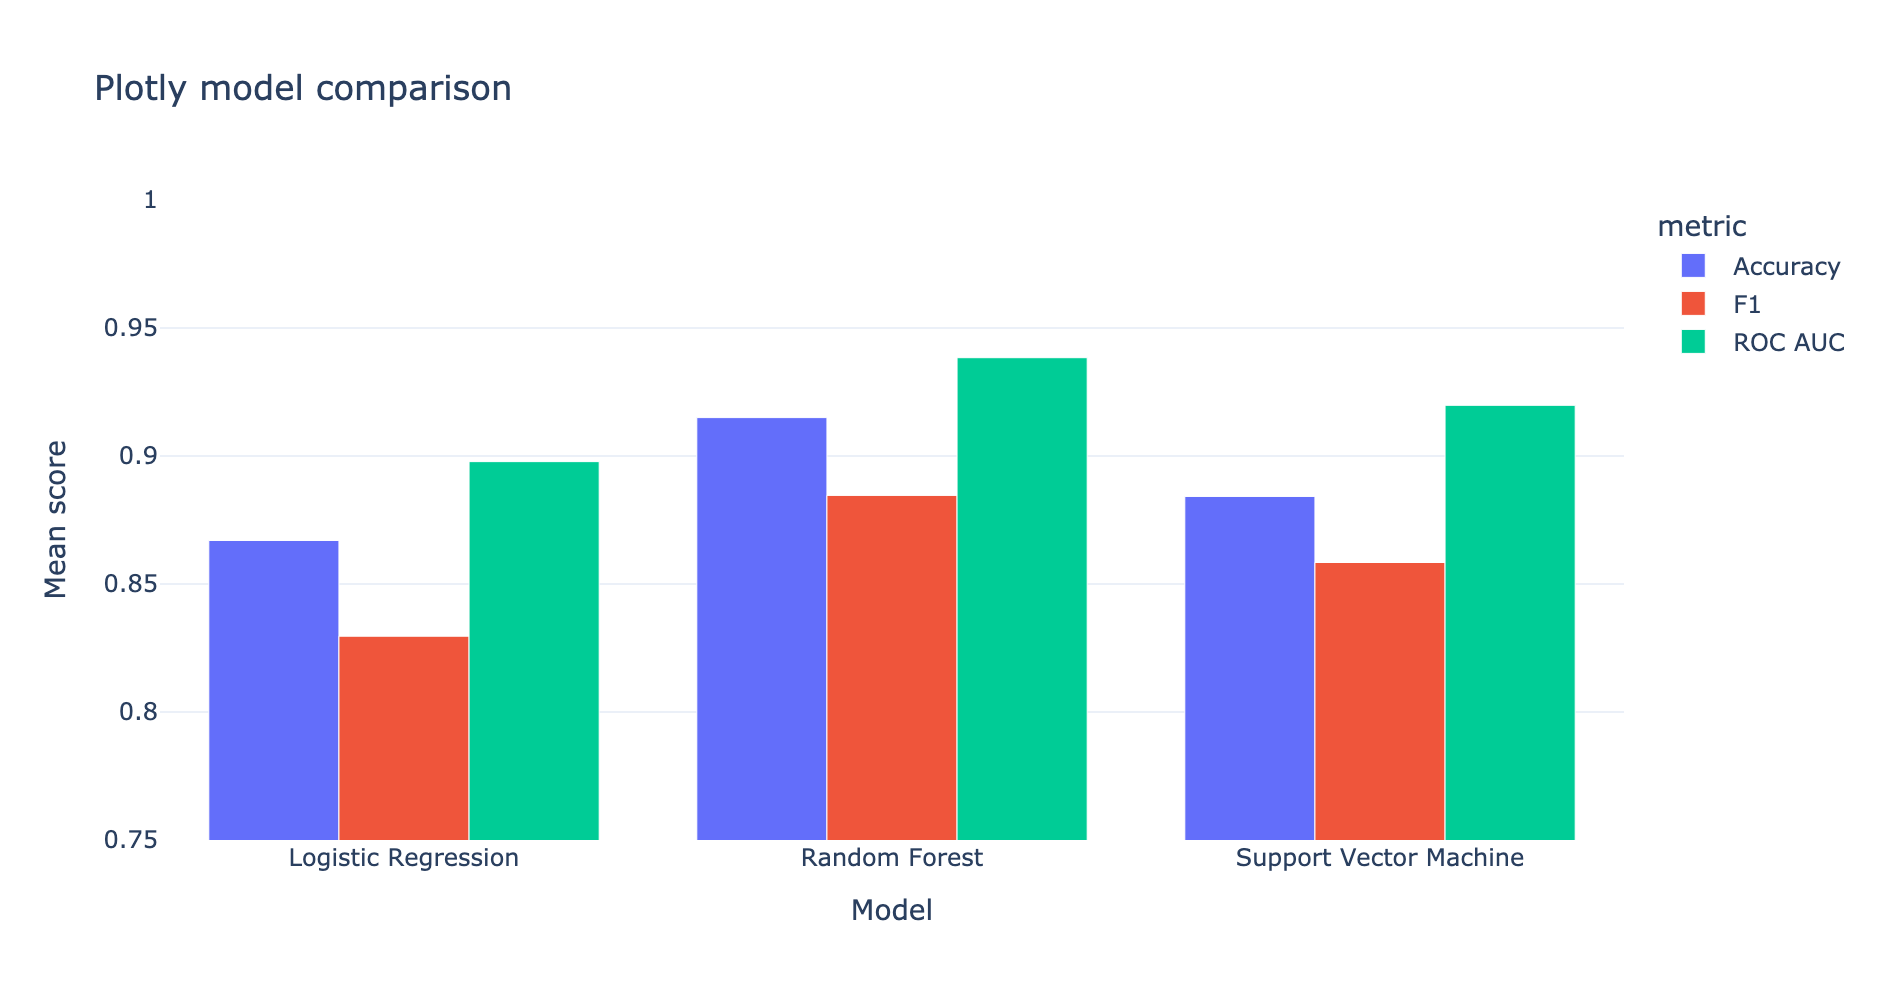

In [22]:
model_summary = (
    model_performance.groupby(["model", "metric"], observed=False)["score"]
    .mean()
    .reset_index()
)
model_order = ["Logistic Regression", "Random Forest", "Support Vector Machine"]
metric_order = ["Accuracy", "F1", "ROC AUC"]

pivot = model_summary.pivot(index="model", columns="metric", values="score").reindex(model_order)
x = np.arange(len(model_order))
width = 0.23

fig, ax = plt.subplots(figsize=(9, 5))
for idx, metric_name in enumerate(metric_order):
    ax.bar(x + (idx - 1) * width, pivot[metric_name], width=width, label=metric_name)
ax.set_xticks(x, model_order, rotation=15, ha="right")
ax.set_ylim(0.75, 1.0)
ax.set(title="Matplotlib model comparison", xlabel="Model", ylabel="Mean score")
ax.legend(frameon=False, title="Metric")
save_matplotlib(fig, "21_model_performance_comparison")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=model_summary, x="model", y="score", hue="metric", order=model_order, hue_order=metric_order, ax=ax)
ax.set_ylim(0.75, 1.0)
ax.set(title="Seaborn model comparison", xlabel="Model", ylabel="Mean score")
ax.tick_params(axis="x", rotation=15)
plt.show()

fig_plotly = px.bar(
    model_summary,
    x="model",
    y="score",
    color="metric",
    barmode="group",
    category_orders={"model": model_order, "metric": metric_order},
    template="plotly_white",
    title="Plotly model comparison",
)
fig_plotly.update_layout(xaxis_title="Model", yaxis_title="Mean score", yaxis_range=[0.75, 1.0])
show_plotly(fig_plotly, width=940, height=500)

## 22. Segmentation Metric Plot

            **What question does this plot answer?**
            This plot answers: how do segmentation models compare across metrics such as Dice, PQ, and F1?

            **What data does it need?**
            It needs one model column, one metric column, and one score column. A dataset or tissue column can add context.

            **Key parameters to notice**
            - ``hue``
- ``style``
- ``facet_col``
- ``barmode='group'``
- ``legend``

            **Common mistakes**
            - Comparing metrics without explaining that higher is better.
- Mixing tissues or datasets without labeling them clearly.
- Using too many models in one crowded panel.

            **What the code below does**
            - This example focuses on the Tumor subset to keep the grouped comparison readable.
- Because the metrics share the 0 to 1 scale, one y-axis is appropriate.
- The exported figure is a grouped Matplotlib bar plot.

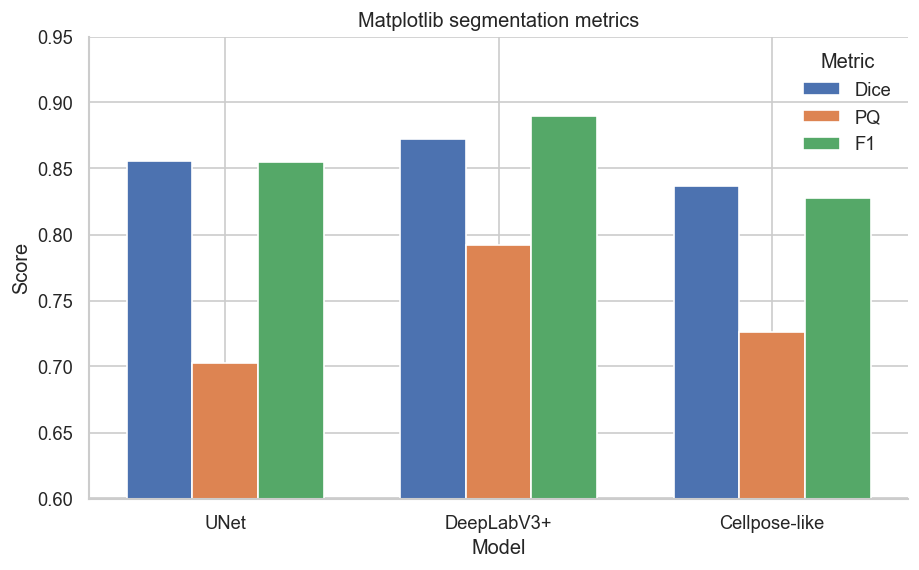

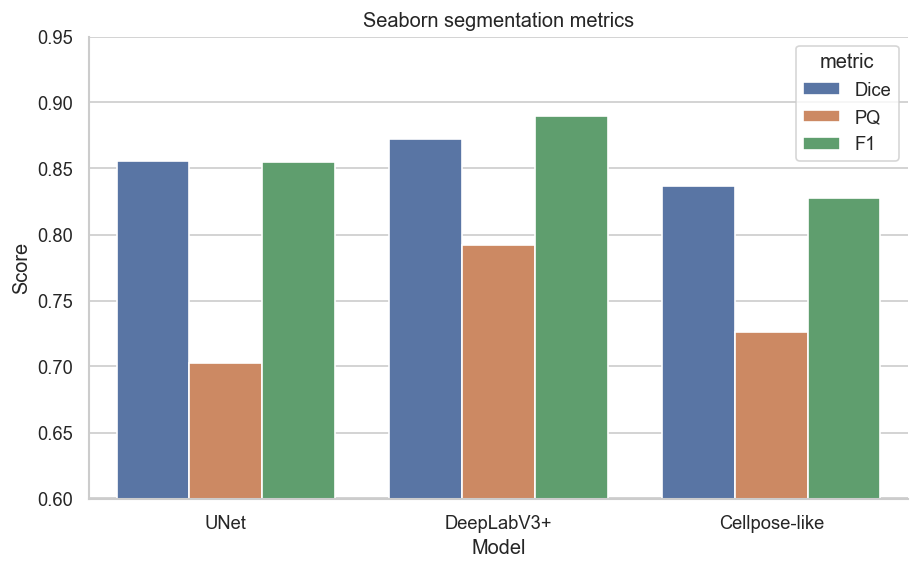

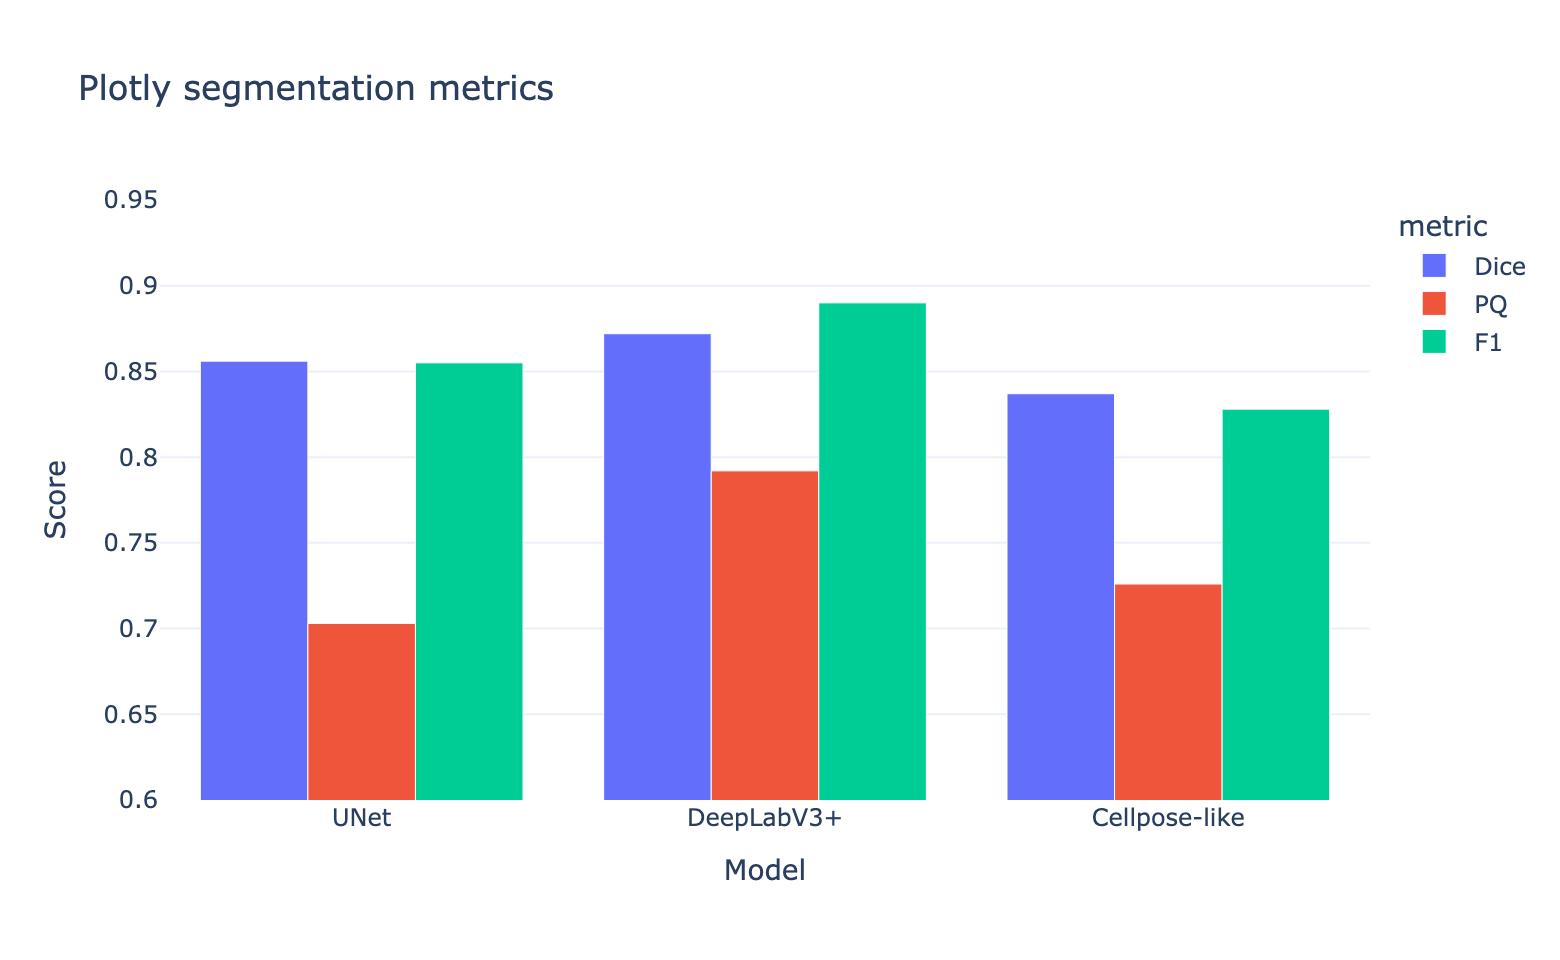

In [23]:
segmentation_tumor = segmentation_metrics[segmentation_metrics["tissue"] == "Tumor"].copy()
model_order = ["UNet", "DeepLabV3+", "Cellpose-like"]
metric_order = ["Dice", "PQ", "F1"]
seg_pivot = segmentation_tumor.pivot(index="model", columns="metric", values="score").reindex(model_order)
x = np.arange(len(model_order))
width = 0.24

fig, ax = plt.subplots(figsize=(8.8, 5))
for idx, metric_name in enumerate(metric_order):
    ax.bar(x + (idx - 1) * width, seg_pivot[metric_name], width=width, label=metric_name)
ax.set_xticks(x, model_order)
ax.set_ylim(0.6, 0.95)
ax.set(title="Matplotlib segmentation metrics", xlabel="Model", ylabel="Score")
ax.legend(frameon=False, title="Metric")
save_matplotlib(fig, "22_segmentation_metric_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8.8, 5))
sns.barplot(
    data=segmentation_tumor,
    x="model",
    y="score",
    hue="metric",
    order=model_order,
    hue_order=metric_order,
    ax=ax,
)
ax.set_ylim(0.6, 0.95)
ax.set(title="Seaborn segmentation metrics", xlabel="Model", ylabel="Score")
plt.show()

fig_plotly = px.bar(
    segmentation_tumor,
    x="model",
    y="score",
    color="metric",
    barmode="group",
    category_orders={"model": model_order, "metric": metric_order},
    template="plotly_white",
    title="Plotly segmentation metrics",
)
fig_plotly.update_layout(xaxis_title="Model", yaxis_title="Score", yaxis_range=[0.6, 0.95])
show_plotly(fig_plotly)

## 23. Plot Customization: Size, Labels, Title, Colors, Legend, Ticks, Grid, Fonts, and Annotations

            **What question does this plot answer?**
            This section answers: how do I turn a technically correct plot into a clearer and more intentional plot?

            **What data does it need?**
            It starts with the same data as a normal scatter plot, then layers design decisions on top.

            **Key parameters to notice**
            - ``figsize``
- ``fontsize``
- ``palette``
- ``tick_params``
- ``annotate``

            **Common mistakes**
            - Adding decoration without improving meaning.
- Using fonts or colors that overwhelm the data.
- Forgetting to label the key point you want the viewer to notice.

            **What the code below does**
            - Matplotlib shows the most explicit customization controls.
- Seaborn starts from a cleaner default and then uses Matplotlib methods for the final polish.
- Plotly uses `update_layout`, `update_traces`, and `add_annotation` for the same ideas.

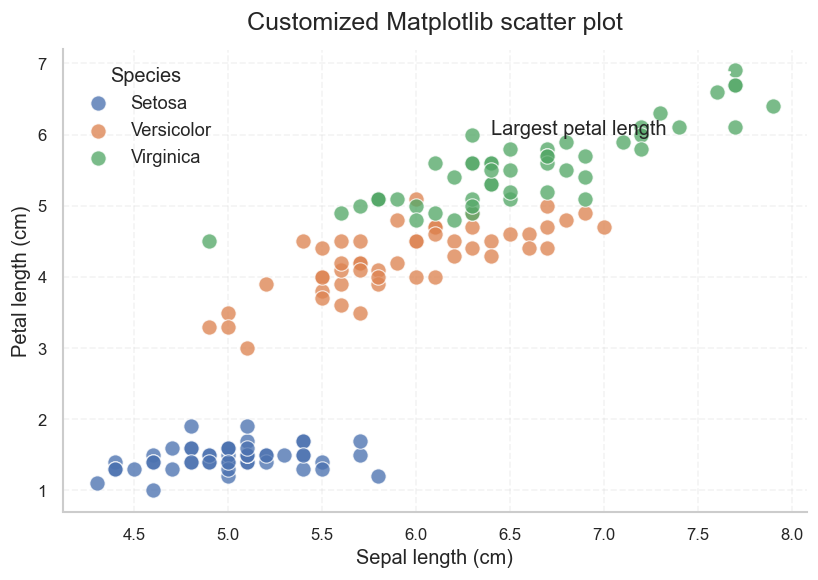

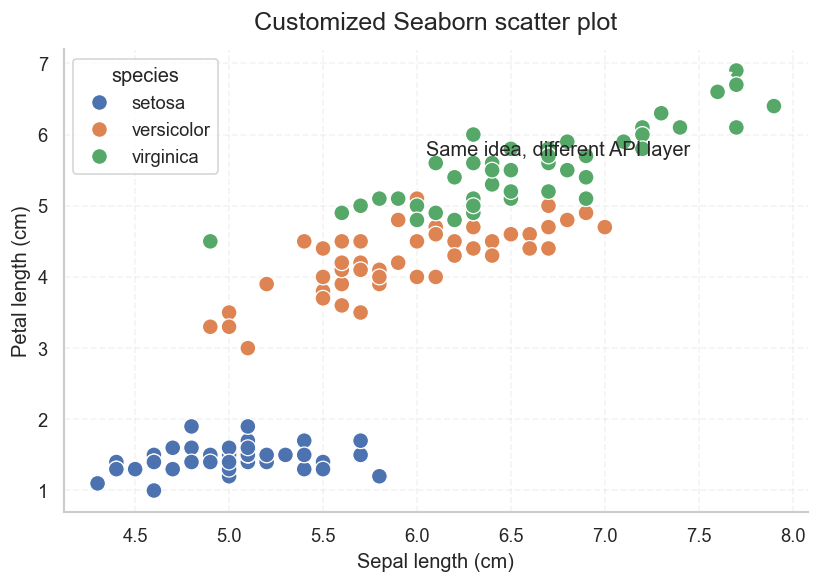

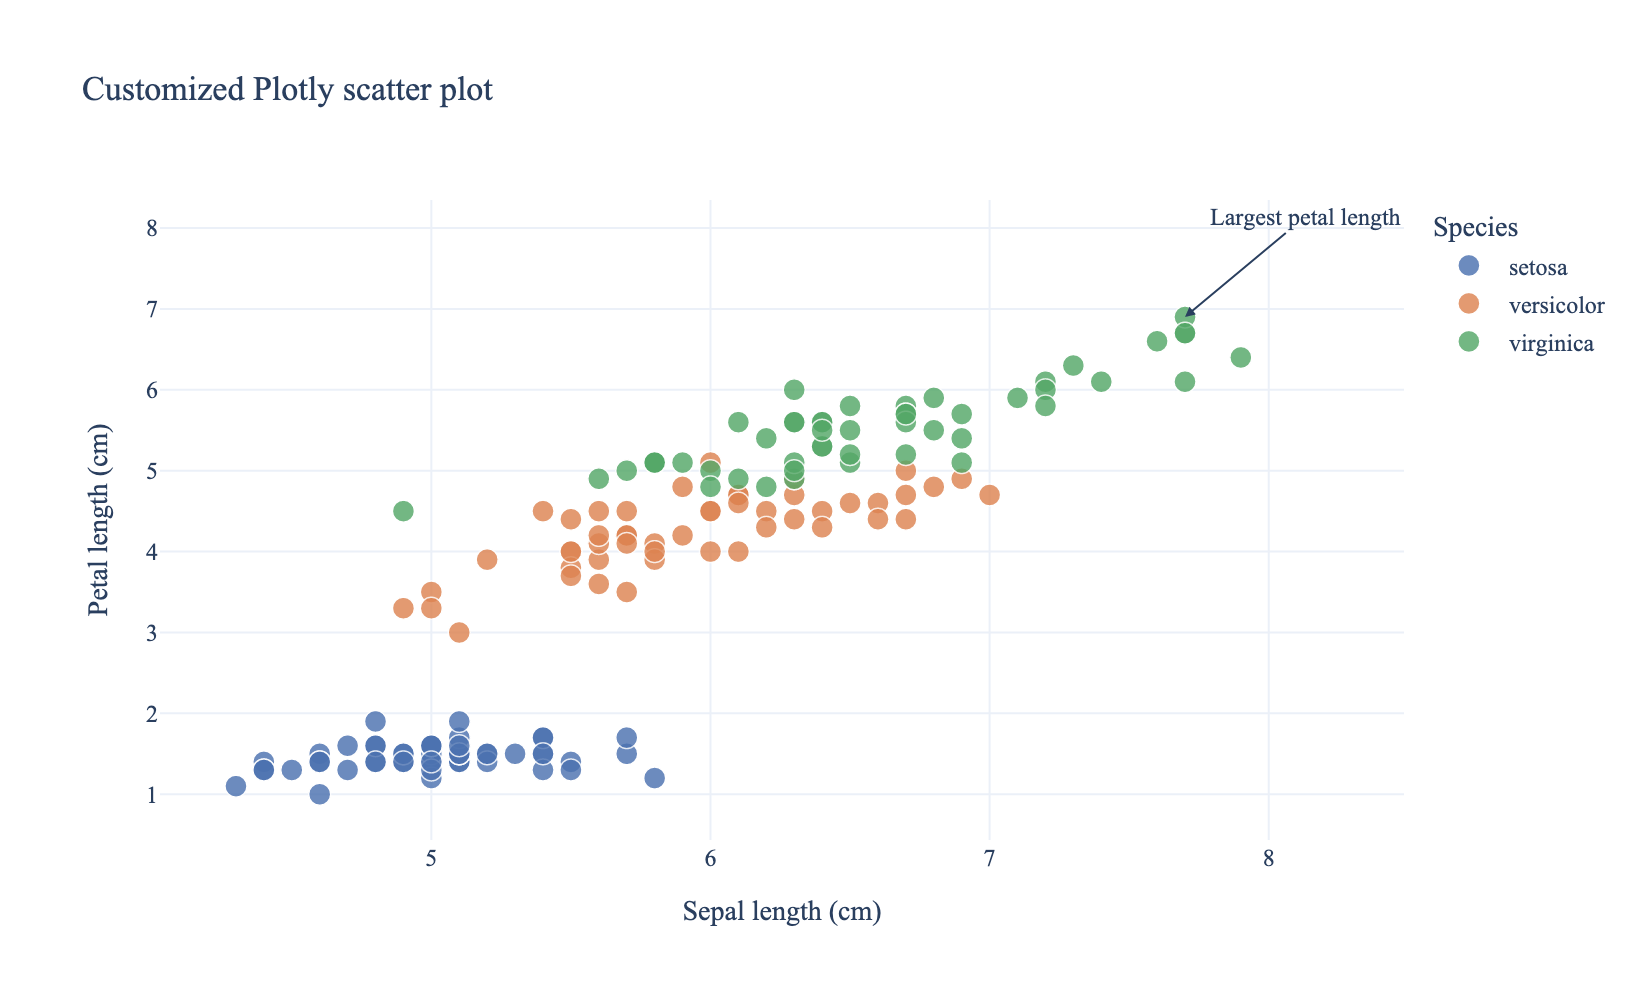

In [24]:
highlight_index = iris["petal_length"].idxmax()
highlight_row = iris.loc[highlight_index]
iris_palette = {"setosa": "#4c72b0", "versicolor": "#dd8452", "virginica": "#55a868"}

fig, ax = plt.subplots(figsize=(8, 5))
for species, group in iris.groupby("species"):
    ax.scatter(
        group["sepal_length"],
        group["petal_length"],
        s=85,
        alpha=0.78,
        label=species.title(),
        color=iris_palette[species],
        edgecolor="white",
        linewidth=0.7,
    )
ax.set_title("Customized Matplotlib scatter plot", fontsize=15, pad=12)
ax.set_xlabel("Sepal length (cm)", fontsize=12)
ax.set_ylabel("Petal length (cm)", fontsize=12)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.22, linestyle="--")
ax.legend(frameon=False, title="Species")
ax.annotate(
    "Largest petal length",
    xy=(highlight_row["sepal_length"], highlight_row["petal_length"]),
    xytext=(6.4, 6.0),
    arrowprops={"arrowstyle": "->", "lw": 1.2},
)
save_matplotlib(fig, "23_customization_plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="petal_length",
    hue="species",
    s=90,
    palette=iris_palette,
    ax=ax,
)
ax.set_title("Customized Seaborn scatter plot", fontsize=15, pad=12)
ax.set_xlabel("Sepal length (cm)", fontsize=12)
ax.set_ylabel("Petal length (cm)", fontsize=12)
ax.grid(alpha=0.22, linestyle="--")
ax.annotate(
    "Same idea, different API layer",
    xy=(highlight_row["sepal_length"], highlight_row["petal_length"]),
    xytext=(6.05, 5.7),
    arrowprops={"arrowstyle": "->", "lw": 1.1},
)
plt.show()

fig_plotly = px.scatter(
    iris,
    x="sepal_length",
    y="petal_length",
    color="species",
    color_discrete_map=iris_palette,
    template="plotly_white",
    title="Customized Plotly scatter plot",
)
fig_plotly.update_traces(marker=dict(size=11, opacity=0.82, line=dict(width=0.7, color="white")))
fig_plotly.update_layout(
    width=820,
    height=500,
    font=dict(family="DejaVu Sans", size=12),
    legend_title_text="Species",
    xaxis_title="Sepal length (cm)",
    yaxis_title="Petal length (cm)",
)
fig_plotly.add_annotation(
    x=highlight_row["sepal_length"],
    y=highlight_row["petal_length"],
    text="Largest petal length",
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-50,
)
show_plotly(fig_plotly, width=820, height=500)

## 24. Publication-quality Improvement: Raw Plot to Polished Plot

A publication-quality figure usually starts as a plain draft. The improvement step is mostly about
communication, not fancy coding.

In the next cell:

- The left panel shows a raw draft with minimal styling.
- The right panel shows the same data with better spacing, labeling, line width, annotation, and color.
- The polished version is saved into `outputs/figures/24_publication_quality.png`.

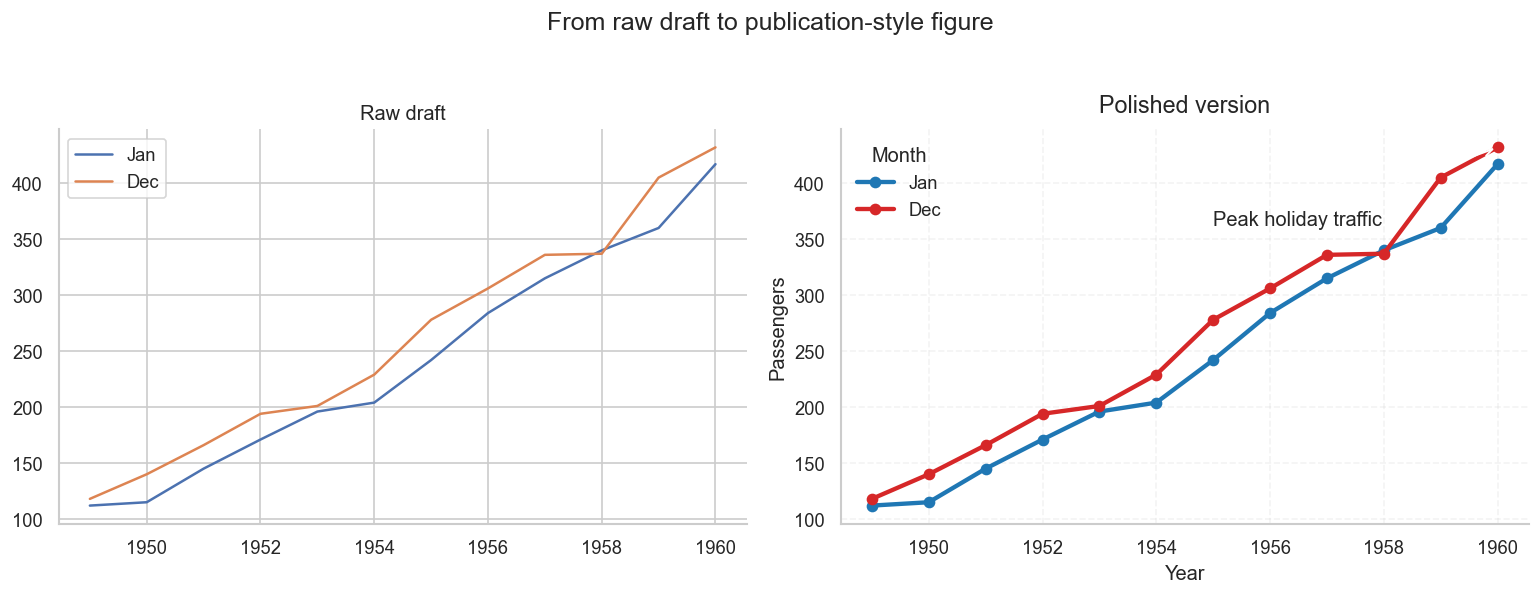

In [25]:
publication_data = flights[flights["month"].isin(["Jan", "Dec"])].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for month, group in publication_data.groupby("month", observed=True):
    axes[0].plot(group["year"], group["passengers"], label=month)
axes[0].set_title("Raw draft")
axes[0].legend()

polished_palette = {"Jan": "#1f77b4", "Dec": "#d62728"}
for month, group in publication_data.groupby("month", observed=True):
    axes[1].plot(group["year"], group["passengers"], label=month, linewidth=2.6, marker="o", color=polished_palette[month])
axes[1].set_title("Polished version", fontsize=14, pad=10)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Passengers")
axes[1].grid(alpha=0.22, linestyle="--")
axes[1].legend(frameon=False, title="Month")
peak_row = publication_data.loc[publication_data["passengers"].idxmax()]
axes[1].annotate(
    "Peak holiday traffic",
    xy=(peak_row["year"], peak_row["passengers"]),
    xytext=(peak_row["year"] - 5, peak_row["passengers"] - 70),
    arrowprops={"arrowstyle": "->", "lw": 1.2},
)

fig.suptitle("From raw draft to publication-style figure", fontsize=15, y=1.03)
fig.tight_layout()
save_matplotlib(fig, "24_publication_quality")
plt.show()

## 25. Exporting Figures as PNG, SVG, PDF, and Plotly HTML

Export is part of the plotting workflow, not an afterthought.

- Use PNG for notebooks and slides.
- Use SVG or PDF when vector quality matters.
- Use Plotly HTML when you want hover, zoom, and legend toggles.

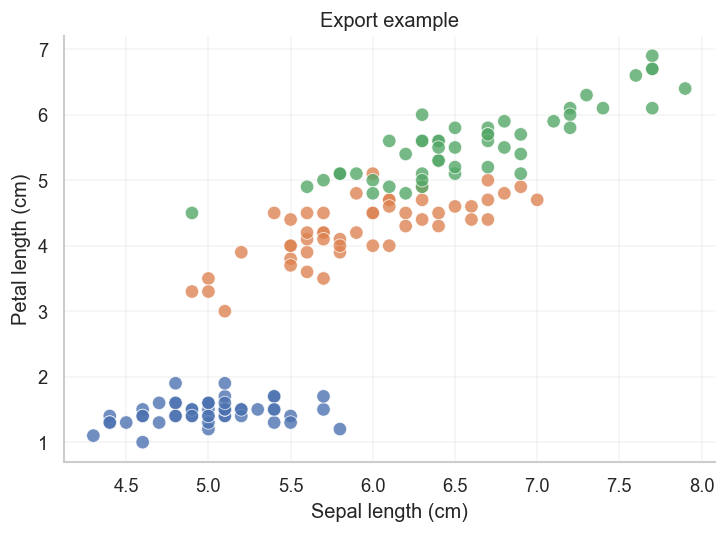

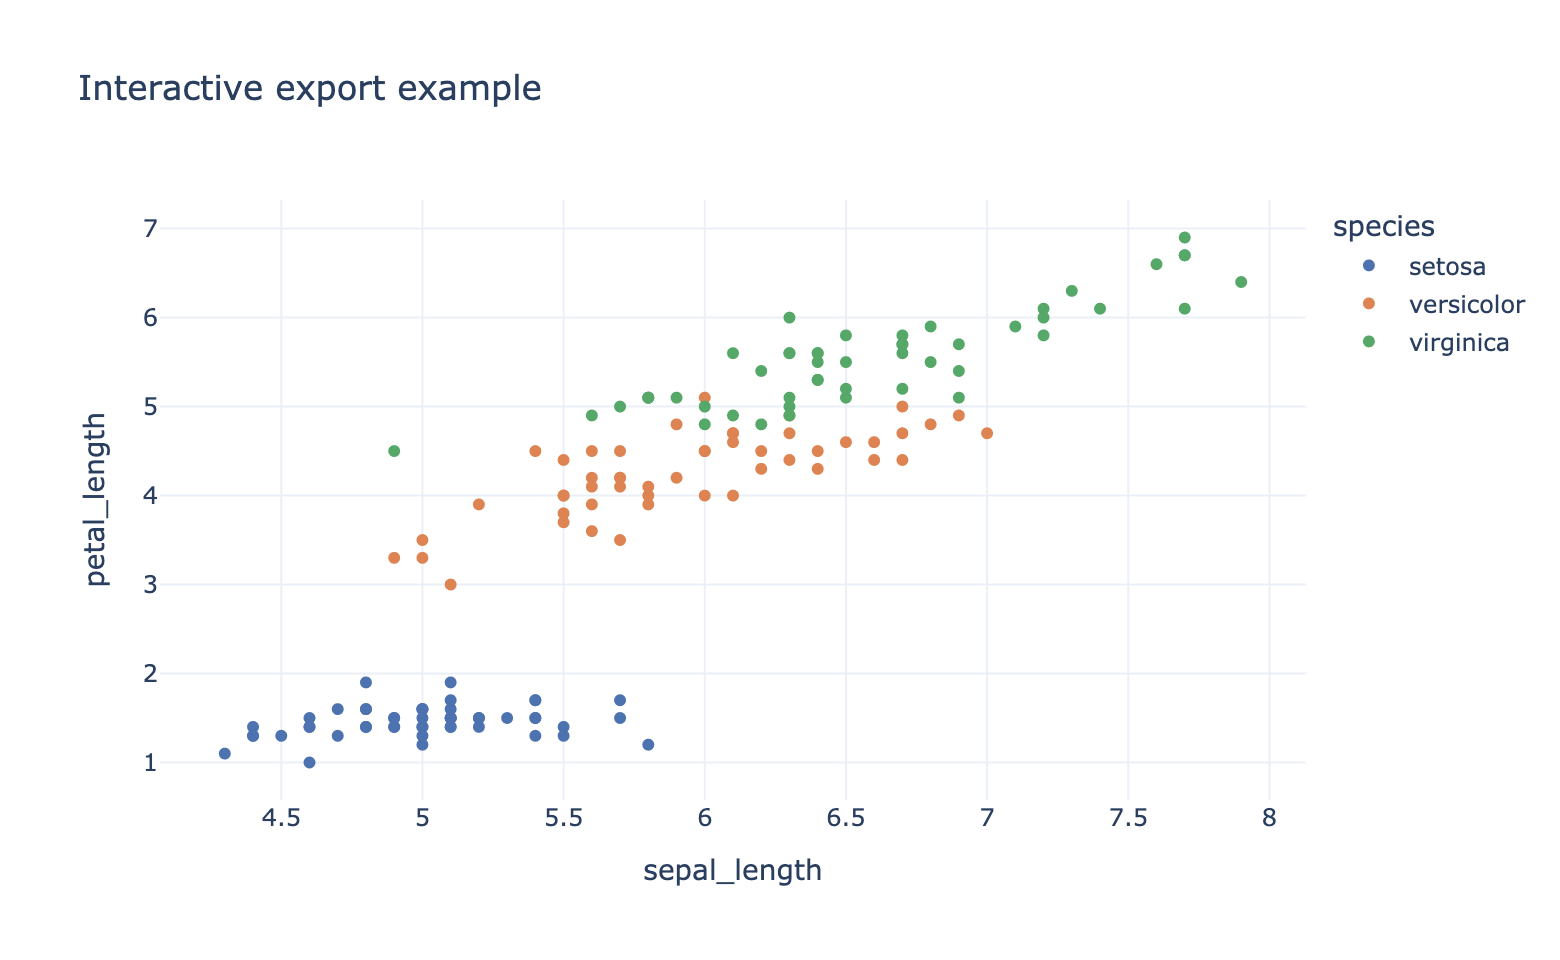

Saved: 25_export_example.png 25_export_example.svg 25_export_example.pdf 25_export_example_plotly.html


In [26]:
export_fig, export_ax = plt.subplots(figsize=(7, 4.6))
export_ax.scatter(
    iris["sepal_length"],
    iris["petal_length"],
    c=iris["species"].map(iris_palette),
    s=65,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
)
export_ax.set(title="Export example", xlabel="Sepal length (cm)", ylabel="Petal length (cm)")
export_ax.grid(alpha=0.2)

png_path = OUTPUT_DIR / "25_export_example.png"
svg_path = OUTPUT_DIR / "25_export_example.svg"
pdf_path = OUTPUT_DIR / "25_export_example.pdf"
export_fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
export_fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
export_fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

iris_palette = {"setosa": "#4c72b0", "versicolor": "#dd8452", "virginica": "#55a868"}

export_plotly = px.scatter(
    iris,
    x="sepal_length",
    y="petal_length",
    color="species",
    color_discrete_map=iris_palette,
    template="plotly_white",
    title="Interactive export example",
)
html_path = OUTPUT_DIR / "25_export_example_plotly.html"
export_plotly.write_html(html_path, include_plotlyjs="cdn")
show_plotly(export_plotly)

print("Saved:", png_path.name, svg_path.name, pdf_path.name, html_path.name)

## 26. Practice Exercises

Try these without looking at the earlier answers first.

1. Recreate the line plot using `flights` but compare four months instead of three.
2. Build a scatter plot from `penguins` using bill length and bill depth, and color by species.
3. Replace the histogram bin count with a different value and compare how the story changes.
4. Turn the box plot into a violin plot plus strip overlay and explain what extra information you gain.
5. Make a new volcano plot threshold rule and count how many genes change category.
6. Export one figure as both PNG and SVG, then open both and compare the file behavior.
7. Build your own publication-quality figure from any section and explain every design choice.